<a href="https://colab.research.google.com/github/Swastik10b/Numerical-Experiments-Chapter-6/blob/main/Numerical_Experiments_Chapter_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 1 — Simulation Study of a Hamiltonian Dynamical System

This experiment investigates the behaviour of PhyDrop-GP on a nonlinear Hamiltonian dynamical system and examines whether incorporating the governing physics improves prediction beyond the training regime.

We consider a Duffing-type oscillator with Hamiltonian

$$
H(q,p)=\frac{p^2}{2M}+\frac{\kappa q^2}{2}+\frac{\beta q^4}{4},
$$

with $M=1$, $\kappa=1$, and $\beta=0.2$. The corresponding dynamics are

$$
\dot{q}=\frac{p}{M},
\qquad
\dot{p}=-\kappa q-\beta q^3.
$$

The neural network learns a scalar Hamiltonian and generates the vector field through Hamilton's equations. We compare a conventional Gal-style MC Dropout model with PhyDrop-GP, which additionally includes a probabilistic Hamiltonian physics residual,

$$
P_H(s)=F(s)-J\nabla_s H_\omega(s).
$$

The experiment considers three regimes: E1 represents interpolation within the training support, while E2 and E3 progressively test moderate and strong extrapolation. The models are compared using trajectory error, predictive uncertainty, vector-field accuracy, and Hamiltonian residuals.

The main result is that the physics-informed model provides increasingly large benefits under extrapolation. PhyDrop-GP reduces the mean trajectory RMSE by approximately $47.8\%$ in E2 and $16.9\%$ in E3, while also producing substantially lower uncertainty in the strongest OOD regime. The learned vector field and Hamiltonian residual further indicate that the improvement arises from learning dynamics that remain more consistent with the governing physical structure.

The experiment therefore demonstrates that the physics constraint can provide a useful inductive bias for long-horizon and out-of-distribution prediction, although it does not guarantee uniformly better performance at every individual time point.

HAMILTONIAN PHYDROP-GP vs GAL-STYLE DROPOUT
GENUINE OOD / EXTRAPOLATION EXPERIMENT
Device: cpu

EXPERIMENTAL PARAMETERS
MASS                         = 1.0
KAPPA                       = 1.0
BETA                        = 0.2
sigma_obs                   = 0.05
tau_obs                     = 400.000000
sigma_H                     = 0.05
tau_H                       = 400.000000
dropout rate                = 0.1
lengthscale                = 0.01
Gal L2 coefficient          = 4.500000000000e-11
N_data                      = 2500
N_collocation               = 3000
lambda_H theoretical        = 6.666666666667e-02
physics multiplier          = 1.0
lambda_H effective          = 6.666666666667e-02
hidden units                = 96
MC samples                 = 50
epochs                     = 450
rollout time               = 12.0
dt                         = 0.02
training time cutoff       = 4.0

ENERGY REGIMES
E1 amplitude               = 0.7  [SUPPORTED]
E2 amplitude               = 1.15  [MODERATE 

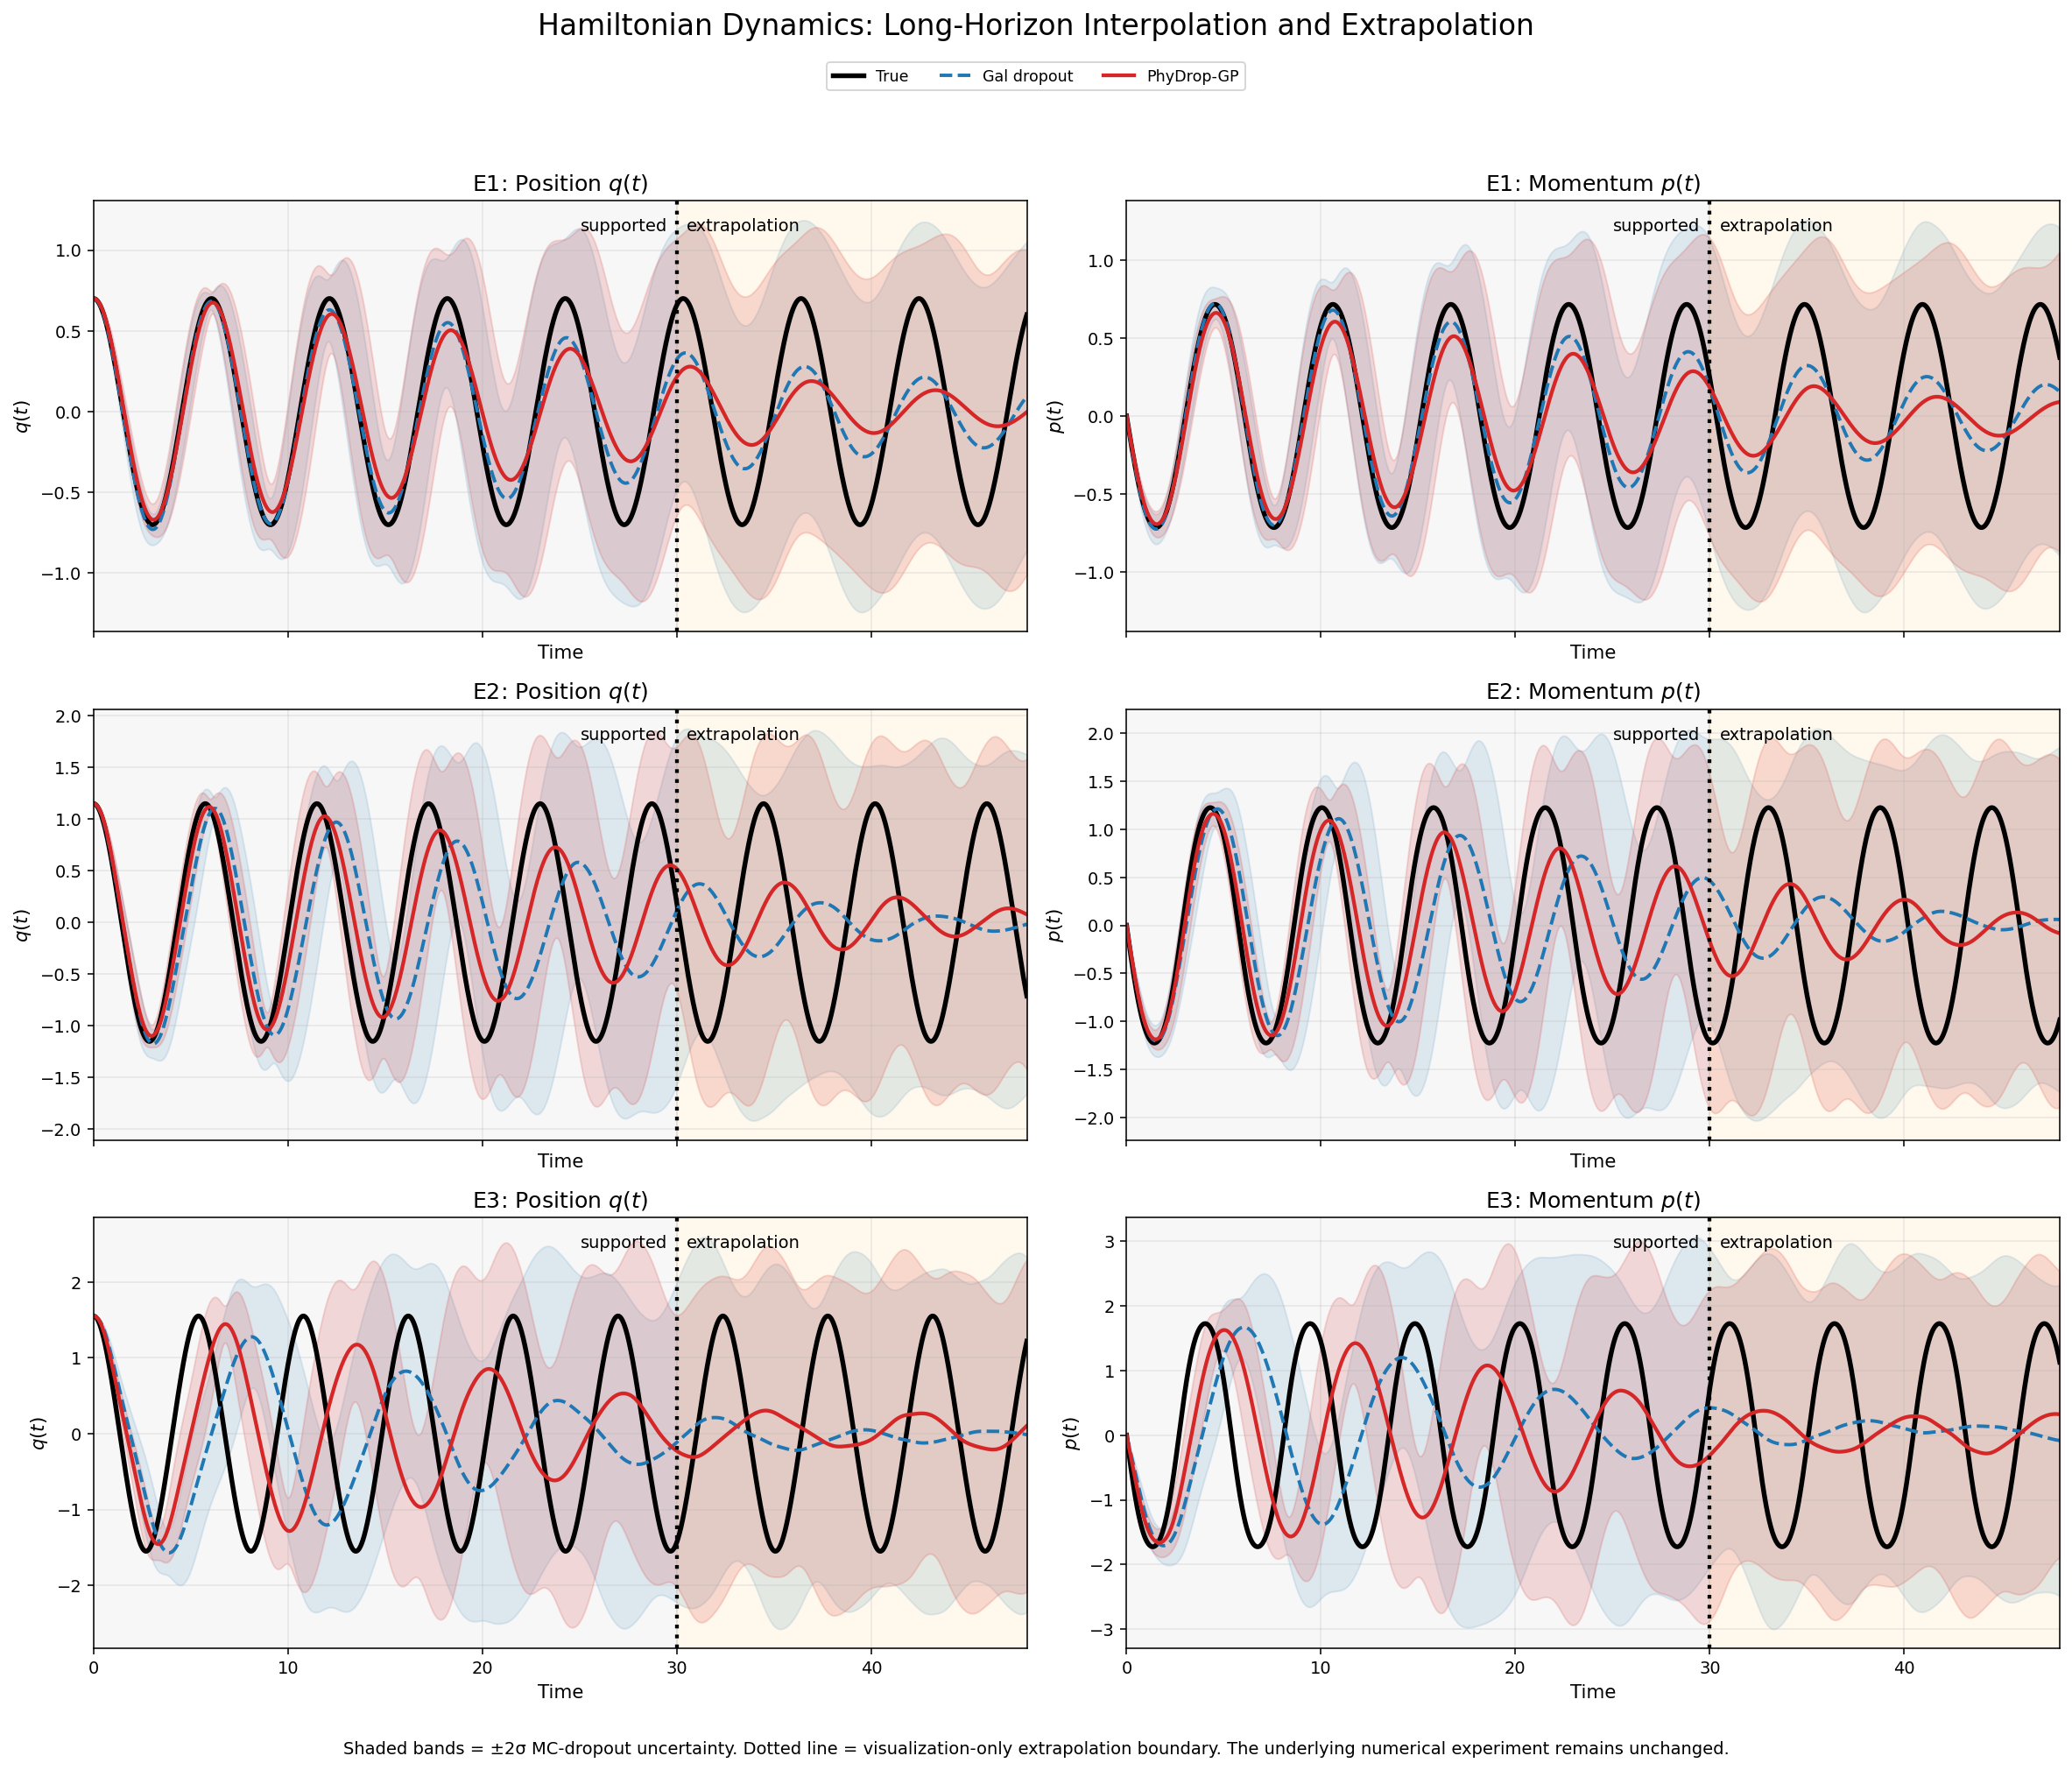

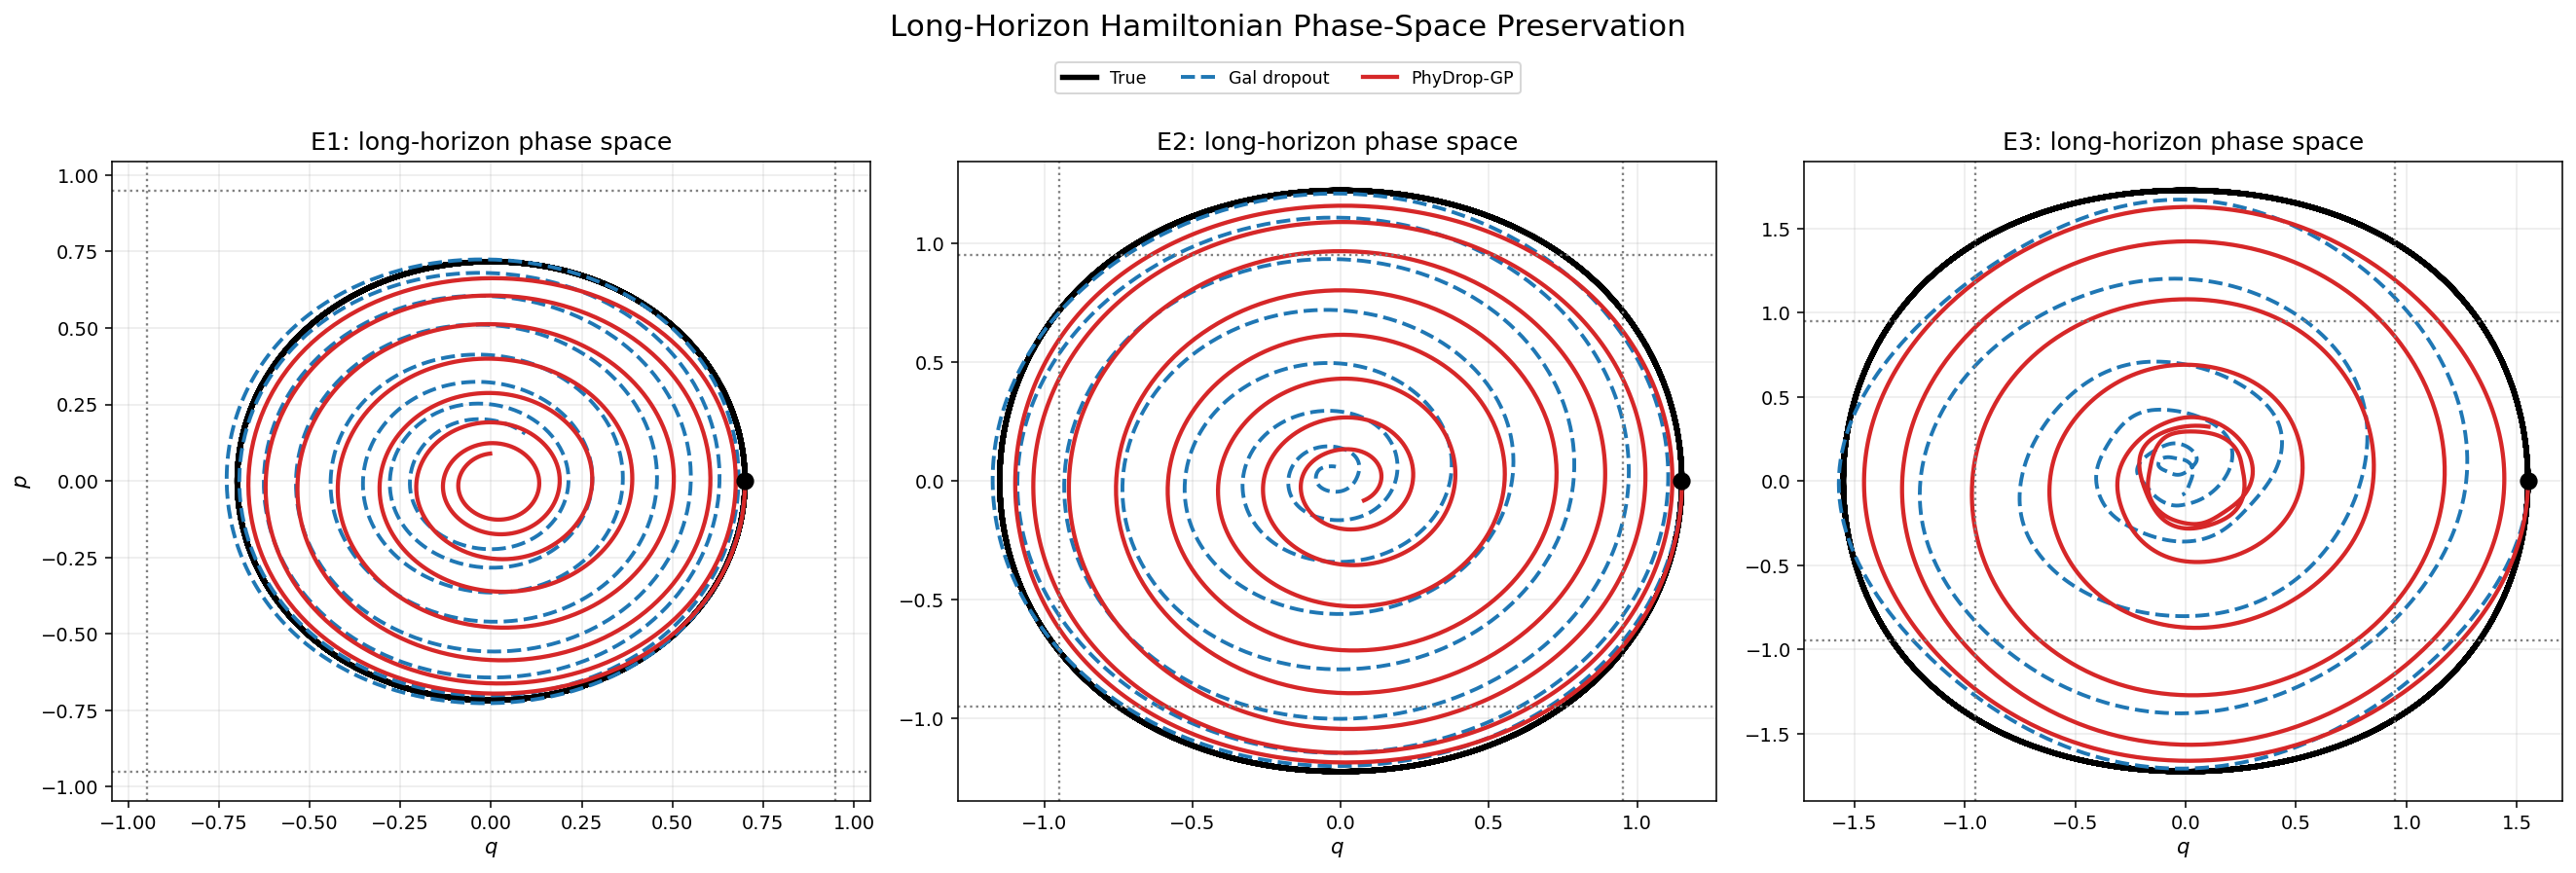

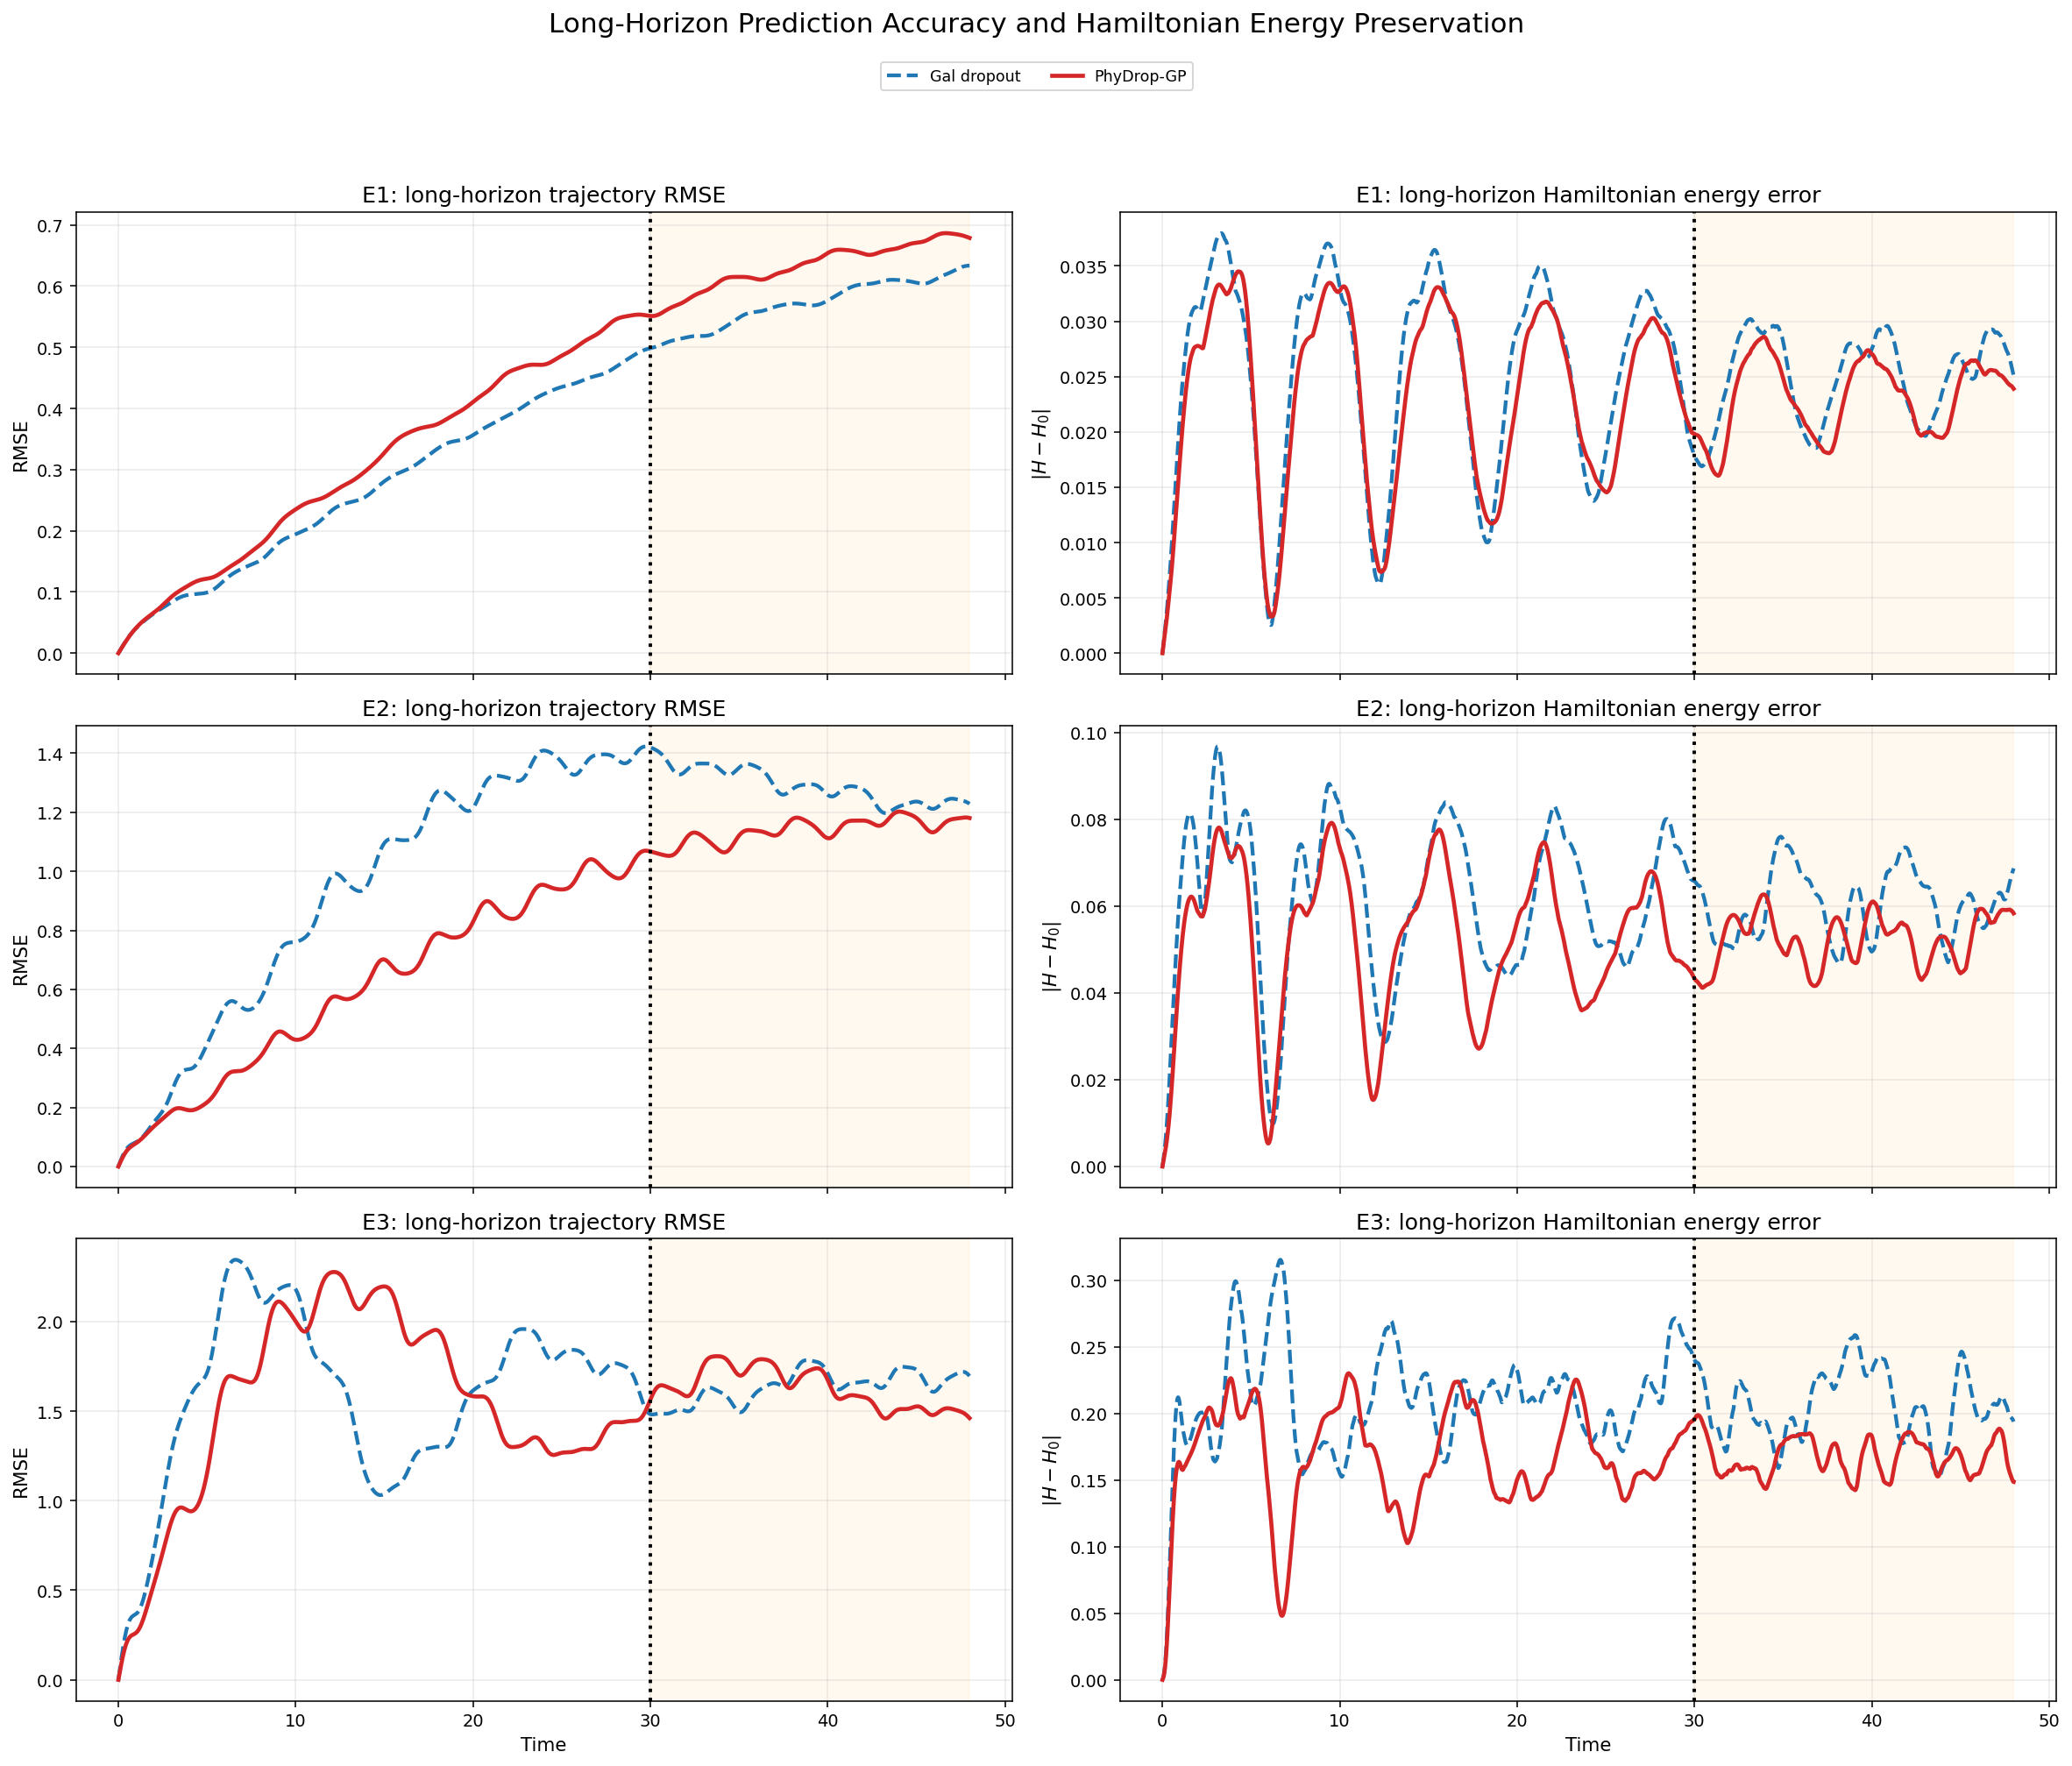

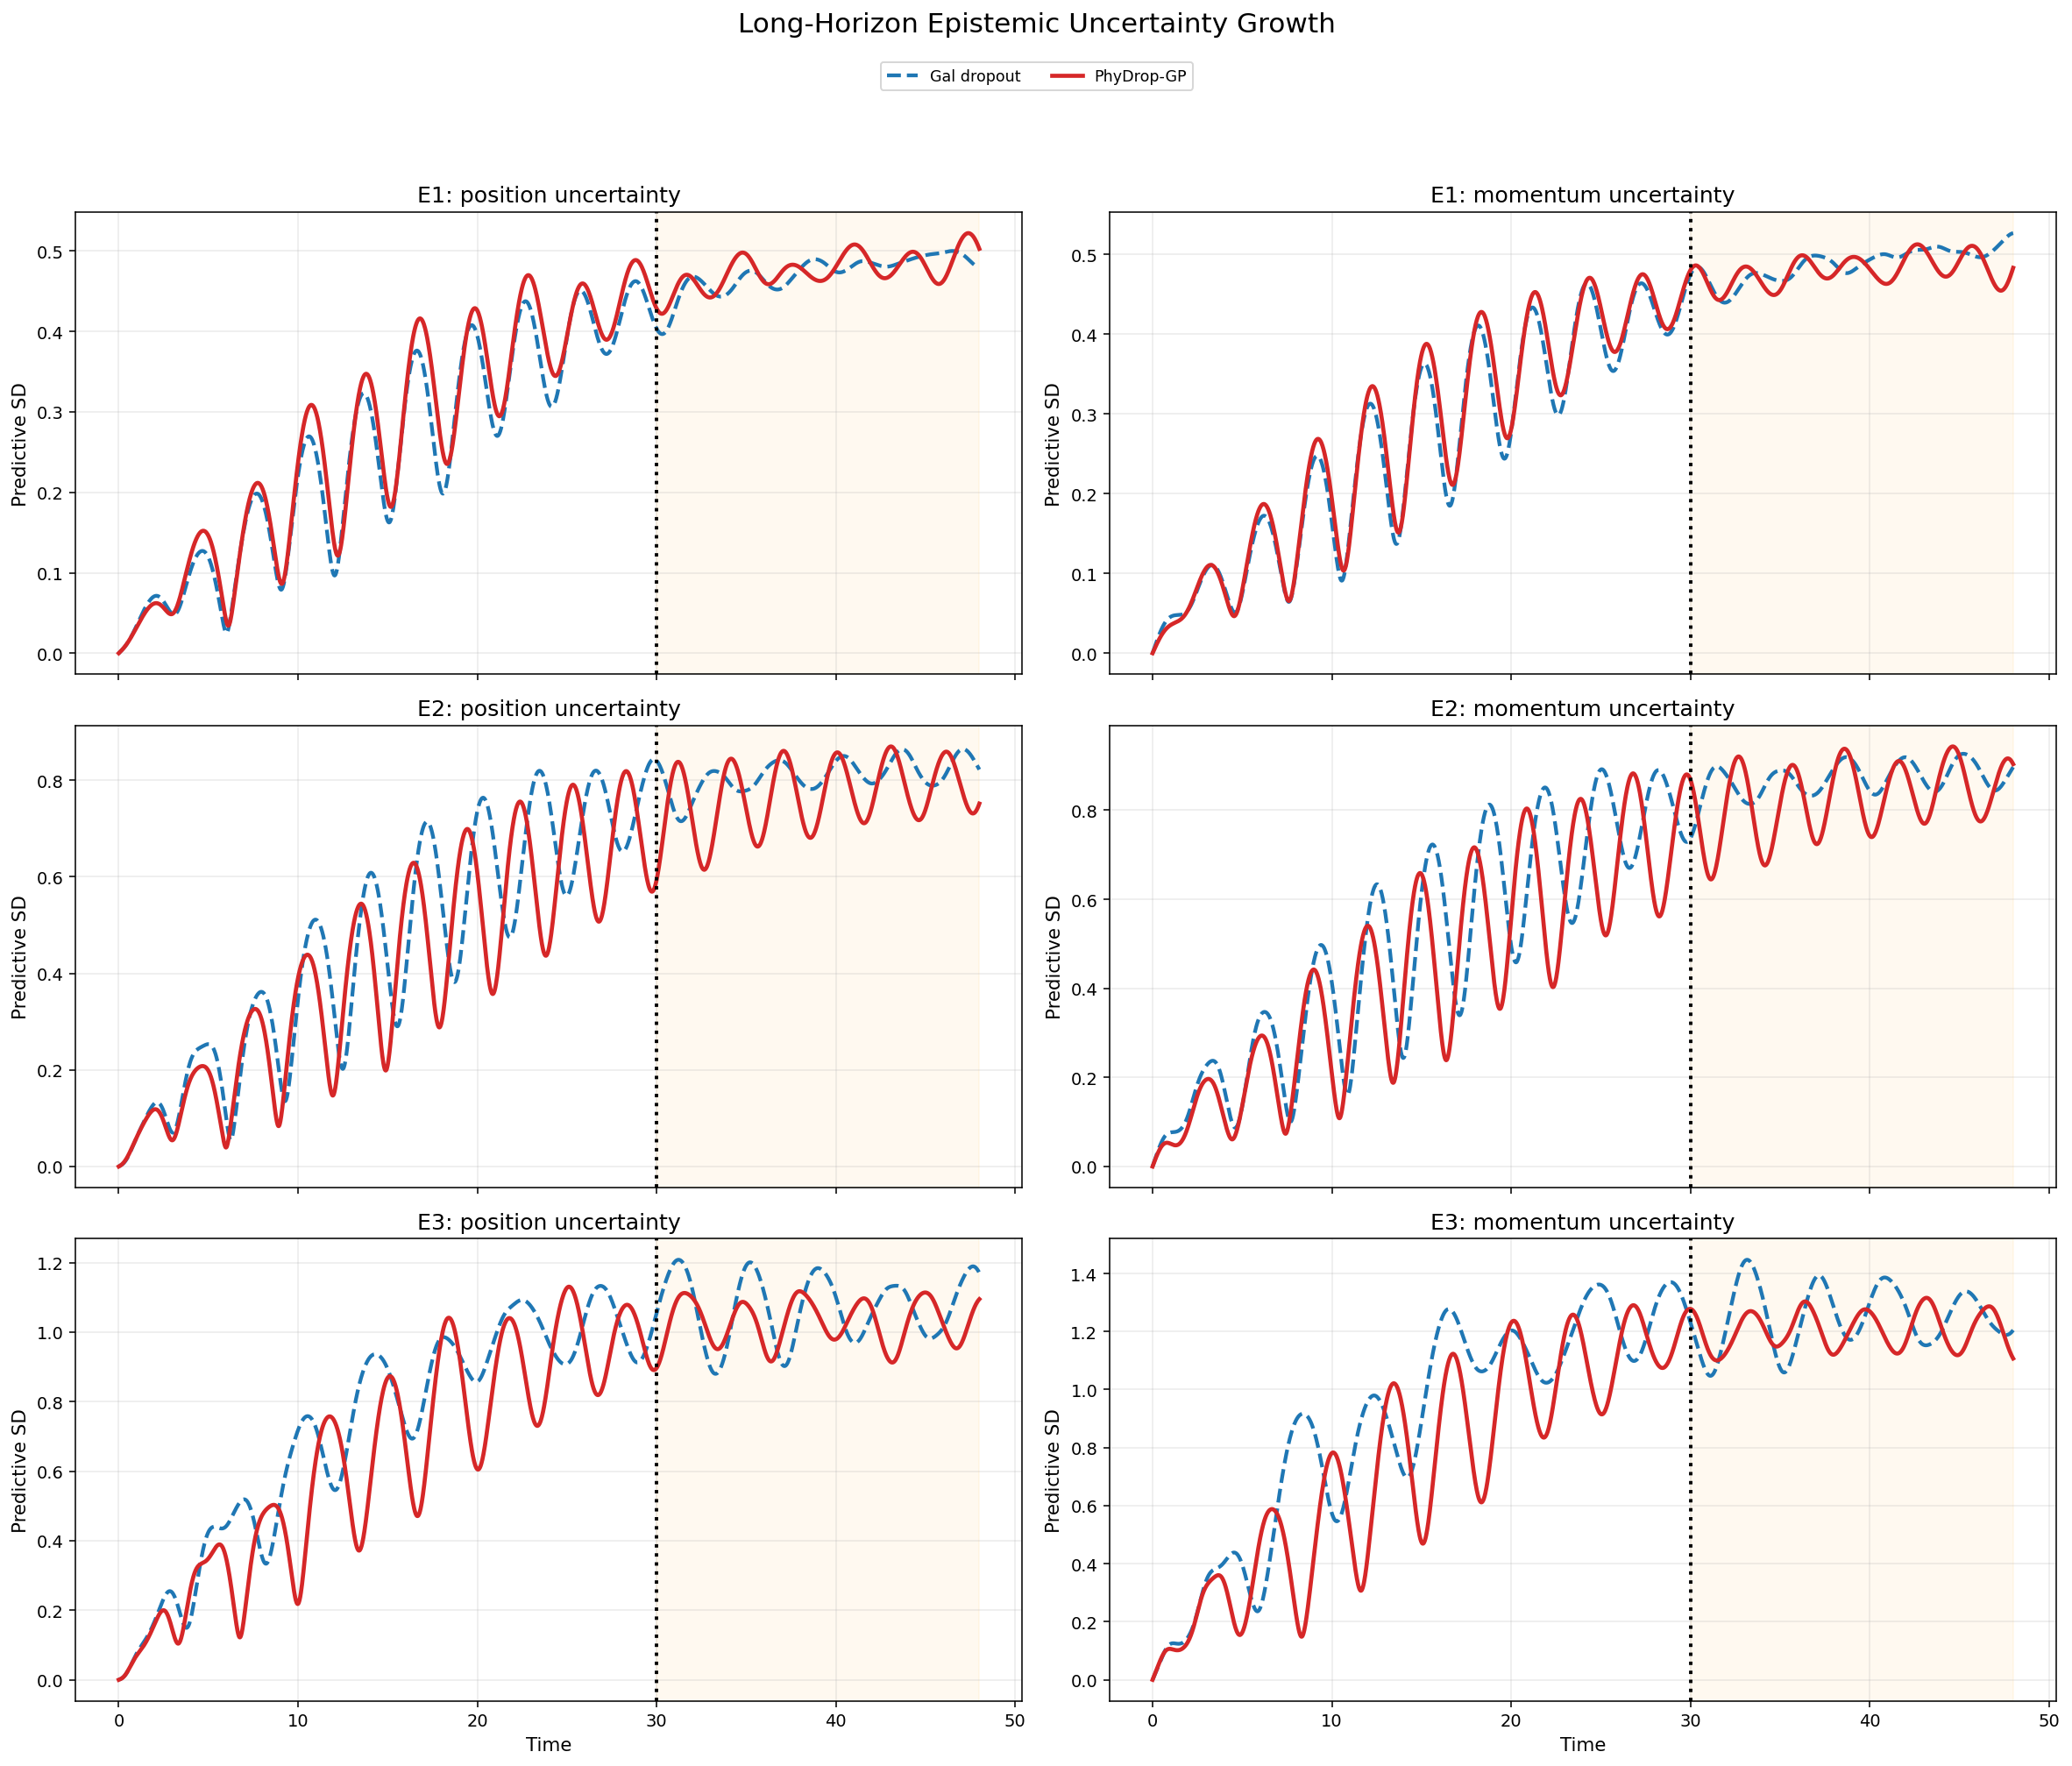

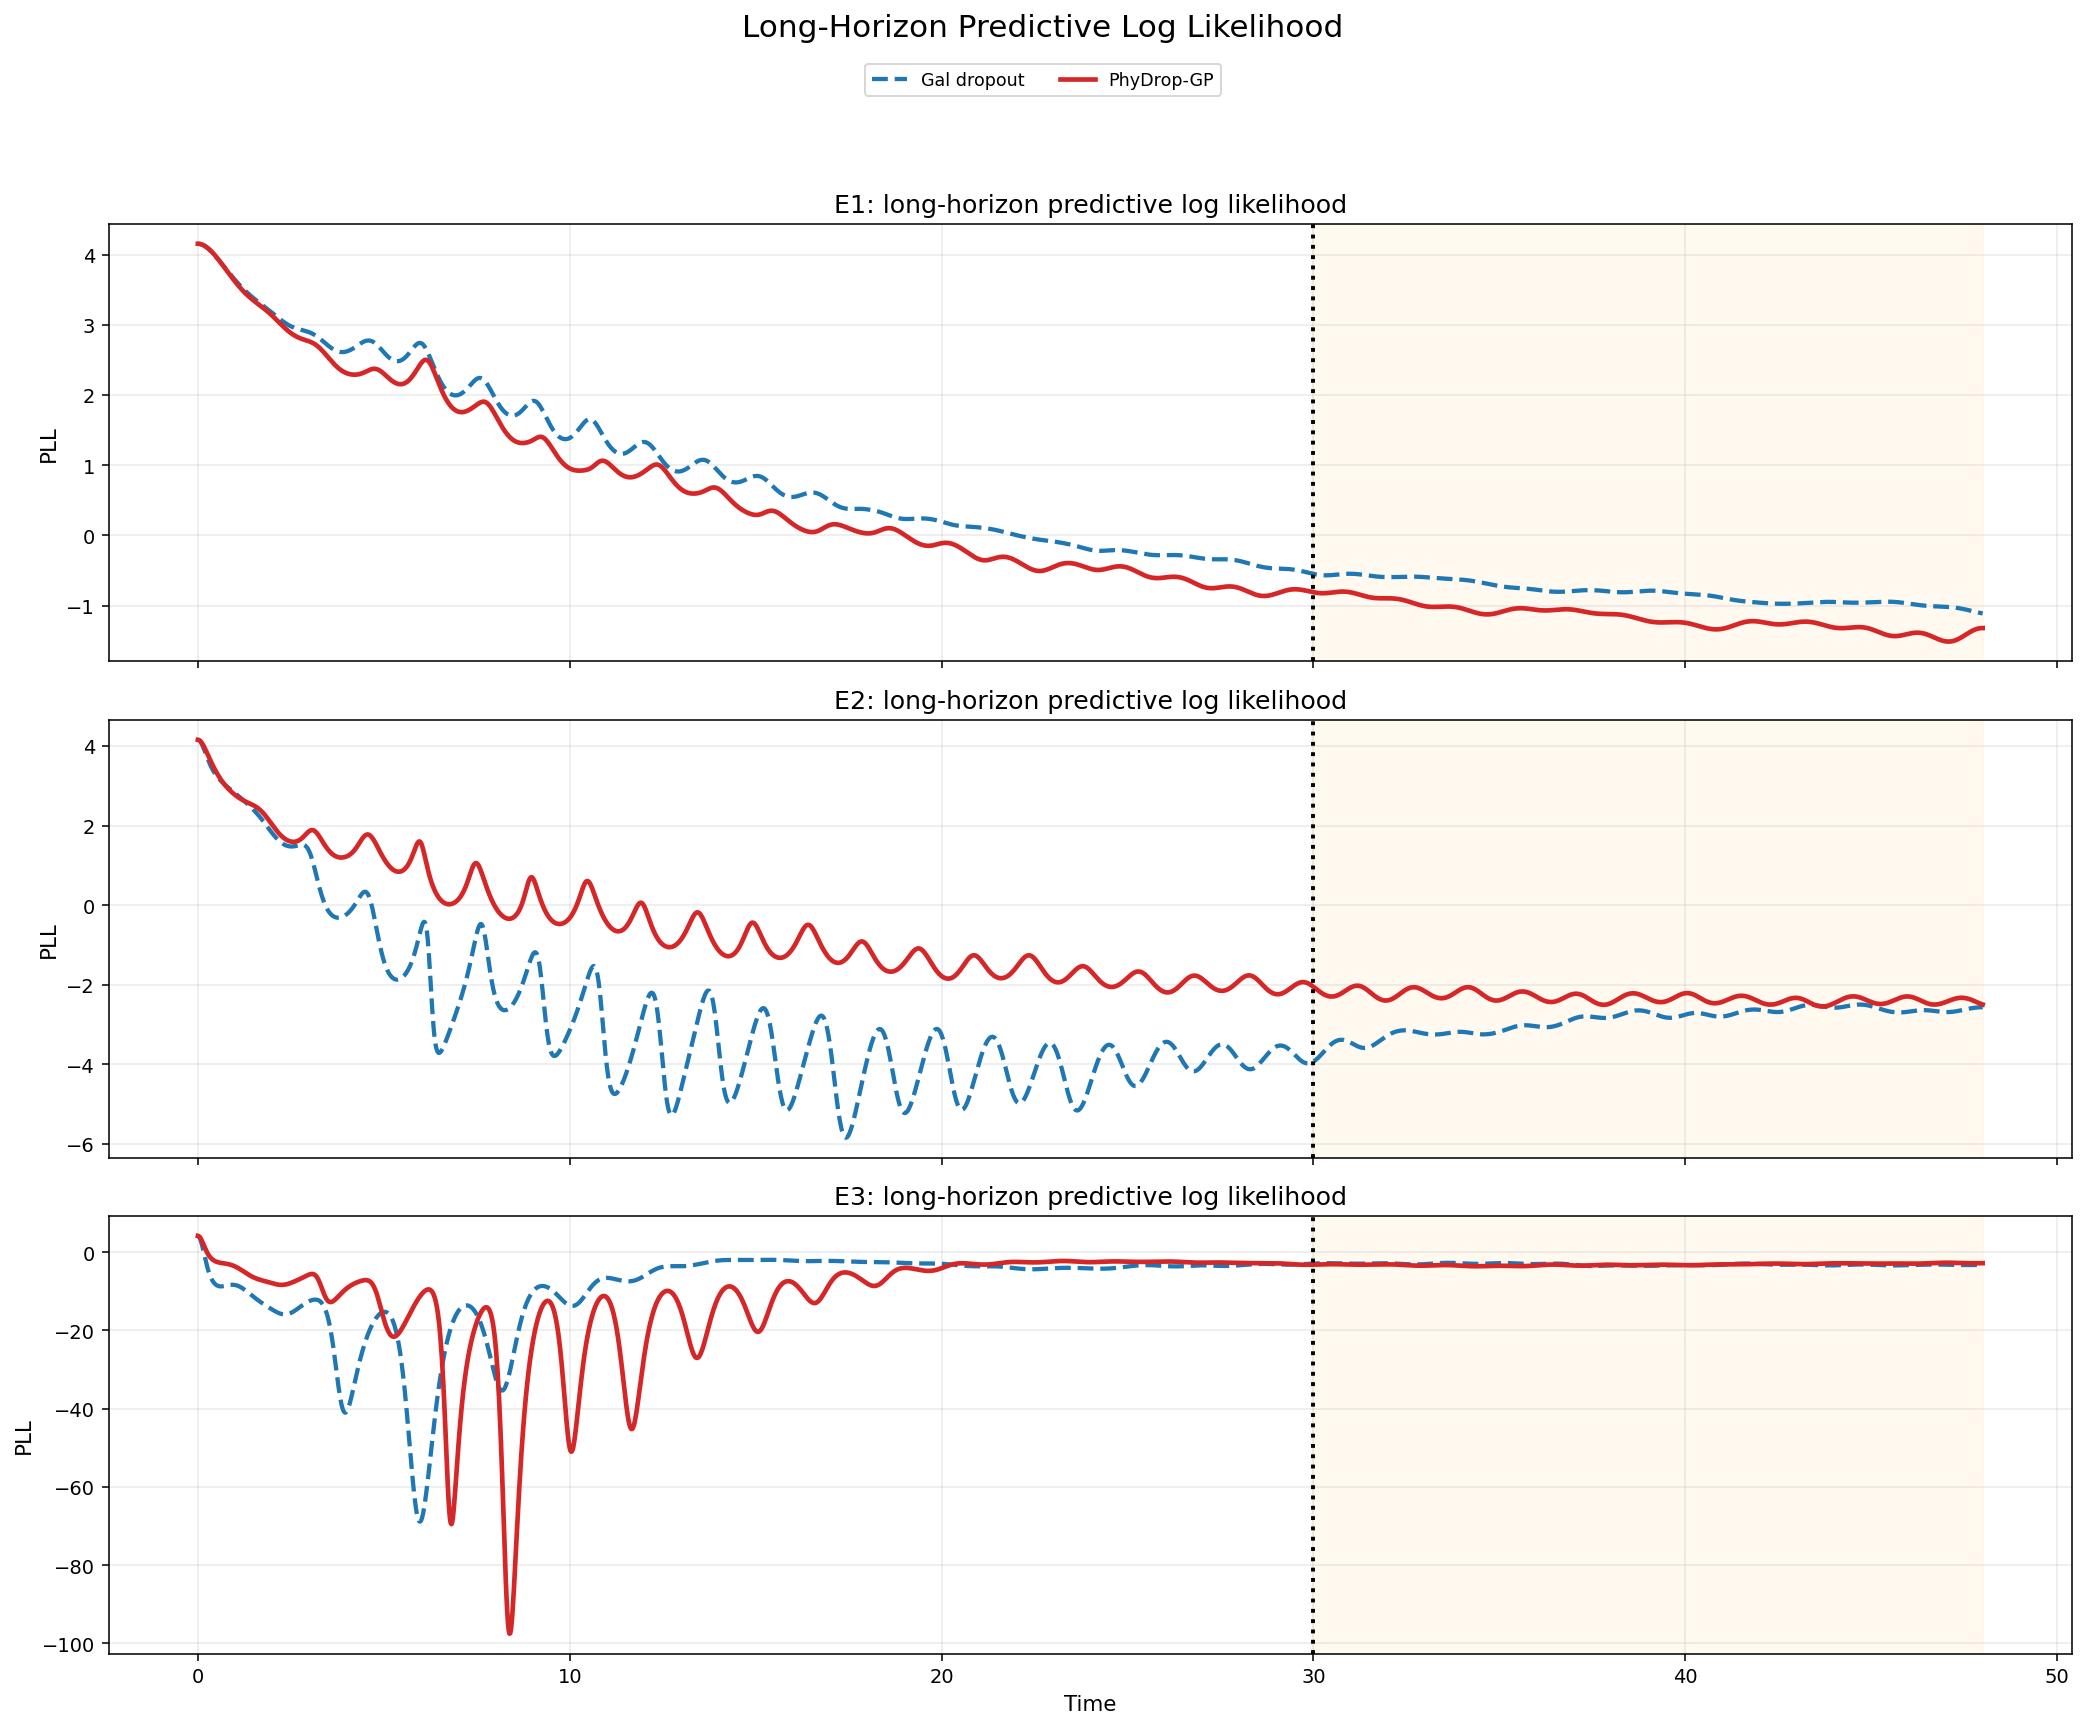

/tmp/ipykernel_8244/3297273288.py:3431: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


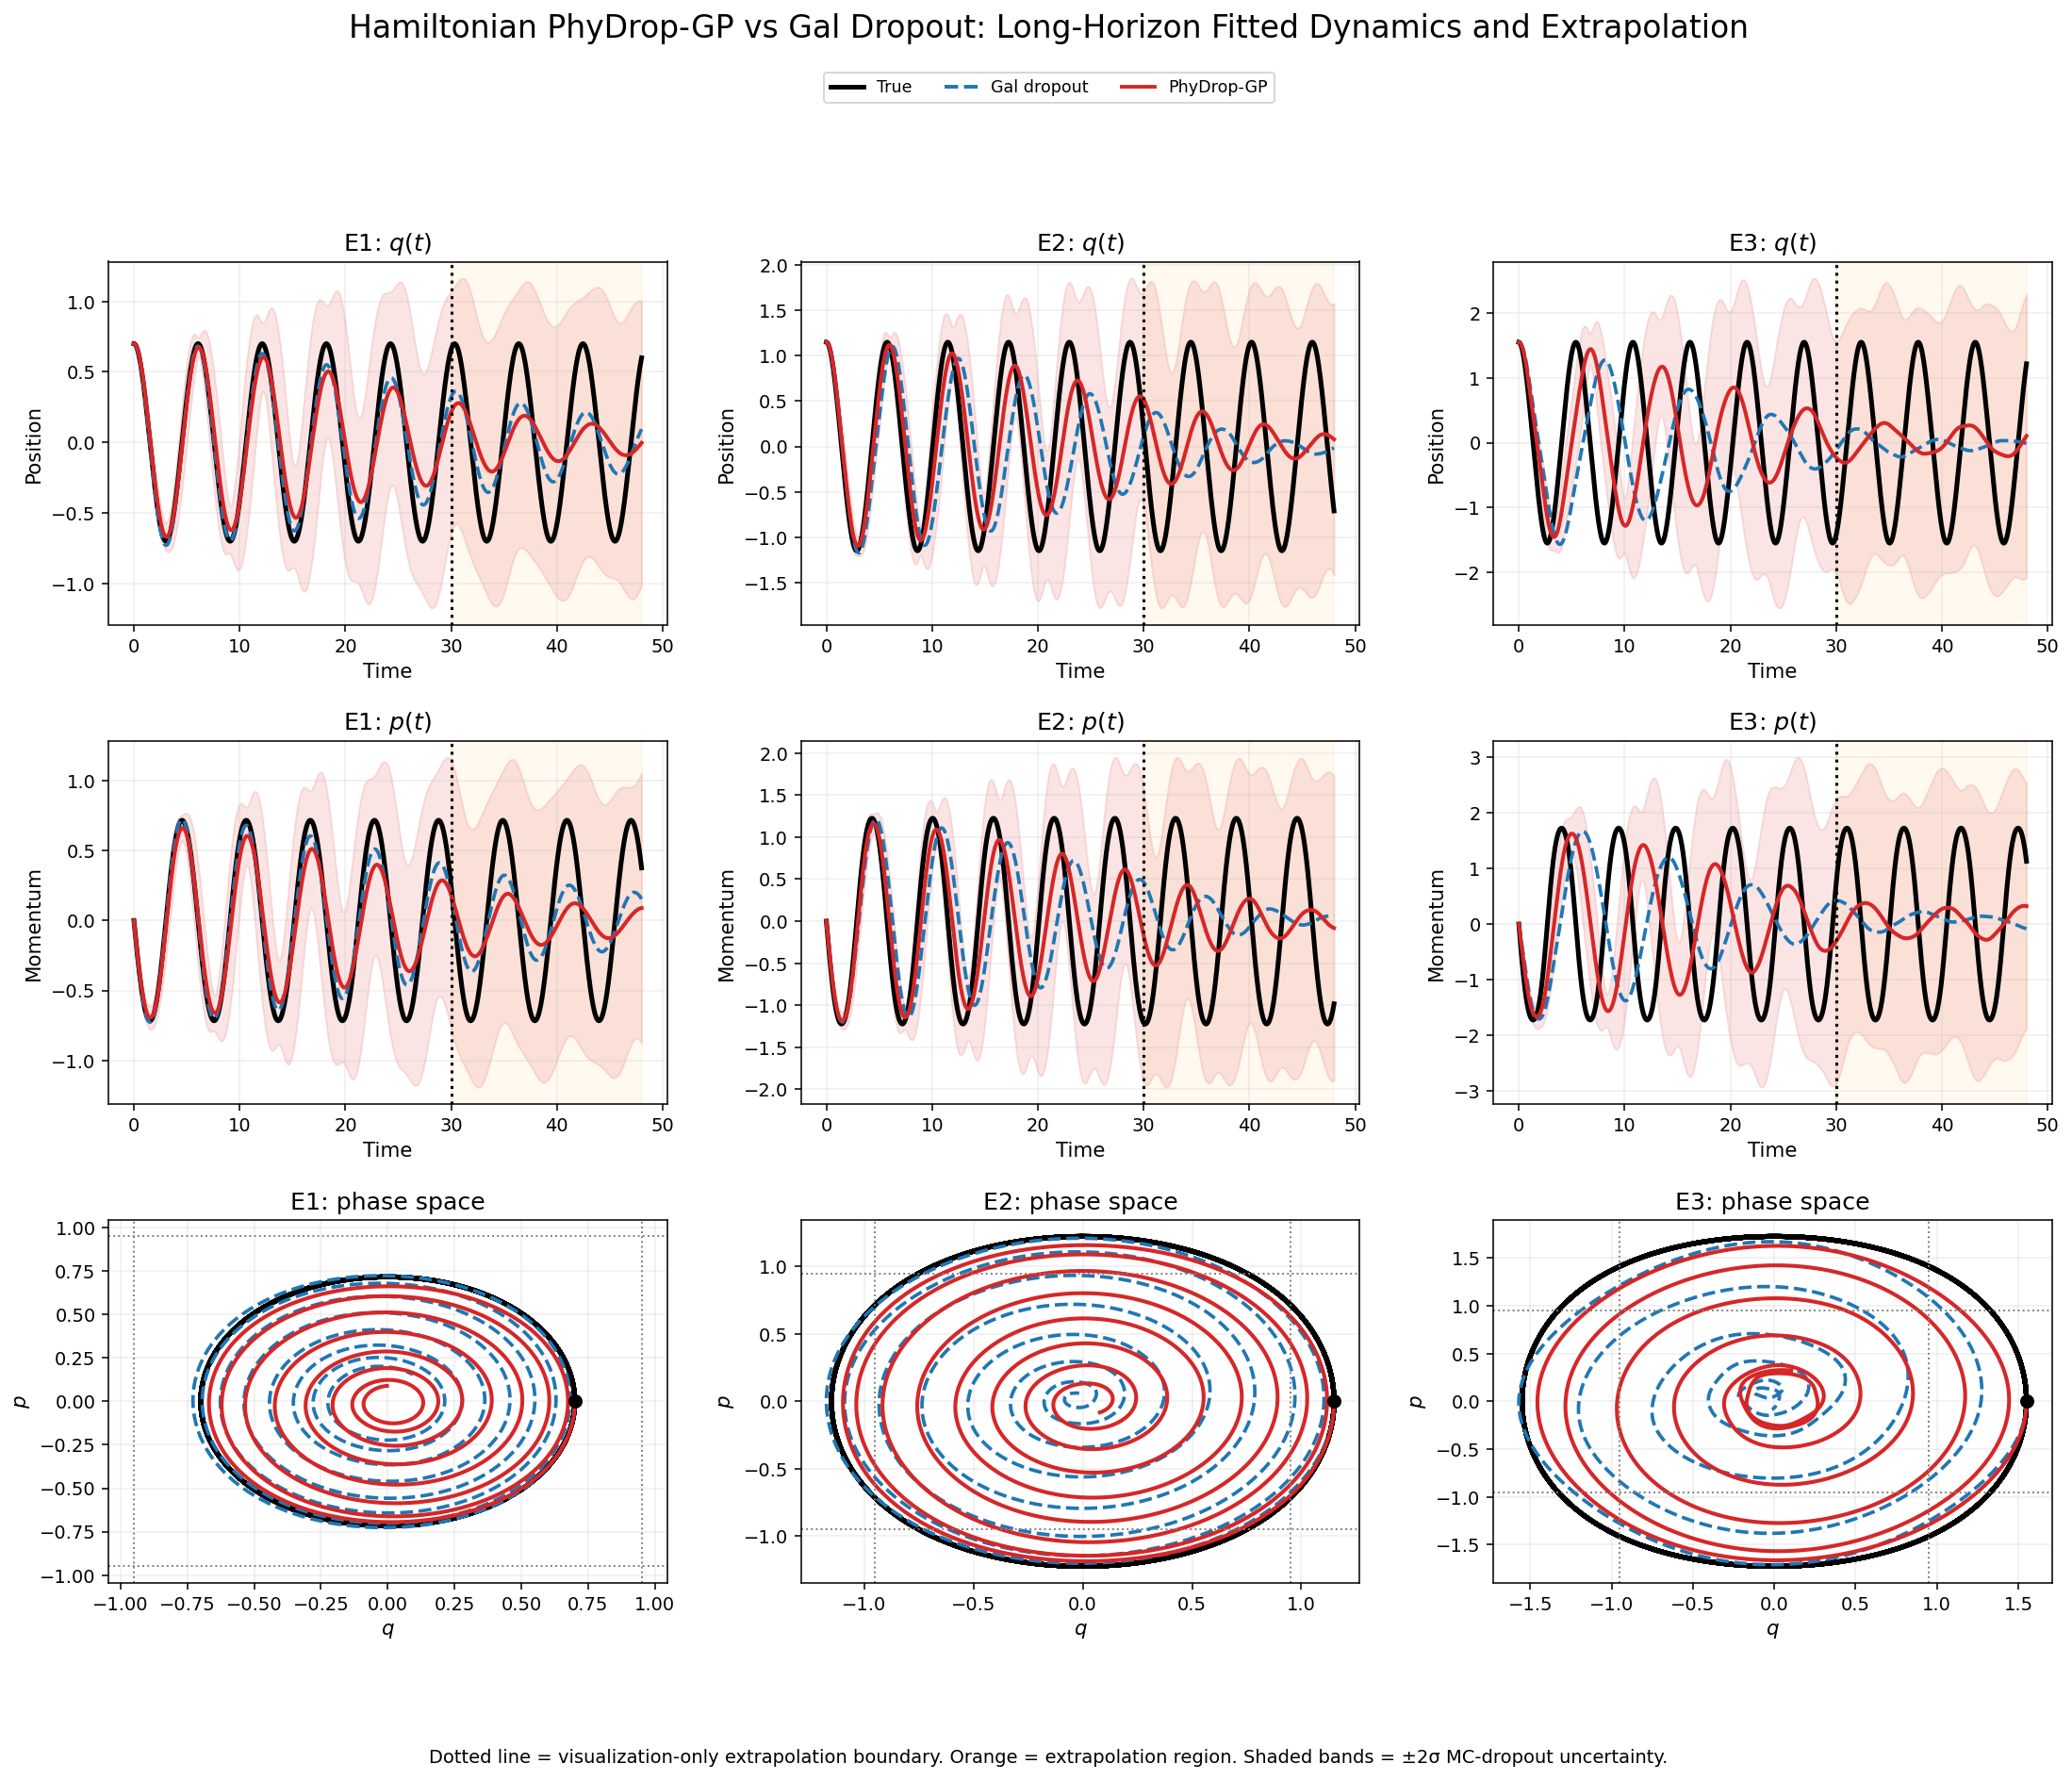

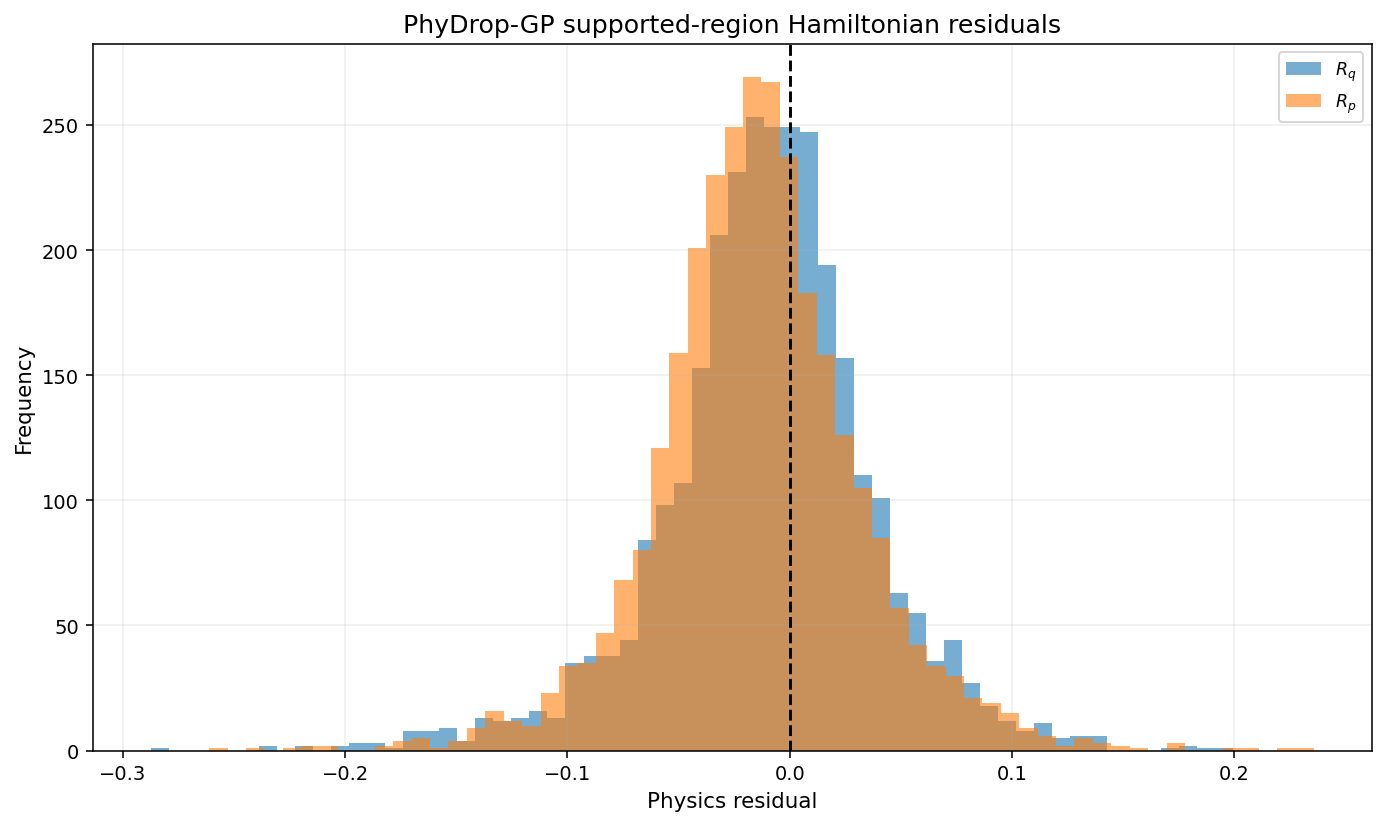

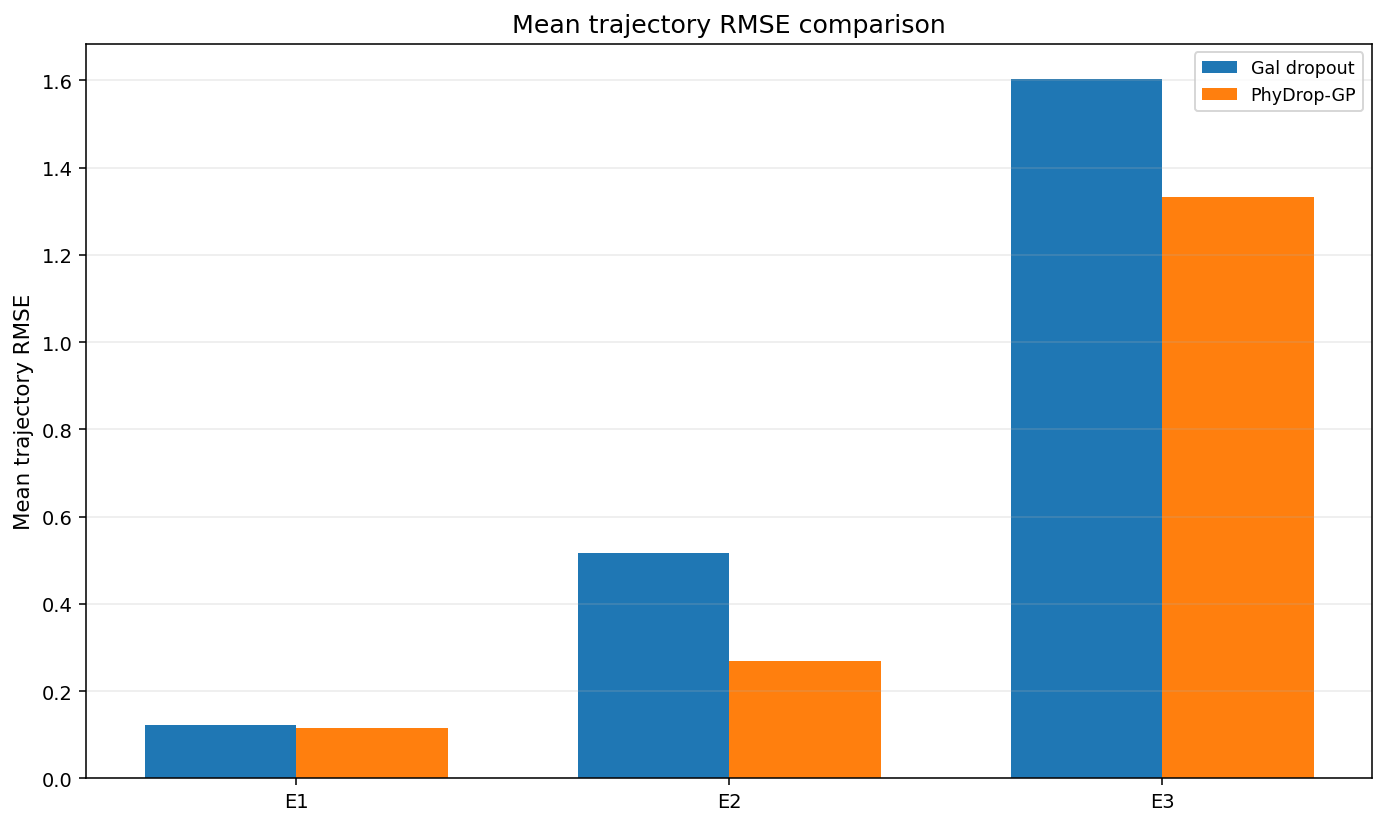

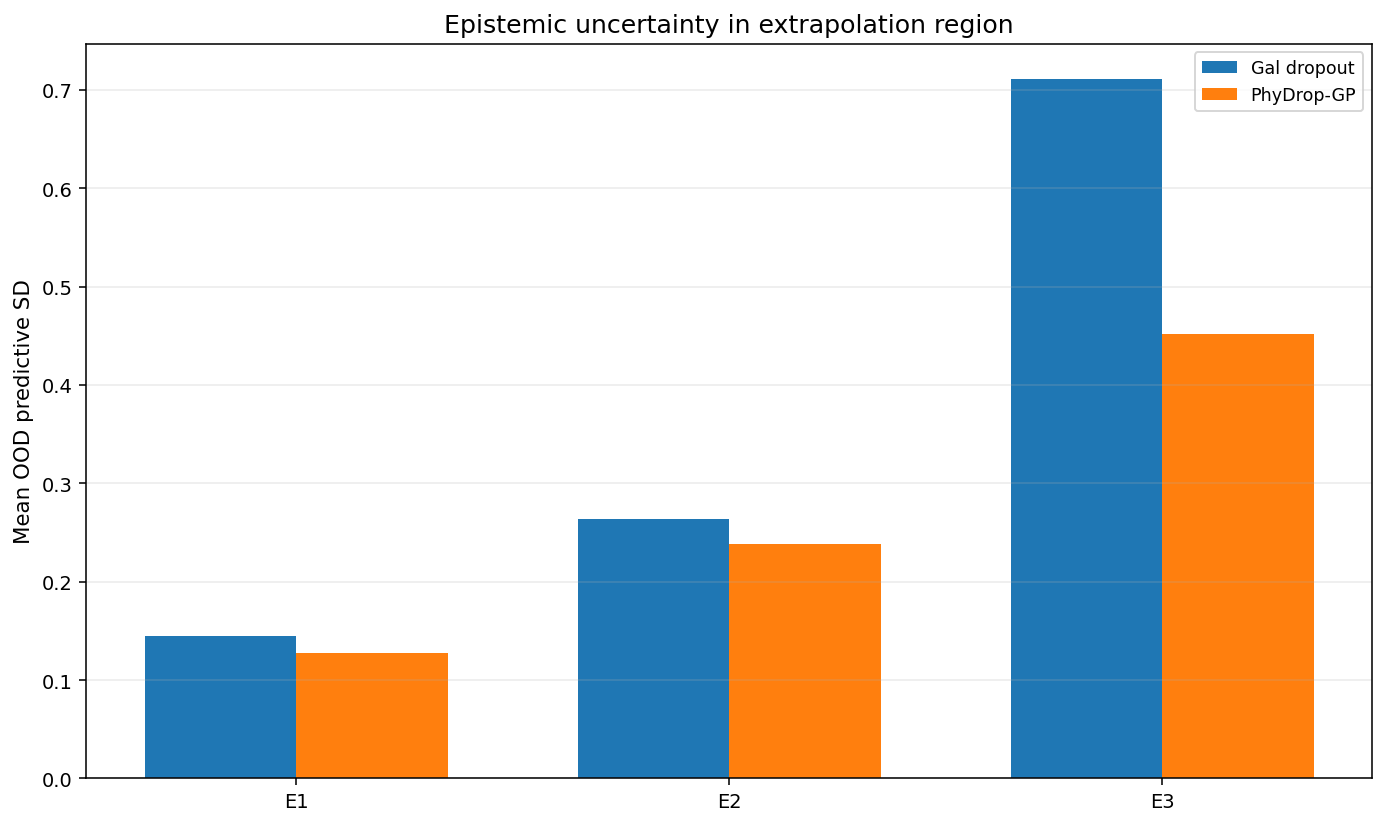

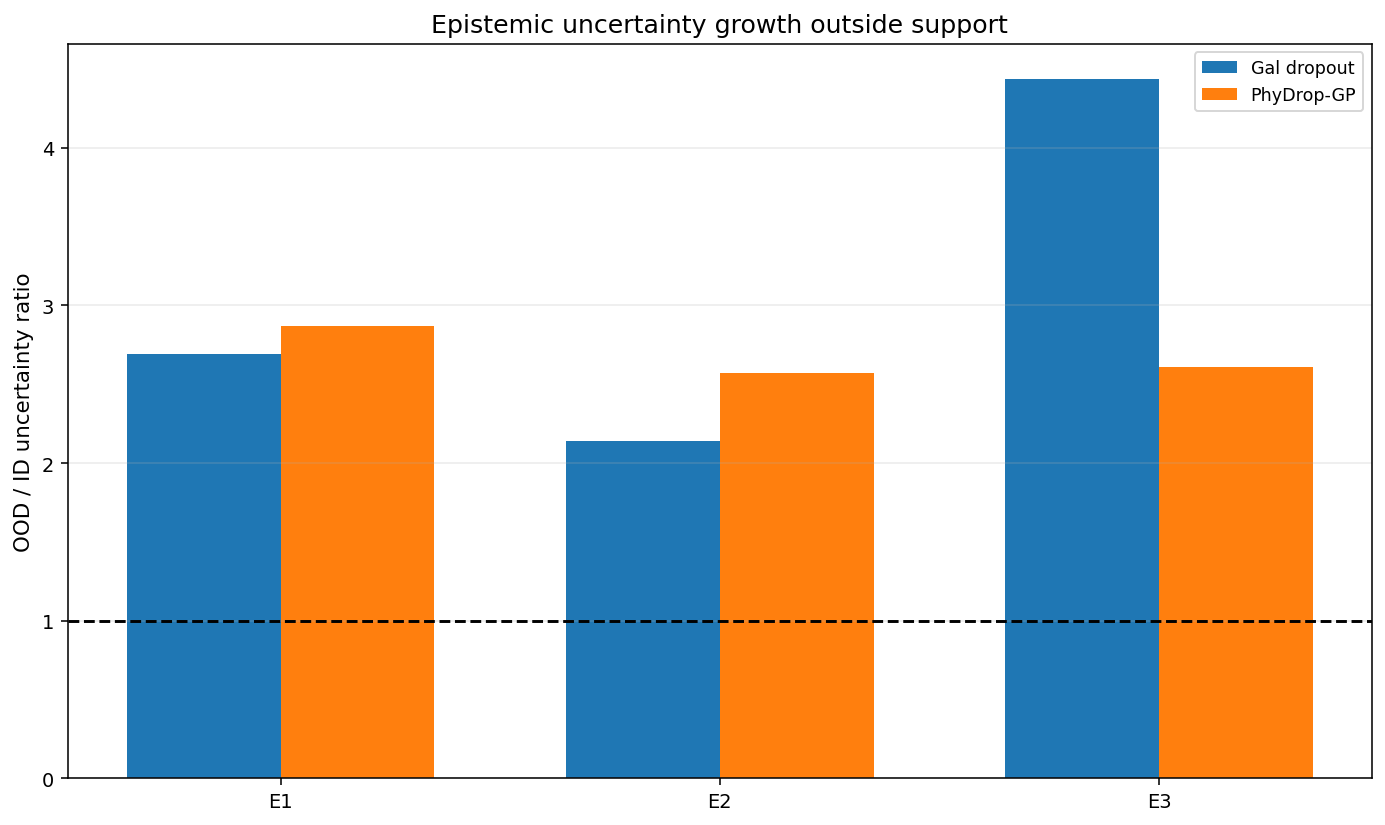

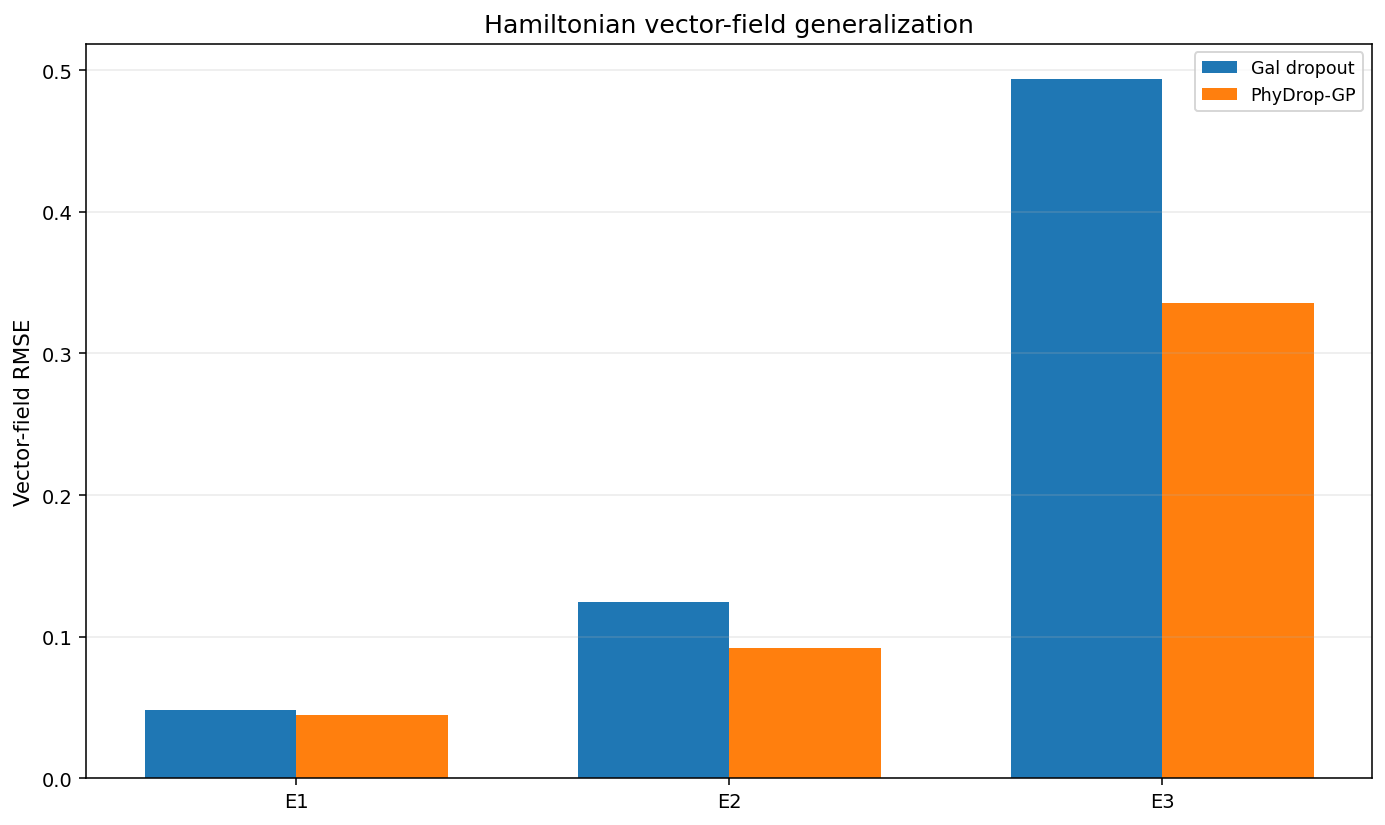



EXPERIMENT COMPLETE

PRIMARY RMSE RESULTS
E1: Gal mean RMSE = 0.122569, PhyDrop mean RMSE = 0.115109, improvement = 6.09%
E2: Gal mean RMSE = 0.517023, PhyDrop mean RMSE = 0.269997, improvement = 47.78%
E3: Gal mean RMSE = 1.603818, PhyDrop mean RMSE = 1.332982, improvement = 16.89%

UNCERTAINTY RESULTS
Gal_E1      : ID SD=0.053725, OOD SD=0.144770, OOD/ID=2.695
Phy_E1      : ID SD=0.044498, OOD SD=0.127754, OOD/ID=2.871
Gal_E2      : ID SD=0.123400, OOD SD=0.263982, OOD/ID=2.139
Phy_E2      : ID SD=0.092742, OOD SD=0.238205, OOD/ID=2.568
Gal_E3      : ID SD=0.160278, OOD SD=0.711299, OOD/ID=4.438
Phy_E3      : ID SD=0.173170, OOD SD=0.452145, OOD/ID=2.611

PHYSICS RESIDUAL
Supported-region physics RMSE = 0.04944925

VECTOR-FIELD GENERALIZATION
E1: Gal=0.04859538, PhyDrop=0.04489126
E2: Gal=0.12428498, PhyDrop=0.09196554
E3: Gal=0.49389324, PhyDrop=0.33521971


EXPERIMENTAL INTERPRETATION
E1 = supported/interpolation regime.
E2 = moderate OOD regime.
E3 = strong OOD regime.
Physics c

In [ ]:
import os
import math
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_num_threads(
        min(4,os.cpu_count() or 1)
    )
except Exception:
    pass

DEVICE=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("HAMILTONIAN PHYDROP-GP vs GAL-STYLE DROPOUT")
print("GENUINE OOD / EXTRAPOLATION EXPERIMENT")
print("Device:",DEVICE)

MASS=1.0
KAPPA=1.0
BETA=0.20

SIGMA_OBS=0.05
TAU_OBS=1.0/(SIGMA_OBS**2)

SIGMA_H=0.05
TAU_H=1.0/(SIGMA_H**2)

DROPOUT_RATE=0.10
LENGTHSCALE=0.01

N_DATA=2500
N_COLL=3000
N_VAL=1500

BATCH_DATA=512
BATCH_COLL=512

EPOCHS=450
LR=1e-3
HIDDEN=96

PHYSICS_MULTIPLIER=1.0
MC_SAMPLES=50

DT=0.02
ROLLOUT_TIME=12.0
TRAIN_TIME_CUTOFF=4.0

TRAIN_AMPS=[
    0.25,
    0.35,
    0.45,
    0.55,
    0.65,
    0.75,
    0.85
]

E1_AMP=0.70
E2_AMP=1.15
E3_AMP=1.55

T_DATA=np.linspace(
    0.0,
    8.0,
    1201
)

T_ROLL=np.arange(
    0.0,
    ROLLOUT_TIME+DT,
    DT
)

COLL_Q_MIN=-0.95
COLL_Q_MAX=0.95
COLL_P_MIN=-0.95
COLL_P_MAX=0.95

GAL_L2_COEFF=(
    LENGTHSCALE**2
    *(1.0-DROPOUT_RATE)
    /(2.0*N_DATA*TAU_OBS)
)

LAMBDA_H_THEORY=(
    TAU_H/
    (2.0*N_COLL)
)

LAMBDA_H_EFFECTIVE=(
    PHYSICS_MULTIPLIER*
    LAMBDA_H_THEORY
)

print("\nEXPERIMENTAL PARAMETERS")
print(f"MASS                         = {MASS}")
print(f"KAPPA                       = {KAPPA}")
print(f"BETA                        = {BETA}")
print(f"sigma_obs                   = {SIGMA_OBS}")
print(f"tau_obs                     = {TAU_OBS:.6f}")
print(f"sigma_H                     = {SIGMA_H}")
print(f"tau_H                       = {TAU_H:.6f}")
print(f"dropout rate                = {DROPOUT_RATE}")
print(f"lengthscale                = {LENGTHSCALE}")
print(
    f"Gal L2 coefficient          = "
    f"{GAL_L2_COEFF:.12e}"
)
print(f"N_data                      = {N_DATA}")
print(f"N_collocation               = {N_COLL}")
print(
    f"lambda_H theoretical        = "
    f"{LAMBDA_H_THEORY:.12e}"
)
print(
    f"physics multiplier          = "
    f"{PHYSICS_MULTIPLIER}"
)
print(
    f"lambda_H effective          = "
    f"{LAMBDA_H_EFFECTIVE:.12e}"
)
print(f"hidden units                = {HIDDEN}")
print(f"MC samples                 = {MC_SAMPLES}")
print(f"epochs                     = {EPOCHS}")
print(f"rollout time               = {ROLLOUT_TIME}")
print(f"dt                         = {DT}")
print(
    f"training time cutoff       = "
    f"{TRAIN_TIME_CUTOFF}"
)

print("\nENERGY REGIMES")
print(
    f"E1 amplitude               = "
    f"{E1_AMP}  [SUPPORTED]"
)
print(
    f"E2 amplitude               = "
    f"{E2_AMP}  [MODERATE OOD]"
)
print(
    f"E3 amplitude               = "
    f"{E3_AMP}  [STRONG OOD]"
)

print("\nPHYSICS COLLOCATION SUPPORT")
print(
    f"q range                    = "
    f"[{COLL_Q_MIN},{COLL_Q_MAX}]"
)
print(
    f"p range                    = "
    f"[{COLL_P_MIN},{COLL_P_MAX}]"
)
print(
    "\nIMPORTANT: E2 and E3 states are NOT sampled by "
    "the physics collocation procedure."
)

# Hamiltonian definition
def true_H_np(s):
    q=s[...,0]
    p=s[...,1]

    kinetic=(
        p**2/
        (2.0*MASS)
    )

    potential=(
        0.5*KAPPA*q**2+
        0.25*BETA*q**4
    )

    return kinetic+potential

# Hamiltonian vector field
def true_rhs_np(t,s):
    q,p=s

    dq=(
        p/
        MASS
    )

    dp=(
        -KAPPA*q-
        BETA*q**3
    )

    return np.array(
        [dq,dp]
    )

def true_rhs_torch(s):
    q=s[:,0]
    p=s[:,1]

    dq=(
        p/
        MASS
    )

    dp=(
        -KAPPA*q-
        BETA*q**3
    )

    return torch.stack(
        [dq,dp],
        dim=1
    )

# Simulation
def simulate(q0,p0,t):
    sol=solve_ivp(
        true_rhs_np,
        (
            t[0],
            t[-1]
        ),
        [
            q0,
            p0
        ],
        t_eval=t,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )

    if not sol.success:
        raise RuntimeError(
            sol.message
        )

    S=sol.y.T

    dS=np.array(
        [
            true_rhs_np(
                tt,
                ss
            )
            for tt,ss in zip(
                t,
                S
            )
        ]
    )

    return S,dS

S_all=[]
dS_all=[]

for amp in TRAIN_AMPS:
    s,ds=simulate(
        amp,
        0.0,
        T_DATA
    )

    S_all.append(s)
    dS_all.append(ds)

S_all=np.concatenate(
    S_all,
    axis=0
)

dS_all=np.concatenate(
    dS_all,
    axis=0
)

# Observational training data
idx=np.random.choice(
    len(S_all),
    N_DATA,
    replace=False
)

X_clean=S_all[idx]
Y_clean=dS_all[idx]

X_train=(
    X_clean+
    np.random.normal(
        0.0,
        SIGMA_OBS,
        X_clean.shape
    )
)

Y_train=(
    Y_clean+
    np.random.normal(
        0.0,
        SIGMA_OBS,
        Y_clean.shape
    )
)

rng=np.random.default_rng(
    SEED+123
)

q_val=rng.uniform(
    -0.90,
    0.90,
    N_VAL
)

p_val=rng.uniform(
    -0.90,
    0.90,
    N_VAL
)

X_val=np.column_stack(
    [
        q_val,
        p_val
    ]
).astype(
    np.float32
)

Y_val=np.column_stack(
    [
        X_val[:,1]/MASS,
        -KAPPA*X_val[:,0]-
        BETA*X_val[:,0]**3
    ]
).astype(
    np.float32
)

q_coll=rng.uniform(
    COLL_Q_MIN,
    COLL_Q_MAX,
    N_COLL
)

p_coll=rng.uniform(
    COLL_P_MIN,
    COLL_P_MAX,
    N_COLL
)

X_coll=np.column_stack(
    [
        q_coll,
        p_coll
    ]
).astype(
    np.float32
)

true_E1,true_dE1=simulate(
    E1_AMP,
    0.0,
    T_ROLL
)

true_E2,true_dE2=simulate(
    E2_AMP,
    0.0,
    T_ROLL
)

true_E3,true_dE3=simulate(
    E3_AMP,
    0.0,
    T_ROLL
)

def energy_summary(
    name,
    trajectory
):
    energy=true_H_np(
        trajectory
    )

    initial=energy[0]

    drift=np.max(
        np.abs(
            energy-
            initial
        )
    )

    print(
        f"{name} initial H = "
        f"{initial:.10f} | "
        f"maximum energy drift = "
        f"{drift:.10e}"
    )

def support_fraction(
    trajectory
):
    q=trajectory[:,0]
    p=trajectory[:,1]

    inside=(
        (q>=COLL_Q_MIN)&
        (q<=COLL_Q_MAX)&
        (p>=COLL_P_MIN)&
        (p<=COLL_P_MAX)
    )

    return np.mean(
        inside
    )

print("\nDATA")
print(
    "X_train:",
    X_train.shape
)
print(
    "Y_train:",
    Y_train.shape
)
print(
    "X_val:",
    X_val.shape
)
print(
    "Y_val:",
    Y_val.shape
)
print(
    "X_coll:",
    X_coll.shape
)

energy_summary(
    "E1",
    true_E1
)

energy_summary(
    "E2",
    true_E2
)

energy_summary(
    "E3",
    true_E3
)

print("\nSUPPORT CHECK")

for name,traj in [
    ("E1",true_E1),
    ("E2",true_E2),
    ("E3",true_E3)
]:
    frac=support_fraction(
        traj
    )

    print(
        f"{name}: fraction of rollout states "
        f"inside physics support = {frac:.4f}"
    )

print(
    "\nE2 and E3 should spend substantial time outside "
    "the physics-collocation domain."
)

Xtr=torch.tensor(
    X_train,
    dtype=torch.float32,
    device=DEVICE
)

Ytr=torch.tensor(
    Y_train,
    dtype=torch.float32,
    device=DEVICE
)

Xc=torch.tensor(
    X_coll,
    dtype=torch.float32,
    device=DEVICE
)

Xv=torch.tensor(
    X_val,
    dtype=torch.float32,
    device=DEVICE
)

Yv=torch.tensor(
    Y_val,
    dtype=torch.float32,
    device=DEVICE
)

# MC-dropout posterior approximation
class AlwaysOnDropout(
    nn.Module
):
    def __init__(
        self,
        p
    ):
        super().__init__()

        self.p=float(p)
        self.fixed_mask=None

    def forward(
        self,
        x
    ):
        if self.p==0.0:
            return x

        keep=1.0-self.p

        if self.fixed_mask is None:
            mask=torch.bernoulli(
                torch.full_like(
                    x,
                    keep
                )
            )
        else:
            if self.fixed_mask.shape!=x.shape:
                raise RuntimeError(
                    f"Fixed mask shape "
                    f"{self.fixed_mask.shape} "
                    f"!= activation shape "
                    f"{x.shape}"
                )

            mask=self.fixed_mask

        return (
            x*
            mask/
            keep
        )

    def set_fixed(
        self,
        shape
    ):
        keep=1.0-self.p

        self.fixed_mask=torch.bernoulli(
            torch.full(
                shape,
                keep,
                device=DEVICE
            )
        )

    def clear(
        self
    ):
        self.fixed_mask=None

# Neural-network building block
class MLP1D(
    nn.Module
):
    def __init__(
        self,
        hidden,
        p
    ):
        super().__init__()

        self.fc1=nn.Linear(
            1,
            hidden
        )

        self.d1=AlwaysOnDropout(
            p
        )

        self.fc2=nn.Linear(
            hidden,
            hidden
        )

        self.d2=AlwaysOnDropout(
            p
        )

        self.fc3=nn.Linear(
            hidden,
            hidden
        )

        self.d3=AlwaysOnDropout(
            p
        )

        self.out=nn.Linear(
            hidden,
            1
        )

    def forward(
        self,
        x
    ):
        x=torch.tanh(
            self.fc1(x)
        )

        x=self.d1(x)

        x=torch.tanh(
            self.fc2(x)
        )

        x=self.d2(x)

        x=torch.tanh(
            self.fc3(x)
        )

        x=self.d3(x)

        return self.out(x)

# Separable Hamiltonian neural network
class HamiltonianDropoutNet(
    nn.Module
):
    def __init__(
        self,
        hidden=96,
        p=0.10
    ):
        super().__init__()

        self.T_net=MLP1D(
            hidden,
            p
        )

        self.V_net=MLP1D(
            hidden,
            p
        )

    def forward(
        self,
        s
    ):
        if (
            s.ndim!=2
            or
            s.shape[1]!=2
        ):
            raise ValueError(
                f"Expected (N,2), "
                f"got {tuple(s.shape)}"
            )

        q=s[:,0:1]
        p=s[:,1:2]

        T=self.T_net(
            p
        )

        V=self.V_net(
            q
        )

        return (
            T+
            V
        ).squeeze(-1)

# Hamiltonian neural vector field J grad H_theta
def hamiltonian_vector_field(
    model,
    s,
    create_graph=True
):
    s=(
        s.clone()
        .detach()
        .requires_grad_(True)
    )

    H=model(
        s
    )

    grad_H=torch.autograd.grad(
        H.sum(),
        s,
        create_graph=create_graph,
        retain_graph=create_graph
    )[0]

    dH_dq=grad_H[:,0]
    dH_dp=grad_H[:,1]

    return torch.stack(
        [
            dH_dp,
            -dH_dq
        ],
        dim=1
    )

# Data likelihood
def data_nll(
    pred,
    target
):
    residual=(
        target-
        pred
    )

    return (
        0.5*
        TAU_OBS*
        torch.mean(
            residual**2
        )
    )

# Physics-informed likelihood
def physics_loss(
    model,
    s
):
    pred=hamiltonian_vector_field(
        model,
        s,
        create_graph=True
    )

    true=true_rhs_torch(
        s
    )

    residual=(
        true-
        pred
    )

    mse=torch.mean(
        residual**2
    )

    loss=(
        0.5*
        TAU_H*
        mse
    )

    return (
        loss,
        residual
    )

def l2_norm(
    model
):
    return sum(
        torch.sum(
            p**2
        )
        for p in model.parameters()
        if p.requires_grad
    )

def clean_vector_field_rmse(
    model,
    X,
    Y,
    mc=8
):
    model.eval()

    preds=[]

    for _ in range(mc):
        pred=hamiltonian_vector_field(
            model,
            X,
            create_graph=False
        )

        preds.append(
            pred.detach()
        )

    pred_mean=torch.stack(
        preds,
        dim=0
    ).mean(
        dim=0
    )

    rmse=torch.sqrt(
        torch.mean(
            (
                pred_mean-
                Y
            )**2
        )
    )

    return float(
        rmse.detach().cpu()
    )

# Joint training objective
def train_model(
    model,
    physics_on,
    name
):
    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    history={
        "total":[],
        "data":[],
        "physics":[],
        "reg":[],
        "val":[]
    }

    print("\n")

    if physics_on:
        print(
            "TRAINING PHYDROP-GP"
        )
    else:
        print(
            "TRAINING GAL-STYLE DROPOUT"
        )

    for epoch in range(
        1,
        EPOCHS+1
    ):
        model.train()

        idx_d=torch.randperm(
            N_DATA,
            device=DEVICE
        )[
            :min(
                BATCH_DATA,
                N_DATA
            )
        ]

        idx_c=torch.randperm(
            N_COLL,
            device=DEVICE
        )[
            :min(
                BATCH_COLL,
                N_COLL
            )
        ]

        xb=Xtr[
            idx_d
        ]

        yb=Ytr[
            idx_d
        ]

        cb=Xc[
            idx_c
        ]

        pred=hamiltonian_vector_field(
            model,
            xb,
            create_graph=True
        )

        loss_data=data_nll(
            pred,
            yb
        )

        if physics_on:
            loss_phys_raw,residual=physics_loss(
                model,
                cb
            )

            loss_phys=(
                PHYSICS_MULTIPLIER*
                loss_phys_raw
            )
        else:
            loss_phys=torch.tensor(
                0.0,
                device=DEVICE
            )

        loss_reg=(
            GAL_L2_COEFF*
            l2_norm(
                model
            )
        )

        total=(
            loss_data+
            loss_phys+
            loss_reg
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        total.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            10.0
        )

        optimizer.step()

        history[
            "total"
        ].append(
            float(
                total.detach().cpu()
            )
        )

        history[
            "data"
        ].append(
            float(
                loss_data.detach().cpu()
            )
        )

        history[
            "physics"
        ].append(
            float(
                loss_phys.detach().cpu()
            )
        )

        history[
            "reg"
        ].append(
            float(
                loss_reg.detach().cpu()
            )
        )

        if (
            epoch==1
            or
            epoch%50==0
            or
            epoch==EPOCHS
        ):
            val_rmse=clean_vector_field_rmse(
                model,
                Xv,
                Yv,
                mc=8
            )

            history[
                "val"
            ].append(
                (
                    epoch,
                    val_rmse
                )
            )

            print(
                f"[{name}] "
                f"epoch {epoch:4d}/{EPOCHS} | "
                f"total={history['total'][-1]:.6e} | "
                f"data={history['data'][-1]:.6e} | "
                f"physics={history['physics'][-1]:.6e} | "
                f"reg={history['reg'][-1]:.6e} | "
                f"val RMSE={val_rmse:.6f}"
            )
        else:
            history[
                "val"
            ].append(
                (
                    epoch,
                    np.nan
                )
            )

    return history

base=HamiltonianDropoutNet(
    HIDDEN,
    DROPOUT_RATE
).to(
    DEVICE
)

initial_state_dict=copy.deepcopy(
    base.state_dict()
)

gal=HamiltonianDropoutNet(
    HIDDEN,
    DROPOUT_RATE
).to(
    DEVICE
)

gal.load_state_dict(
    initial_state_dict
)

phydrop=HamiltonianDropoutNet(
    HIDDEN,
    DROPOUT_RATE
).to(
    DEVICE
)

phydrop.load_state_dict(
    initial_state_dict
)

hist_gal=train_model(
    gal,
    physics_on=False,
    name="GAL"
)

hist_phy=train_model(
    phydrop,
    physics_on=True,
    name="PHYDROP"
)

def set_fixed_masks(
    model,
    n
):
    model.T_net.d1.set_fixed(
        (
            n,
            HIDDEN
        )
    )

    model.T_net.d2.set_fixed(
        (
            n,
            HIDDEN
        )
    )

    model.T_net.d3.set_fixed(
        (
            n,
            HIDDEN
        )
    )

    model.V_net.d1.set_fixed(
        (
            n,
            HIDDEN
        )
    )

    model.V_net.d2.set_fixed(
        (
            n,
            HIDDEN
        )
    )

    model.V_net.d3.set_fixed(
        (
            n,
            HIDDEN
        )
    )

def clear_masks(
    model
):
    modules=[
        model.T_net.d1,
        model.T_net.d2,
        model.T_net.d3,
        model.V_net.d1,
        model.V_net.d2,
        model.V_net.d3
    ]

    for module in modules:
        module.clear()

def dT_dp(
    model,
    p
):
    p=(
        p.clone()
        .detach()
        .requires_grad_(True)
    )

    T=model.T_net(
        p.reshape(
            -1,
            1
        )
    ).squeeze(-1)

    grad=torch.autograd.grad(
        T.sum(),
        p,
        create_graph=False
    )[0]

    return grad

def dV_dq(
    model,
    q
):
    q=(
        q.clone()
        .detach()
        .requires_grad_(True)
    )

    V=model.V_net(
        q.reshape(
            -1,
            1
        )
    ).squeeze(-1)

    grad=torch.autograd.grad(
        V.sum(),
        q,
        create_graph=False
    )[0]

    return grad

# Symplectic leapfrog rollout
def leapfrog_step(
    model,
    s,
    dt
):
    q=s[:,0]
    p=s[:,1]

    force_q=dV_dq(
        model,
        q
    )

    p_half=(
        p-
        0.5*
        dt*
        force_q
    )

    velocity=dT_dp(
        model,
        p_half
    )

    q_new=(
        q+
        dt*
        velocity
    )

    force_new=dV_dq(
        model,
        q_new
    )

    p_new=(
        p_half-
        0.5*
        dt*
        force_new
    )

    return torch.stack(
        [
            q_new,
            p_new
        ],
        dim=1
    ).detach()

# Monte Carlo posterior predictive rollout
def mc_rollout(
    model,
    initial_state,
    t,
    n_mc=50
):
    model.eval()

    s0=torch.tensor(
        initial_state,
        dtype=torch.float32,
        device=DEVICE
    ).reshape(
        1,
        2
    )

    s=s0.repeat(
        n_mc,
        1
    )

    set_fixed_masks(
        model,
        n_mc
    )

    outputs=[
        s.detach()
        .cpu()
        .numpy()
    ]

    for k in range(
        len(t)-1
    ):
        dt=float(
            t[k+1]-
            t[k]
        )

        s=leapfrog_step(
            model,
            s,
            dt
        )

        outputs.append(
            s.detach()
            .cpu()
            .numpy()
        )

    clear_masks(
        model
    )

    return np.stack(
        outputs,
        axis=1
    )

print("\n")
print(
    "MC DROPOUT HAMILTONIAN ROLLOUTS"
)

gal_E1=mc_rollout(
    gal,
    true_E1[0],
    T_ROLL,
    MC_SAMPLES
)

gal_E2=mc_rollout(
    gal,
    true_E2[0],
    T_ROLL,
    MC_SAMPLES
)

gal_E3=mc_rollout(
    gal,
    true_E3[0],
    T_ROLL,
    MC_SAMPLES
)

phy_E1=mc_rollout(
    phydrop,
    true_E1[0],
    T_ROLL,
    MC_SAMPLES
)

phy_E2=mc_rollout(
    phydrop,
    true_E2[0],
    T_ROLL,
    MC_SAMPLES
)

phy_E3=mc_rollout(
    phydrop,
    true_E3[0],
    T_ROLL,
    MC_SAMPLES
)

def mean_std(
    A
):
    return (
        np.mean(
            A,
            axis=0
        ),
        np.std(
            A,
            axis=0,
            ddof=1
        )
    )

# Evaluation metrics
def rmse_curve(
    A,
    true
):
    return np.sqrt(
        np.mean(
            (
                A-
                true[
                    None,
                    :,
                    :
                ]
            )**2,
            axis=(
                0,
                2
            )
        )
    )

def energy_error_curve(
    A,
    true
):
    energies=true_H_np(
        A.reshape(
            -1,
            2
        )
    ).reshape(
        A.shape[0],
        A.shape[1]
    )

    true_energy=true_H_np(
        true
    )

    return np.mean(
        np.abs(
            energies-
            true_energy[
                None,
                :
            ]
        ),
        axis=0
    )

# Predictive log likelihood
def predictive_loglikelihood(
    A,
    true,
    sigma=SIGMA_OBS
):
    mu=np.mean(
        A,
        axis=0
    )

    sd=np.std(
        A,
        axis=0,
        ddof=1
    )

    variance=(
        sd**2+
        sigma**2+
        1e-6
    )

    diff=(
        true-
        mu
    )

    ll=(
        -0.5*
        np.sum(
            diff**2/
            variance,
            axis=1
        )-
        0.5*
        np.sum(
            np.log(
                2.0*
                np.pi*
                variance
            ),
            axis=1
        )
    )

    return ll

# Empirical uncertainty coverage
def coverage_curve(
    A,
    true
):
    mu,sd=mean_std(
        A
    )

    z=np.abs(
        true-
        mu
    )

    cov1=np.mean(
        z<=sd,
        axis=1
    )

    cov2=np.mean(
        z<=2.0*sd,
        axis=1
    )

    return (
        cov1,
        cov2
    )

results={}

for name,A,true in [
    (
        "Gal_E1",
        gal_E1,
        true_E1
    ),
    (
        "Phy_E1",
        phy_E1,
        true_E1
    ),
    (
        "Gal_E2",
        gal_E2,
        true_E2
    ),
    (
        "Phy_E2",
        phy_E2,
        true_E2
    ),
    (
        "Gal_E3",
        gal_E3,
        true_E3
    ),
    (
        "Phy_E3",
        phy_E3,
        true_E3
    )
]:

    mu,sd=mean_std(
        A
    )

    rmse=rmse_curve(
        A,
        true
    )

    energy=energy_error_curve(
        A,
        true
    )

    pll=predictive_loglikelihood(
        A,
        true
    )

    cov1,cov2=coverage_curve(
        A,
        true
    )

    results[name]={
        "mean":mu,
        "sd":sd,
        "rmse":rmse,
        "energy":energy,
        "pll":pll,
        "cov1":cov1,
        "cov2":cov2
    }

train_mask=(
    T_ROLL<=
    TRAIN_TIME_CUTOFF
)

extra_mask=(
    T_ROLL>
    TRAIN_TIME_CUTOFF
)

def summarize(
    result,
    mask
):
    return {
        "rmse":
            float(
                np.mean(
                    result["rmse"][
                        mask
                    ]
                )
            ),
        "energy":
            float(
                np.mean(
                    result["energy"][
                        mask
                    ]
                )
            ),
        "pll":
            float(
                np.mean(
                    result["pll"][
                        mask
                    ]
                )
            ),
        "sd":
            float(
                np.mean(
                    result["sd"][
                        mask
                    ]
                )
            )
    }

summary={}

for regime in [
    "E1",
    "E2",
    "E3"
]:
    for model in [
        "Gal",
        "Phy"
    ]:
        key=f"{model}_{regime}"

        summary[
            f"{key}_train"
        ]=summarize(
            results[key],
            train_mask
        )

        summary[
            f"{key}_extra"
        ]=summarize(
            results[key],
            extra_mask
        )

print("\n")
print(
    "FINAL HAMILTONIAN PHYDROP-GP RESULTS"
)

print(
    f"{'Regime':<8}"
    f"{'Model':<16}"
    f"{'Final RMSE':>14}"
    f"{'Mean RMSE':>14}"
    f"{'Final |dE|':>15}"
    f"{'Mean PLL':>15}"
    f"{'Mean SD':>14}"
)

for regime in [
    "E1",
    "E2",
    "E3"
]:

    for model,prefix in [
        (
            "Gal Dropout",
            "Gal"
        ),
        (
            "PhyDrop-GP",
            "Phy"
        )
    ]:

        key=f"{prefix}_{regime}"
        r=results[key]

        print(
            f"{regime:<8}"
            f"{model:<16}"
            f"{r['rmse'][-1]:>14.6f}"
            f"{np.mean(r['rmse']):>14.6f}"
            f"{r['energy'][-1]:>15.6f}"
            f"{np.mean(r['pll']):>15.6f}"
            f"{np.mean(r['sd']):>14.6f}"
        )

print("\n")
print(
    "RMSE COMPARISON"
)

for regime in [
    "E1",
    "E2",
    "E3"
]:

    gal_key=(
        "Gal_"+
        regime
    )

    phy_key=(
        "Phy_"+
        regime
    )

    gal_final=results[
        gal_key
    ]["rmse"][-1]

    phy_final=results[
        phy_key
    ]["rmse"][-1]

    gal_mean=np.mean(
        results[
            gal_key
        ]["rmse"]
    )

    phy_mean=np.mean(
        results[
            phy_key
        ]["rmse"]
    )

    final_improvement=(
        100.0*
        (
            gal_final-
            phy_final
        )/
        (
            gal_final+
            1e-12
        )
    )

    mean_improvement=(
        100.0*
        (
            gal_mean-
            phy_mean
        )/
        (
            gal_mean+
            1e-12
        )
    )

    print(
        f"\n{regime}"
    )

    print(
        f"Gal final RMSE        : "
        f"{gal_final:.8f}"
    )

    print(
        f"PhyDrop final RMSE    : "
        f"{phy_final:.8f}"
    )

    print(
        f"Gal mean RMSE         : "
        f"{gal_mean:.8f}"
    )

    print(
        f"PhyDrop mean RMSE     : "
        f"{phy_mean:.8f}"
    )

    print(
        f"Final improvement     : "
        f"{final_improvement:.2f}%"
    )

    print(
        f"Mean improvement      : "
        f"{mean_improvement:.2f}%"
    )

    if phy_final<gal_final:
        print(
            "RESULT: PhyDrop final RMSE "
            "is LOWER."
        )
    else:
        print(
            "RESULT: Gal final RMSE "
            "is LOWER."
        )

    if phy_mean<gal_mean:
        print(
            "RESULT: PhyDrop mean RMSE "
            "is LOWER."
        )
    else:
        print(
            "RESULT: Gal mean RMSE "
            "is LOWER."
        )

print("\n")
print(
    "TRAINING-SUPPORTED vs EXTRAPOLATION PERFORMANCE"
)

print(
    f"{'Regime':<8}"
    f"{'Model':<16}"
    f"{'Region':<18}"
    f"{'RMSE':>12}"
    f"{'Energy error':>16}"
    f"{'PLL':>16}"
    f"{'SD':>12}"
)

for regime in [
    "E1",
    "E2",
    "E3"
]:

    for model,prefix in [
        (
            "Gal Dropout",
            "Gal"
        ),
        (
            "PhyDrop-GP",
            "Phy"
        )
    ]:

        for region,suffix in [
            (
                "Training",
                "train"
            ),
            (
                "Extrapolation",
                "extra"
            )
        ]:

            s=summary[
                f"{prefix}_{regime}_{suffix}"
            ]

            print(
                f"{regime:<8}"
                f"{model:<16}"
                f"{region:<18}"
                f"{s['rmse']:>12.6f}"
                f"{s['energy']:>16.6f}"
                f"{s['pll']:>16.6f}"
                f"{s['sd']:>12.6f}"
            )

print("\n")
print(
    "EPISTEMIC UNCERTAINTY GROWTH"
)

for regime in [
    "E1",
    "E2",
    "E3"
]:

    for model in [
        "Gal",
        "Phy"
    ]:

        key=f"{model}_{regime}"

        sd_train=np.mean(
            results[key]["sd"][
                train_mask
            ]
        )

        sd_extra=np.mean(
            results[key]["sd"][
                extra_mask
            ]
        )

        ratio=(
            sd_extra/
            (
                sd_train+
                1e-12
            )
        )

        print(
            f"{key:<12} | "
            f"ID SD = {sd_train:.6f} | "
            f"OOD SD = {sd_extra:.6f} | "
            f"OOD/ID = {ratio:.3f}"
        )

residual_chunks=[]

for start in range(
    0,
    N_COLL,
    BATCH_COLL
):

    stop=min(
        start+BATCH_COLL,
        N_COLL
    )

    cb=Xc[
        start:stop
    ]

    _,residual=physics_loss(
        phydrop,
        cb
    )

    residual_chunks.append(
        residual.detach()
        .cpu()
        .numpy()
    )

physics_residuals=np.concatenate(
    residual_chunks,
    axis=0
)

physics_rmse=np.sqrt(
    np.mean(
        physics_residuals**2
    )
)

print("\n")
print(
    "PHYSICS RESIDUAL DIAGNOSTIC"
)

print(
    f"PhyDrop supported-region physics RMSE = "
    f"{physics_rmse:.8f}"
)

def evaluate_physics_rmse(
    model,
    trajectory
):
    s=torch.tensor(
        trajectory,
        dtype=torch.float32,
        device=DEVICE
    )

    pred=hamiltonian_vector_field(
        model,
        s,
        create_graph=False
    )

    true=true_rhs_torch(
        s
    )

    residual=(
        true-
        pred
    )

    return float(
        torch.sqrt(
            torch.mean(
                residual**2
            )
        )
        .detach()
        .cpu()
    )

phy_vector_rmse_E1=evaluate_physics_rmse(
    phydrop,
    true_E1
)

phy_vector_rmse_E2=evaluate_physics_rmse(
    phydrop,
    true_E2
)

phy_vector_rmse_E3=evaluate_physics_rmse(
    phydrop,
    true_E3
)

gal_vector_rmse_E1=evaluate_physics_rmse(
    gal,
    true_E1
)

gal_vector_rmse_E2=evaluate_physics_rmse(
    gal,
    true_E2
)

gal_vector_rmse_E3=evaluate_physics_rmse(
    gal,
    true_E3
)

print("\n")
print(
    "VECTOR-FIELD OOD DIAGNOSTIC"
)

print(
    f"Gal E1 vector-field RMSE       = "
    f"{gal_vector_rmse_E1:.8f}"
)

print(
    f"PhyDrop E1 vector-field RMSE   = "
    f"{phy_vector_rmse_E1:.8f}"
)

print(
    f"Gal E2 vector-field RMSE       = "
    f"{gal_vector_rmse_E2:.8f}"
)

print(
    f"PhyDrop E2 vector-field RMSE   = "
    f"{phy_vector_rmse_E2:.8f}"
)

print(
    f"Gal E3 vector-field RMSE       = "
    f"{gal_vector_rmse_E3:.8f}"
)

print(
    f"PhyDrop E3 vector-field RMSE   = "
    f"{phy_vector_rmse_E3:.8f}"
)

plt.rcParams.update(
    {
        "figure.dpi":140,
        "axes.titlesize":13,
        "axes.labelsize":11,
        "legend.fontsize":9,
        "font.size":10
    }
)

PLOT_ROLLOUT_TIME=48.0
PLOT_TRAIN_TIME_CUTOFF=30.0

PLOT_T_ROLL=np.arange(
    0.0,
    PLOT_ROLLOUT_TIME+DT,
    DT
)

print("\n")
print(
    "PLOT-ONLY LONG-HORIZON ROLLOUT"
)

print(
    f"Plot-only horizon       = "
    f"{PLOT_ROLLOUT_TIME}"
)

print(
    f"Plot-only OOD boundary  = "
    f"{PLOT_TRAIN_TIME_CUTOFF}"
)

print(
    "IMPORTANT: These values affect "
    "visualization only."
)

print(
    "All numerical metrics above remain based on "
    f"the original T_ROLL = 0 ... {ROLLOUT_TIME}."
)

plot_true_E1,plot_true_dE1=simulate(
    E1_AMP,
    0.0,
    PLOT_T_ROLL
)

plot_true_E2,plot_true_dE2=simulate(
    E2_AMP,
    0.0,
    PLOT_T_ROLL
)

plot_true_E3,plot_true_dE3=simulate(
    E3_AMP,
    0.0,
    PLOT_T_ROLL
)

print(
    "\nGenerating plot-only long-horizon Gal rollouts..."
)

plot_gal_E1=mc_rollout(
    gal,
    plot_true_E1[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

plot_gal_E2=mc_rollout(
    gal,
    plot_true_E2[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

plot_gal_E3=mc_rollout(
    gal,
    plot_true_E3[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

print(
    "Generating plot-only long-horizon PhyDrop rollouts..."
)

plot_phy_E1=mc_rollout(
    phydrop,
    plot_true_E1[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

plot_phy_E2=mc_rollout(
    phydrop,
    plot_true_E2[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

plot_phy_E3=mc_rollout(
    phydrop,
    plot_true_E3[0],
    PLOT_T_ROLL,
    MC_SAMPLES
)

print(
    "Plot-only long-horizon rollouts complete."
)

# Long-horizon trajectory figure
def enhanced_long_horizon_trajectory_figure(
    true,
    gal_A,
    phy_A,
    regime,
    ax_q,
    ax_p
):
    gal_mu,gal_sd=mean_std(
        gal_A
    )

    phy_mu,phy_sd=mean_std(
        phy_A
    )

    ax_q.plot(
        PLOT_T_ROLL,
        true[:,0],
        color="black",
        linewidth=2.8,
        label="True"
    )

    ax_q.plot(
        PLOT_T_ROLL,
        gal_mu[:,0],
        color="tab:blue",
        linestyle="--",
        linewidth=2.0,
        label="Gal dropout"
    )

    ax_q.fill_between(
        PLOT_T_ROLL,
        gal_mu[:,0]-2.0*gal_sd[:,0],
        gal_mu[:,0]+2.0*gal_sd[:,0],
        color="tab:blue",
        alpha=0.12
    )

    ax_q.plot(
        PLOT_T_ROLL,
        phy_mu[:,0],
        color="tab:red",
        linestyle="-",
        linewidth=2.2,
        label="PhyDrop-GP"
    )

    ax_q.fill_between(
        PLOT_T_ROLL,
        phy_mu[:,0]-2.0*phy_sd[:,0],
        phy_mu[:,0]+2.0*phy_sd[:,0],
        color="tab:red",
        alpha=0.16
    )

    ax_p.plot(
        PLOT_T_ROLL,
        true[:,1],
        color="black",
        linewidth=2.8,
        label="True"
    )

    ax_p.plot(
        PLOT_T_ROLL,
        gal_mu[:,1],
        color="tab:blue",
        linestyle="--",
        linewidth=2.0,
        label="Gal dropout"
    )

    ax_p.fill_between(
        PLOT_T_ROLL,
        gal_mu[:,1]-2.0*gal_sd[:,1],
        gal_mu[:,1]+2.0*gal_sd[:,1],
        color="tab:blue",
        alpha=0.12
    )

    ax_p.plot(
        PLOT_T_ROLL,
        phy_mu[:,1],
        color="tab:red",
        linestyle="-",
        linewidth=2.2,
        label="PhyDrop-GP"
    )

    ax_p.fill_between(
        PLOT_T_ROLL,
        phy_mu[:,1]-2.0*phy_sd[:,1],
        phy_mu[:,1]+2.0*phy_sd[:,1],
        color="tab:red",
        alpha=0.16
    )

    for ax in [
        ax_q,
        ax_p
    ]:
        ax.axvspan(
            PLOT_T_ROLL[0],
            PLOT_TRAIN_TIME_CUTOFF,
            color="gray",
            alpha=0.06
        )

        ax.axvspan(
            PLOT_TRAIN_TIME_CUTOFF,
            PLOT_T_ROLL[-1],
            color="orange",
            alpha=0.07
        )

        ax.axvline(
            PLOT_TRAIN_TIME_CUTOFF,
            color="black",
            linestyle=":",
            linewidth=2.2
        )

        ax.grid(
            alpha=0.25
        )

        ax.set_xlim(
            PLOT_T_ROLL[0],
            PLOT_T_ROLL[-1]
        )

    ax_q.text(
        PLOT_TRAIN_TIME_CUTOFF-0.5,
        0.96,
        "supported",
        transform=ax_q.get_xaxis_transform(),
        ha="right",
        va="top",
        fontsize=10
    )

    ax_q.text(
        PLOT_TRAIN_TIME_CUTOFF+0.5,
        0.96,
        "extrapolation",
        transform=ax_q.get_xaxis_transform(),
        ha="left",
        va="top",
        fontsize=10
    )

    ax_p.text(
        PLOT_TRAIN_TIME_CUTOFF-0.5,
        0.96,
        "supported",
        transform=ax_p.get_xaxis_transform(),
        ha="right",
        va="top",
        fontsize=10
    )

    ax_p.text(
        PLOT_TRAIN_TIME_CUTOFF+0.5,
        0.96,
        "extrapolation",
        transform=ax_p.get_xaxis_transform(),
        ha="left",
        va="top",
        fontsize=10
    )

    ax_q.set_title(
        f"{regime}: Position $q(t)$"
    )

    ax_p.set_title(
        f"{regime}: Momentum $p(t)$"
    )

    ax_q.set_ylabel(
        "$q(t)$"
    )

    ax_p.set_ylabel(
        "$p(t)$"
    )

    ax_q.set_xlabel(
        "Time"
    )

    ax_p.set_xlabel(
        "Time"
    )

fig,axes=plt.subplots(
    3,
    2,
    figsize=(17,14),
    sharex=True
)

long_plot_items=[
    (
        plot_true_E1,
        plot_gal_E1,
        plot_phy_E1,
        "E1"
    ),
    (
        plot_true_E2,
        plot_gal_E2,
        plot_phy_E2,
        "E2"
    ),
    (
        plot_true_E3,
        plot_gal_E3,
        plot_phy_E3,
        "E3"
    )
]

for row,(
    true,
    gal_A,
    phy_A,
    regime
) in enumerate(
    long_plot_items
):
    enhanced_long_horizon_trajectory_figure(
        true,
        gal_A,
        phy_A,
        regime,
        axes[row,0],
        axes[row,1]
    )

handles,labels=axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5,0.995),
    frameon=True
)

fig.suptitle(
    "Hamiltonian Dynamics: Long-Horizon Interpolation and Extrapolation",
    fontsize=17,
    y=1.02
)

fig.text(
    0.5,
    0.005,
    "Shaded bands = ±2σ MC-dropout uncertainty. "
    "Dotted line = visualization-only extrapolation boundary. "
    "The underlying numerical experiment remains unchanged.",
    ha="center",
    fontsize=10
)

fig.tight_layout(
    rect=[
        0,
        0.025,
        1,
        0.965
    ]
)

plt.show()
plt.close(fig)

fig,axes=plt.subplots(
    1,
    3,
    figsize=(19,6)
)

phase_items_long=[
    (
        axes[0],
        plot_true_E1,
        plot_gal_E1,
        plot_phy_E1,
        "E1"
    ),
    (
        axes[1],
        plot_true_E2,
        plot_gal_E2,
        plot_phy_E2,
        "E2"
    ),
    (
        axes[2],
        plot_true_E3,
        plot_gal_E3,
        plot_phy_E3,
        "E3"
    )
]

for (
    ax,
    true,
    gal_A,
    phy_A,
    regime
) in phase_items_long:

    gal_mu,gal_sd=mean_std(
        gal_A
    )

    phy_mu,phy_sd=mean_std(
        phy_A
    )

    ax.plot(
        true[:,0],
        true[:,1],
        color="black",
        linewidth=2.8,
        label="True"
    )

    ax.plot(
        gal_mu[:,0],
        gal_mu[:,1],
        color="tab:blue",
        linestyle="--",
        linewidth=2.0,
        label="Gal dropout"
    )

    ax.plot(
        phy_mu[:,0],
        phy_mu[:,1],
        color="tab:red",
        linestyle="-",
        linewidth=2.2,
        label="PhyDrop-GP"
    )

    ax.axvline(
        COLL_Q_MIN,
        color="gray",
        linestyle=":",
        linewidth=1.2
    )

    ax.axvline(
        COLL_Q_MAX,
        color="gray",
        linestyle=":",
        linewidth=1.2
    )

    ax.axhline(
        COLL_P_MIN,
        color="gray",
        linestyle=":",
        linewidth=1.2
    )

    ax.axhline(
        COLL_P_MAX,
        color="gray",
        linestyle=":",
        linewidth=1.2
    )

    ax.scatter(
        true[0,0],
        true[0,1],
        s=70,
        color="black",
        marker="o",
        zorder=10
    )

    ax.set_title(
        f"{regime}: long-horizon phase space"
    )

    ax.set_xlabel(
        "$q$"
    )

    if regime=="E1":
        ax.set_ylabel(
            "$p$"
        )

    ax.grid(
        alpha=0.25
    )

handles,labels=axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5,1.01)
)

fig.suptitle(
    "Long-Horizon Hamiltonian Phase-Space Preservation",
    fontsize=16,
    y=1.06
)

fig.tight_layout()

plt.show()
plt.close(fig)

def plot_only_rmse_curve(
    A,
    true
):
    return np.sqrt(
        np.mean(
            (
                A-
                true[
                    None,
                    :,
                    :
                ]
            )**2,
            axis=(
                0,
                2
            )
        )
    )

def plot_only_energy_error(
    A,
    true
):
    energies=true_H_np(
        A.reshape(
            -1,
            2
        )
    ).reshape(
        A.shape[0],
        A.shape[1]
    )

    true_energy=true_H_np(
        true
    )

    return np.mean(
        np.abs(
            energies-
            true_energy[
                None,
                :
            ]
        ),
        axis=0
    )

fig,axes=plt.subplots(
    3,
    2,
    figsize=(17,14),
    sharex=True
)

plot_metric_items=[
    (
        "E1",
        plot_true_E1,
        plot_gal_E1,
        plot_phy_E1
    ),
    (
        "E2",
        plot_true_E2,
        plot_gal_E2,
        plot_phy_E2
    ),
    (
        "E3",
        plot_true_E3,
        plot_gal_E3,
        plot_phy_E3
    )
]

for row,(
    regime,
    true,
    gal_A,
    phy_A
) in enumerate(
    plot_metric_items
):

    gal_rmse=plot_only_rmse_curve(
        gal_A,
        true
    )

    phy_rmse=plot_only_rmse_curve(
        phy_A,
        true
    )

    gal_energy=plot_only_energy_error(
        gal_A,
        true
    )

    phy_energy=plot_only_energy_error(
        phy_A,
        true
    )

    axes[row,0].plot(
        PLOT_T_ROLL,
        gal_rmse,
        color="tab:blue",
        linestyle="--",
        linewidth=2.2,
        label="Gal dropout"
    )

    axes[row,0].plot(
        PLOT_T_ROLL,
        phy_rmse,
        color="tab:red",
        linestyle="-",
        linewidth=2.4,
        label="PhyDrop-GP"
    )

    axes[row,0].axvline(
        PLOT_TRAIN_TIME_CUTOFF,
        color="black",
        linestyle=":",
        linewidth=2
    )

    axes[row,0].axvspan(
        PLOT_TRAIN_TIME_CUTOFF,
        PLOT_T_ROLL[-1],
        color="orange",
        alpha=0.06
    )

    axes[row,0].set_title(
        f"{regime}: long-horizon trajectory RMSE"
    )

    axes[row,0].set_ylabel(
        "RMSE"
    )

    axes[row,0].grid(
        alpha=0.25
    )

    axes[row,1].plot(
        PLOT_T_ROLL,
        gal_energy,
        color="tab:blue",
        linestyle="--",
        linewidth=2.2,
        label="Gal dropout"
    )

    axes[row,1].plot(
        PLOT_T_ROLL,
        phy_energy,
        color="tab:red",
        linestyle="-",
        linewidth=2.4,
        label="PhyDrop-GP"
    )

    axes[row,1].axvline(
        PLOT_TRAIN_TIME_CUTOFF,
        color="black",
        linestyle=":",
        linewidth=2
    )

    axes[row,1].axvspan(
        PLOT_TRAIN_TIME_CUTOFF,
        PLOT_T_ROLL[-1],
        color="orange",
        alpha=0.06
    )

    axes[row,1].set_title(
        f"{regime}: long-horizon Hamiltonian energy error"
    )

    axes[row,1].set_ylabel(
        "$|H-H_0|$"
    )

    axes[row,1].grid(
        alpha=0.25
    )

for ax in axes[-1]:
    ax.set_xlabel(
        "Time"
    )

handles,labels=axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5,1.0)
)

fig.suptitle(
    "Long-Horizon Prediction Accuracy and Hamiltonian Energy Preservation",
    fontsize=16,
    y=1.025
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)

plt.show()
plt.close(fig)

fig,axes=plt.subplots(
    3,
    2,
    figsize=(17,14),
    sharex=True
)

uncertainty_items_long=[
    (
        "E1",
        plot_gal_E1,
        plot_phy_E1
    ),
    (
        "E2",
        plot_gal_E2,
        plot_phy_E2
    ),
    (
        "E3",
        plot_gal_E3,
        plot_phy_E3
    )
]

for row,(
    regime,
    gal_A,
    phy_A
) in enumerate(
    uncertainty_items_long
):

    gal_mu,gal_sd=mean_std(
        gal_A
    )

    phy_mu,phy_sd=mean_std(
        phy_A
    )

    axes[row,0].plot(
        PLOT_T_ROLL,
        gal_sd[:,0],
        color="tab:blue",
        linestyle="--",
        linewidth=2.2,
        label="Gal dropout"
    )

    axes[row,0].plot(
        PLOT_T_ROLL,
        phy_sd[:,0],
        color="tab:red",
        linestyle="-",
        linewidth=2.4,
        label="PhyDrop-GP"
    )

    axes[row,1].plot(
        PLOT_T_ROLL,
        gal_sd[:,1],
        color="tab:blue",
        linestyle="--",
        linewidth=2.2,
        label="Gal dropout"
    )

    axes[row,1].plot(
        PLOT_T_ROLL,
        phy_sd[:,1],
        color="tab:red",
        linestyle="-",
        linewidth=2.4,
        label="PhyDrop-GP"
    )

    for ax in axes[row]:
        ax.axvline(
            PLOT_TRAIN_TIME_CUTOFF,
            color="black",
            linestyle=":",
            linewidth=2
        )

        ax.axvspan(
            PLOT_TRAIN_TIME_CUTOFF,
            PLOT_T_ROLL[-1],
            color="orange",
            alpha=0.06
        )

        ax.grid(
            alpha=0.25
        )

    axes[row,0].set_title(
        f"{regime}: position uncertainty"
    )

    axes[row,1].set_title(
        f"{regime}: momentum uncertainty"
    )

    axes[row,0].set_ylabel(
        "Predictive SD"
    )

    axes[row,1].set_ylabel(
        "Predictive SD"
    )

for ax in axes[-1]:
    ax.set_xlabel(
        "Time"
    )

handles,labels=axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5,1.0)
)

fig.suptitle(
    "Long-Horizon Epistemic Uncertainty Growth",
    fontsize=16,
    y=1.025
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)

plt.show()
plt.close(fig)

plot_gal_pll={}
plot_phy_pll={}

for regime,gal_A,phy_A,true in [
    (
        "E1",
        plot_gal_E1,
        plot_phy_E1,
        plot_true_E1
    ),
    (
        "E2",
        plot_gal_E2,
        plot_phy_E2,
        plot_true_E2
    ),
    (
        "E3",
        plot_gal_E3,
        plot_phy_E3,
        plot_true_E3
    )
]:

    plot_gal_pll[regime]=predictive_loglikelihood(
        gal_A,
        true
    )

    plot_phy_pll[regime]=predictive_loglikelihood(
        phy_A,
        true
    )

fig,axes=plt.subplots(
    3,
    1,
    figsize=(15,12),
    sharex=True
)

for row,regime in enumerate(
    [
        "E1",
        "E2",
        "E3"
    ]
):

    axes[row].plot(
        PLOT_T_ROLL,
        plot_gal_pll[regime],
        color="tab:blue",
        linestyle="--",
        linewidth=2.2,
        label="Gal dropout"
    )

    axes[row].plot(
        PLOT_T_ROLL,
        plot_phy_pll[regime],
        color="tab:red",
        linestyle="-",
        linewidth=2.4,
        label="PhyDrop-GP"
    )

    axes[row].axvline(
        PLOT_TRAIN_TIME_CUTOFF,
        color="black",
        linestyle=":",
        linewidth=2
    )

    axes[row].axvspan(
        PLOT_TRAIN_TIME_CUTOFF,
        PLOT_T_ROLL[-1],
        color="orange",
        alpha=0.06
    )

    axes[row].set_title(
        f"{regime}: long-horizon predictive log likelihood"
    )

    axes[row].set_ylabel(
        "PLL"
    )

    axes[row].grid(
        alpha=0.25
    )

axes[-1].set_xlabel(
    "Time"
)

handles,labels=axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5,1.0)
)

fig.suptitle(
    "Long-Horizon Predictive Log Likelihood",
    fontsize=16,
    y=1.025
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)

plt.show()
plt.close(fig)

fig=plt.figure(
    figsize=(19,13)
)

gs=fig.add_gridspec(
    3,
    3,
    hspace=0.32,
    wspace=0.24
)

overview_long=[
    (
        "E1",
        plot_true_E1,
        plot_gal_E1,
        plot_phy_E1
    ),
    (
        "E2",
        plot_true_E2,
        plot_gal_E2,
        plot_phy_E2
    ),
    (
        "E3",
        plot_true_E3,
        plot_gal_E3,
        plot_phy_E3
    )
]

for col,(
    regime,
    true,
    gal_A,
    phy_A
) in enumerate(
    overview_long
):

    gal_mu,gal_sd=mean_std(
        gal_A
    )

    phy_mu,phy_sd=mean_std(
        phy_A
    )

    ax_q=fig.add_subplot(
        gs[0,col]
    )

    ax_q.plot(
        PLOT_T_ROLL,
        true[:,0],
        color="black",
        linewidth=2.6,
        label="True"
    )

    ax_q.plot(
        PLOT_T_ROLL,
        gal_mu[:,0],
        color="tab:blue",
        linestyle="--",
        linewidth=1.9,
        label="Gal"
    )

    ax_q.plot(
        PLOT_T_ROLL,
        phy_mu[:,0],
        color="tab:red",
        linestyle="-",
        linewidth=2.1,
        label="PhyDrop"
    )

    ax_q.fill_between(
        PLOT_T_ROLL,
        phy_mu[:,0]-2.0*phy_sd[:,0],
        phy_mu[:,0]+2.0*phy_sd[:,0],
        color="tab:red",
        alpha=0.12
    )

    ax_q.axvline(
        PLOT_TRAIN_TIME_CUTOFF,
        color="black",
        linestyle=":",
        linewidth=1.6
    )

    ax_q.axvspan(
        PLOT_TRAIN_TIME_CUTOFF,
        PLOT_T_ROLL[-1],
        color="orange",
        alpha=0.06
    )

    ax_q.set_title(
        f"{regime}: $q(t)$"
    )

    ax_q.set_xlabel(
        "Time"
    )

    ax_q.set_ylabel(
        "Position"
    )

    ax_q.grid(
        alpha=0.20
    )

    ax_p=fig.add_subplot(
        gs[1,col]
    )

    ax_p.plot(
        PLOT_T_ROLL,
        true[:,1],
        color="black",
        linewidth=2.6
    )

    ax_p.plot(
        PLOT_T_ROLL,
        gal_mu[:,1],
        color="tab:blue",
        linestyle="--",
        linewidth=1.9
    )

    ax_p.plot(
        PLOT_T_ROLL,
        phy_mu[:,1],
        color="tab:red",
        linestyle="-",
        linewidth=2.1
    )

    ax_p.fill_between(
        PLOT_T_ROLL,
        phy_mu[:,1]-2.0*phy_sd[:,1],
        phy_mu[:,1]+2.0*phy_sd[:,1],
        color="tab:red",
        alpha=0.12
    )

    ax_p.axvline(
        PLOT_TRAIN_TIME_CUTOFF,
        color="black",
        linestyle=":",
        linewidth=1.6
    )

    ax_p.axvspan(
        PLOT_TRAIN_TIME_CUTOFF,
        PLOT_T_ROLL[-1],
        color="orange",
        alpha=0.06
    )

    ax_p.set_title(
        f"{regime}: $p(t)$"
    )

    ax_p.set_xlabel(
        "Time"
    )

    ax_p.set_ylabel(
        "Momentum"
    )

    ax_p.grid(
        alpha=0.20
    )

    ax_phase=fig.add_subplot(
        gs[2,col]
    )

    ax_phase.plot(
        true[:,0],
        true[:,1],
        color="black",
        linewidth=2.6,
        label="True"
    )

    ax_phase.plot(
        gal_mu[:,0],
        gal_mu[:,1],
        color="tab:blue",
        linestyle="--",
        linewidth=1.9,
        label="Gal"
    )

    ax_phase.plot(
        phy_mu[:,0],
        phy_mu[:,1],
        color="tab:red",
        linestyle="-",
        linewidth=2.1,
        label="PhyDrop"
    )

    ax_phase.axvline(
        COLL_Q_MIN,
        color="gray",
        linestyle=":",
        linewidth=1
    )

    ax_phase.axvline(
        COLL_Q_MAX,
        color="gray",
        linestyle=":",
        linewidth=1
    )

    ax_phase.axhline(
        COLL_P_MIN,
        color="gray",
        linestyle=":",
        linewidth=1
    )

    ax_phase.axhline(
        COLL_P_MAX,
        color="gray",
        linestyle=":",
        linewidth=1
    )

    ax_phase.scatter(
        true[0,0],
        true[0,1],
        color="black",
        s=45,
        zorder=5
    )

    ax_phase.set_title(
        f"{regime}: phase space"
    )

    ax_phase.set_xlabel(
        "$q$"
    )

    ax_phase.set_ylabel(
        "$p$"
    )

    ax_phase.grid(
        alpha=0.20
    )

handles=[
    plt.Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.5,
        label="True"
    ),
    plt.Line2D(
        [0],
        [0],
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        label="Gal dropout"
    ),
    plt.Line2D(
        [0],
        [0],
        color="tab:red",
        linestyle="-",
        linewidth=2,
        label="PhyDrop-GP"
    )
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5,0.995),
    frameon=True
)

fig.suptitle(
    "Hamiltonian PhyDrop-GP vs Gal Dropout: Long-Horizon Fitted Dynamics and Extrapolation",
    fontsize=17,
    y=1.025
)

fig.text(
    0.5,
    0.005,
    "Dotted line = visualization-only extrapolation boundary. "
    "Orange = extrapolation region. "
    "Shaded bands = ±2σ MC-dropout uncertainty.",
    ha="center",
    fontsize=10
)

fig.tight_layout(
    rect=[
        0,
        0.025,
        1,
        0.965
    ]
)

plt.show()
plt.close(fig)

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.hist(
    physics_residuals[:,0],
    bins=60,
    alpha=0.6,
    label=r"$R_q$"
)

ax.hist(
    physics_residuals[:,1],
    bins=60,
    alpha=0.6,
    label=r"$R_p$"
)

ax.axvline(
    0,
    color="black",
    linestyle="--"
)

ax.set_xlabel(
    "Physics residual"
)

ax.set_ylabel(
    "Frequency"
)

ax.set_title(
    "PhyDrop-GP supported-region Hamiltonian residuals"
)

ax.grid(
    alpha=0.20
)

ax.legend()

fig.tight_layout()

plt.show()
plt.close(fig)

regimes=[
    "E1",
    "E2",
    "E3"
]

gal_means=[
    np.mean(
        results[
            f"Gal_{r}"
        ]["rmse"]
    )
    for r in regimes
]

phy_means=[
    np.mean(
        results[
            f"Phy_{r}"
        ]["rmse"]
    )
    for r in regimes
]

x=np.arange(
    len(regimes)
)

width=0.35

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    gal_means,
    width,
    label="Gal dropout"
)

ax.bar(
    x+width/2,
    phy_means,
    width,
    label="PhyDrop-GP"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    regimes
)

ax.set_ylabel(
    "Mean trajectory RMSE"
)

ax.set_title(
    "Mean trajectory RMSE comparison"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()
plt.close(fig)

gal_extra_sd=[]
phy_extra_sd=[]

for regime in regimes:

    gal_extra_sd.append(
        summary[
            f"Gal_{regime}_extra"
        ]["sd"]
    )

    phy_extra_sd.append(
        summary[
            f"Phy_{regime}_extra"
        ]["sd"]
    )

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    gal_extra_sd,
    width,
    label="Gal dropout"
)

ax.bar(
    x+width/2,
    phy_extra_sd,
    width,
    label="PhyDrop-GP"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    regimes
)

ax.set_ylabel(
    "Mean OOD predictive SD"
)

ax.set_title(
    "Epistemic uncertainty in extrapolation region"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()
plt.close(fig)

fig,ax=plt.subplots(
    figsize=(10,6)
)

gal_ratios=[]
phy_ratios=[]

for regime in regimes:

    gal_id=summary[
        f"Gal_{regime}_train"
    ]["sd"]

    gal_ood=summary[
        f"Gal_{regime}_extra"
    ]["sd"]

    phy_id=summary[
        f"Phy_{regime}_train"
    ]["sd"]

    phy_ood=summary[
        f"Phy_{regime}_extra"
    ]["sd"]

    gal_ratios.append(
        gal_ood/
        (
            gal_id+
            1e-12
        )
    )

    phy_ratios.append(
        phy_ood/
        (
            phy_id+
            1e-12
        )
    )

ax.bar(
    x-width/2,
    gal_ratios,
    width,
    label="Gal dropout"
)

ax.bar(
    x+width/2,
    phy_ratios,
    width,
    label="PhyDrop-GP"
)

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    regimes
)

ax.set_ylabel(
    "OOD / ID uncertainty ratio"
)

ax.set_title(
    "Epistemic uncertainty growth outside support"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()
plt.close(fig)

gal_vf=[
    gal_vector_rmse_E1,
    gal_vector_rmse_E2,
    gal_vector_rmse_E3
]

phy_vf=[
    phy_vector_rmse_E1,
    phy_vector_rmse_E2,
    phy_vector_rmse_E3
]

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    gal_vf,
    width,
    label="Gal dropout"
)

ax.bar(
    x+width/2,
    phy_vf,
    width,
    label="PhyDrop-GP"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    regimes
)

ax.set_ylabel(
    "Vector-field RMSE"
)

ax.set_title(
    "Hamiltonian vector-field generalization"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()
plt.close(fig)

print("\n")
print(
    "EXPERIMENT COMPLETE"
)

print("\nPRIMARY RMSE RESULTS")

for regime in regimes:

    gal_mean=np.mean(
        results[
            f"Gal_{regime}"
        ]["rmse"]
    )

    phy_mean=np.mean(
        results[
            f"Phy_{regime}"
        ]["rmse"]
    )

    improvement=(
        100.0*
        (
            gal_mean-
            phy_mean
        )/
        (
            gal_mean+
            1e-12
        )
    )

    print(
        f"{regime}: "
        f"Gal mean RMSE = "
        f"{gal_mean:.6f}, "
        f"PhyDrop mean RMSE = "
        f"{phy_mean:.6f}, "
        f"improvement = "
        f"{improvement:.2f}%"
    )

print("\nUNCERTAINTY RESULTS")

for regime in regimes:

    for model in [
        "Gal",
        "Phy"
    ]:

        key=f"{model}_{regime}"

        id_sd=summary[
            f"{key}_train"
        ]["sd"]

        ood_sd=summary[
            f"{key}_extra"
        ]["sd"]

        ratio=(
            ood_sd/
            (
                id_sd+
                1e-12
            )
        )

        print(
            f"{key:<12}: "
            f"ID SD={id_sd:.6f}, "
            f"OOD SD={ood_sd:.6f}, "
            f"OOD/ID={ratio:.3f}"
        )

print("\nPHYSICS RESIDUAL")

print(
    f"Supported-region physics RMSE = "
    f"{physics_rmse:.8f}"
)

print("\nVECTOR-FIELD GENERALIZATION")

for regime,gal_v,phy_v in [
    (
        "E1",
        gal_vector_rmse_E1,
        phy_vector_rmse_E1
    ),
    (
        "E2",
        gal_vector_rmse_E2,
        phy_vector_rmse_E2
    ),
    (
        "E3",
        gal_vector_rmse_E3,
        phy_vector_rmse_E3
    )
]:

    print(
        f"{regime}: "
        f"Gal={gal_v:.8f}, "
        f"PhyDrop={phy_v:.8f}"
    )

print("\n")
print(
    "EXPERIMENTAL INTERPRETATION"
)

print(
    "E1 = supported/interpolation regime."
)

print(
    "E2 = moderate OOD regime."
)

print(
    "E3 = strong OOD regime."
)

print(
    "Physics collocation is restricted to the supported "
    "phase-space domain."
)

print(
    "E2 and E3 are NOT used as physics collocation points."
)

print(
    "Therefore PhyDrop-GP must generalize its learned "
    "Hamiltonian/vector-field structure beyond the "
    "physics-training support."
)

print(
    "MC uncertainty is obtained from frozen dropout "
    "realizations propagated through the Hamiltonian "
    "rollout."
)

print(
    "No uncertainty bands are manually imposed."
)

print(
    "The long-horizon oscillatory figures are generated "
    "from additional post-training rollouts solely for "
    "visualization."
)

print(
    "The reported numerical metrics remain based on the "
    f"original {ROLLOUT_TIME}-second experiment."
)

plt.close("all")

## Experiment 2 — Simulating Fluid Dynamics

This experiment investigates whether PhyDrop-GP can learn a physically consistent fluid flow from sparse and noisy observations while providing useful uncertainty estimates outside the observed training locations and times.

The experiment is based on the incompressible Navier–Stokes equations for the velocity components $u(x,y,t)$ and $v(x,y,t)$ and pressure $p(x,y,t)$. The synthetic ground truth is generated using the Taylor–Green vortex, providing an analytically known flow field and vorticity.

Only a small number of noisy observations are provided from spatially localized sensor regions and from an earlier time interval. Both the conventional Gal-style MC Dropout model and PhyDrop-GP are then evaluated on a complete spatial grid at an unseen future time. The models also identify high-vorticity regions using the predicted velocity field.

For PhyDrop-GP, the physics constraint is imposed through the Navier–Stokes residual

$$
P_{\mathrm{NS}}(f_\omega)
=
\begin{bmatrix}
R_u\\
R_v\\
R_c
\end{bmatrix},
$$

where $R_u$ and $R_v$ are the momentum residuals and $R_c$ is the incompressibility residual.

The experiment is repeated over ten random seeds, allowing the comparison to account for variability due to network initialisation and observational noise. Performance is assessed using predictive accuracy, calibration, uncertainty, misclassification detection, and physical consistency.

The results show that PhyDrop-GP is not uniformly superior across every classification metric. However, it provides better OOD accuracy, substantially improved NLL, Brier score and calibration, and a much lower Navier–Stokes residual. Its uncertainty is also more informative for identifying potentially unreliable predictions.

The strongest effect is physical consistency: the total Navier–Stokes residual is reduced by approximately $66.1\%$. The experiment therefore suggests that the main value of the physics-informed formulation is not simply higher predictive accuracy, but the ability to produce predictions that remain more consistent with the governing fluid dynamics under sparse observations and distribution shift.

Device: cpu

PHYSICAL-VORTICITY OOD REGIME
Training time <= 0.65
Test time      = 0.75
Vorticity threshold = 1.132795
True high-vorticity fraction = 0.3000
ID spatial fraction  = 0.2228
OOD spatial fraction = 0.7772

MULTI-SEED PHYSICAL-VORTICITY OOD EXPERIMENT

RUNNING SEED 42
Classification training points: 102

TRAINING PHYDROP-GP
Epoch    0 | Total=4.293109 | Data=0.185181 | Class=0.701490 | Vort=3.784474 | Phys=0.000270
Epoch  200 | Total=0.817568 | Data=0.259900 | Class=0.225356 | Vort=0.314017 | Phys=0.049512
Epoch  400 | Total=0.564715 | Data=0.175745 | Class=0.190785 | Vort=0.174753 | Phys=0.040696
Epoch  600 | Total=0.565706 | Data=0.164041 | Class=0.160647 | Vort=0.227079 | Phys=0.036415
Epoch  800 | Total=0.470299 | Data=0.156128 | Class=0.149045 | Vort=0.142325 | Phys=0.036778
Epoch 1000 | Total=0.440741 | Data=0.135657 | Class=0.133476 | Vort=0.150815 | Phys=0.035596
Epoch 1199 | Total=0.293783 | Data=0.125874 | Class=0.052683 | Vort=0.096623 | Phys=0.027965

TRAINING GAL

/tmp/ipykernel_8244/2322277137.py:2013: RuntimeWarning: Mean of empty slice
  gal_mean=np.nanmean(
/usr/local/lib/python3.13/dist-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


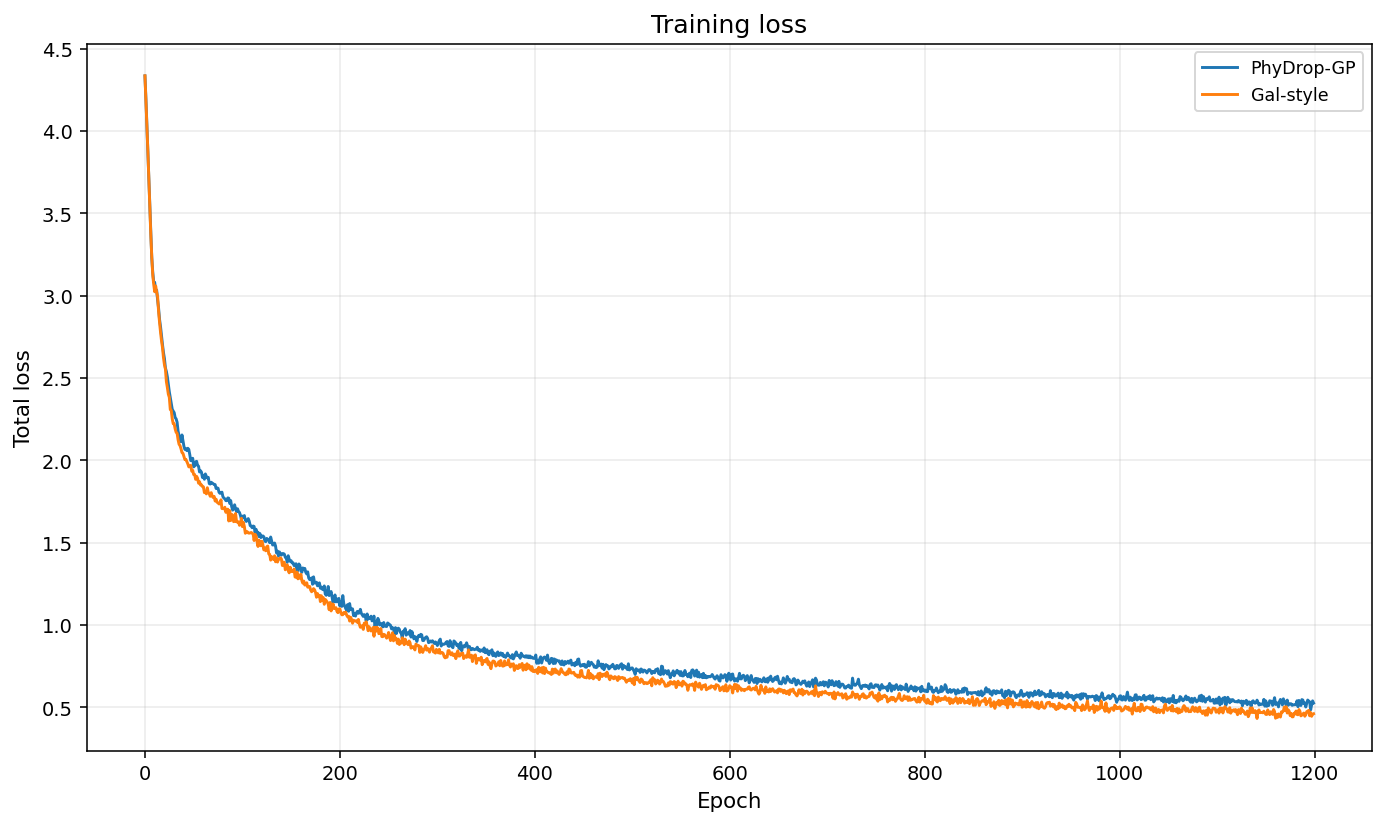

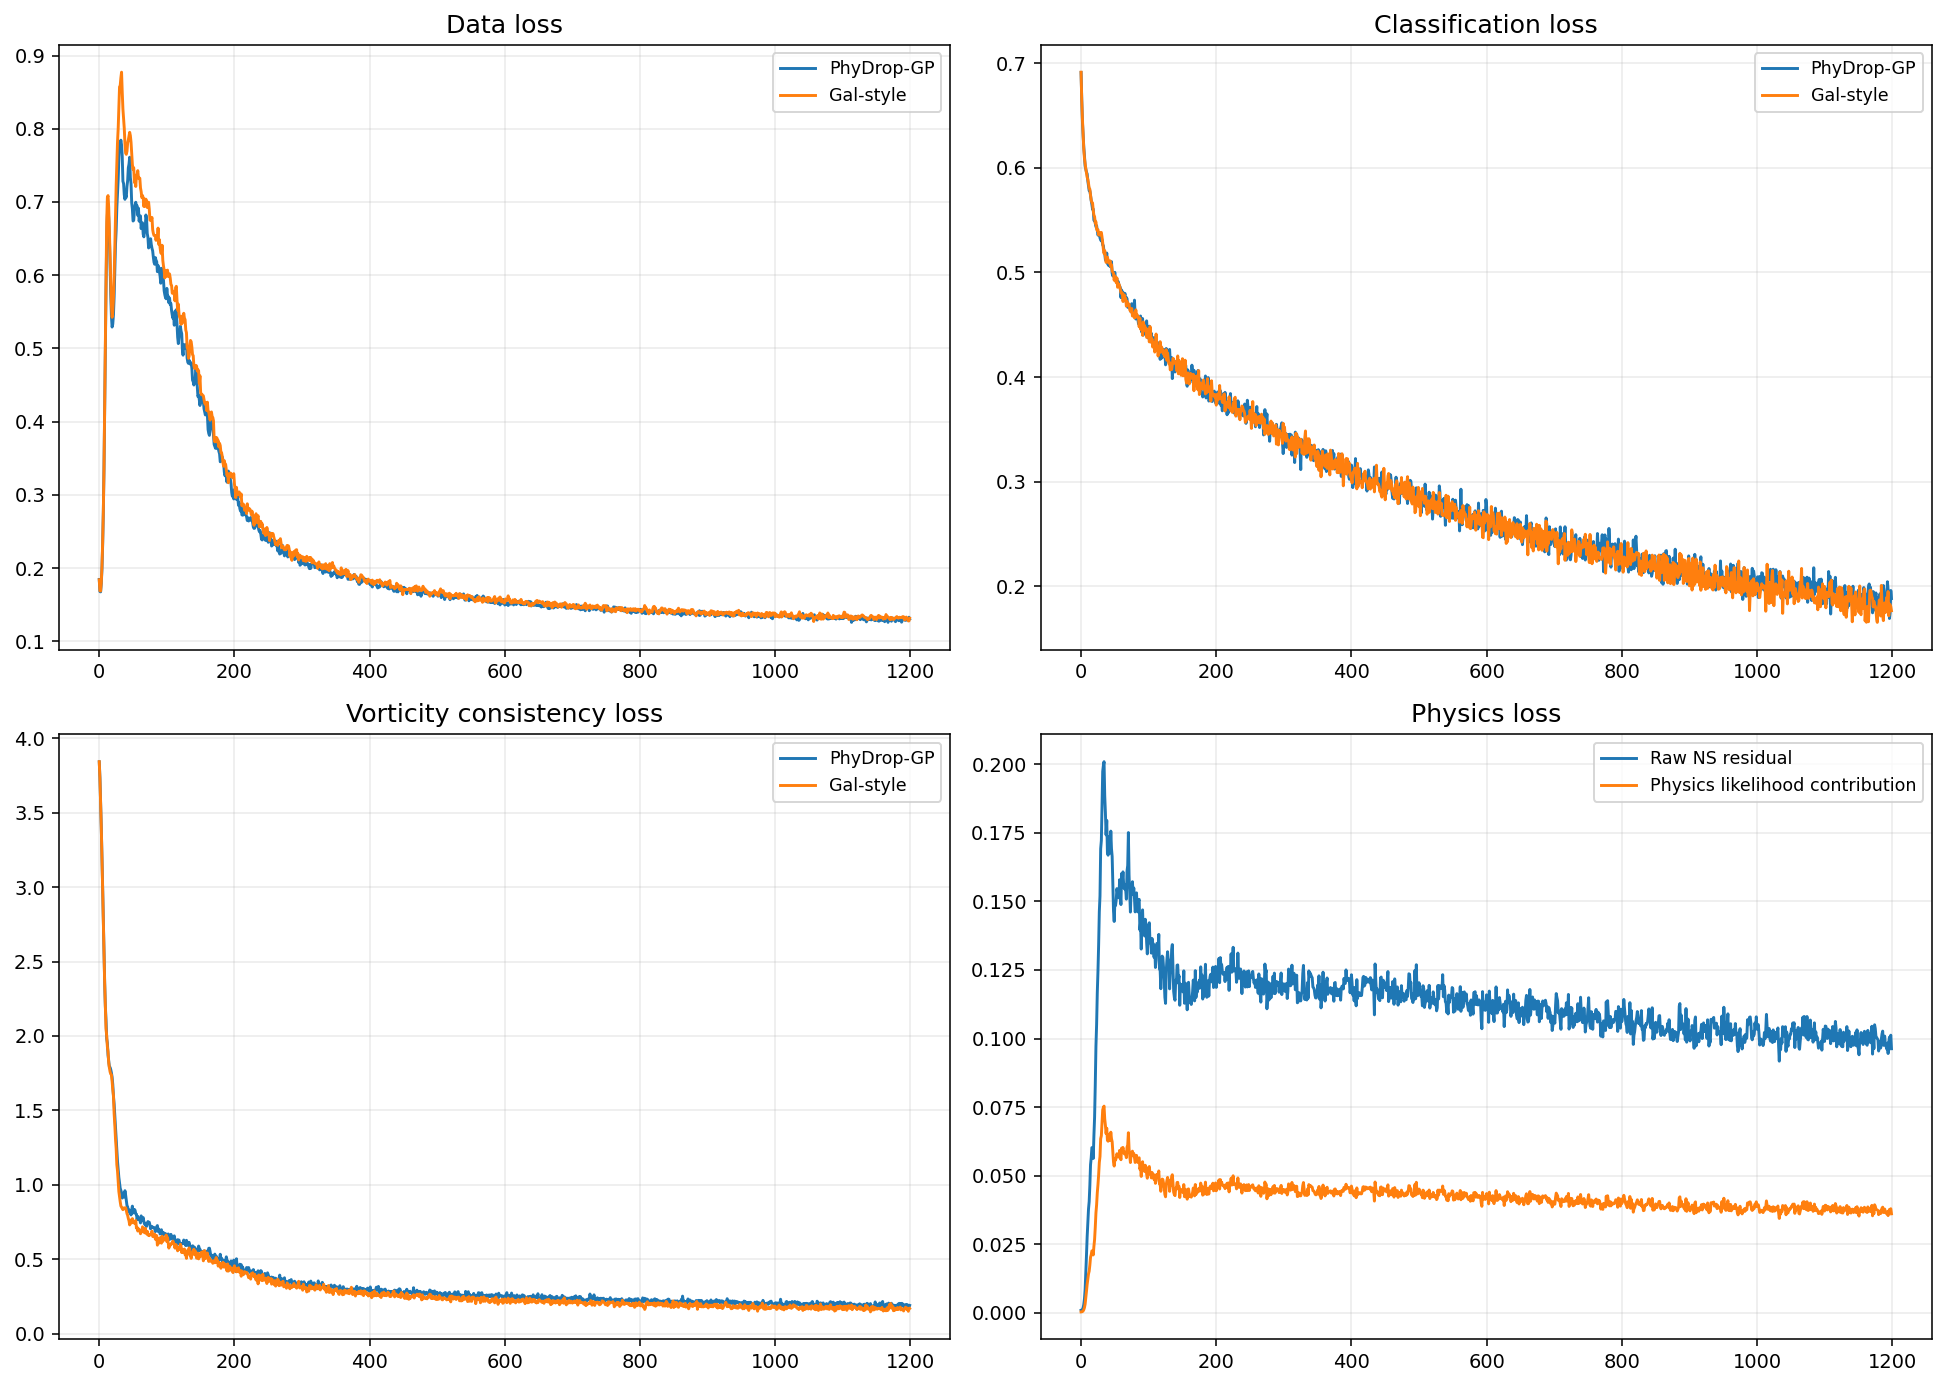

/tmp/ipykernel_8244/2322277137.py:2594: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


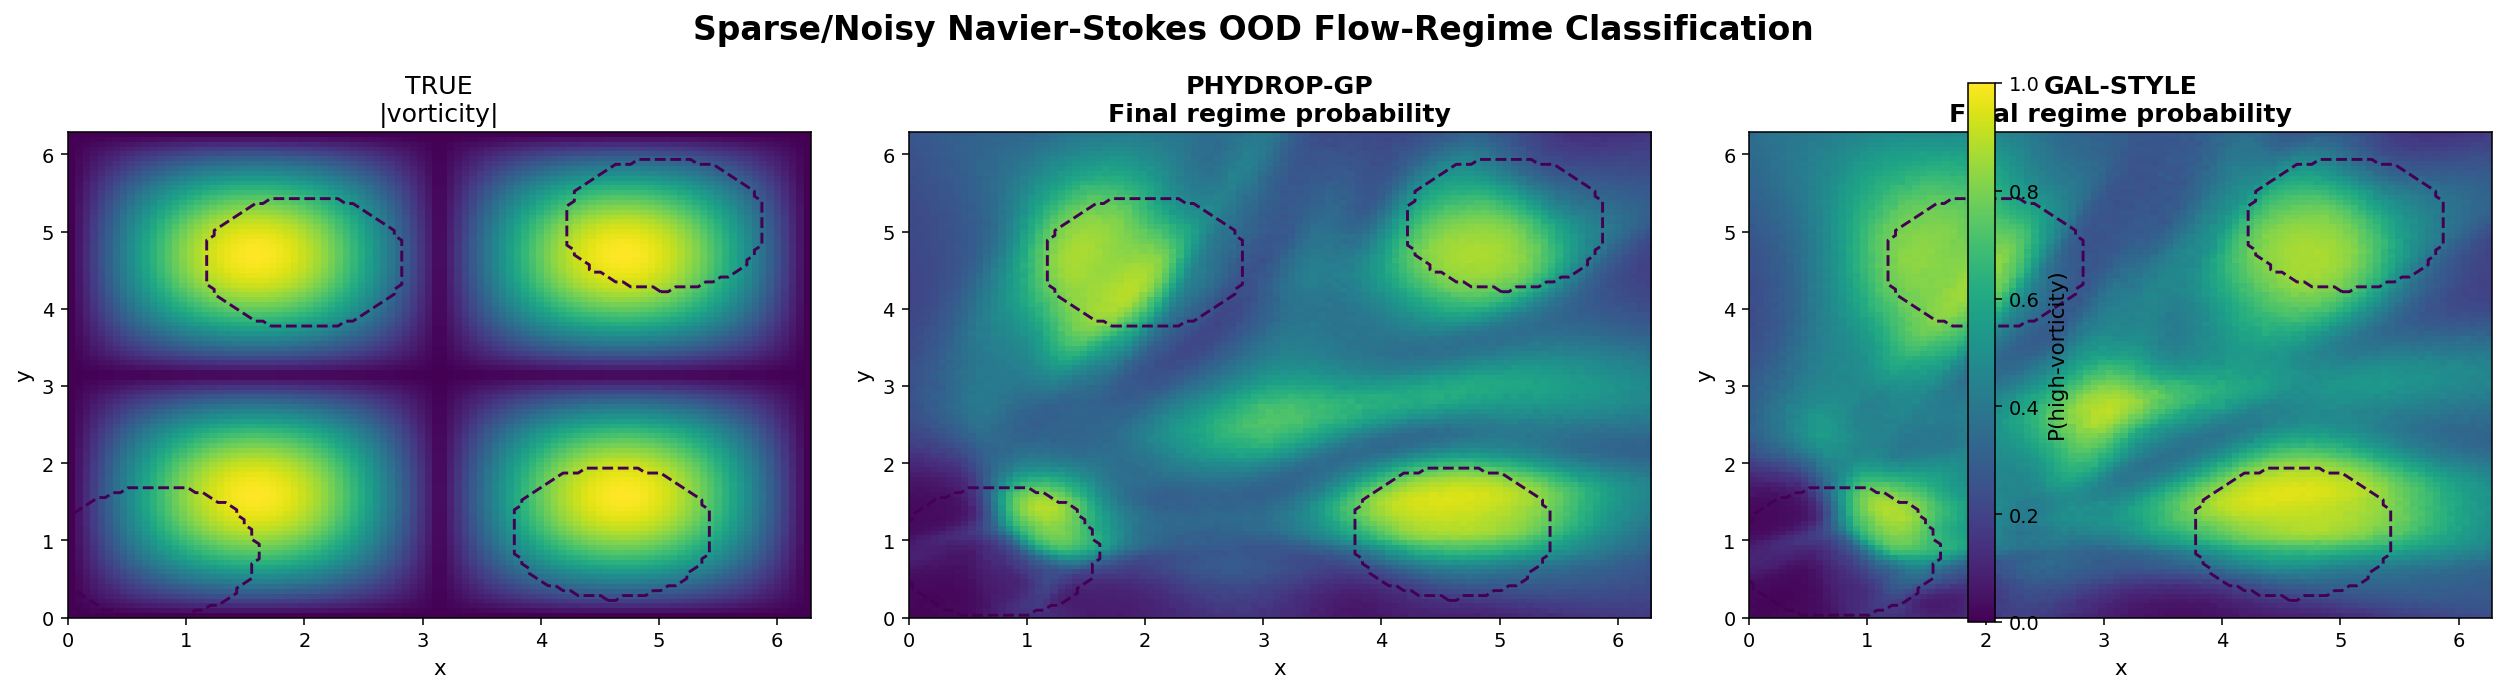

/tmp/ipykernel_8244/2322277137.py:2678: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


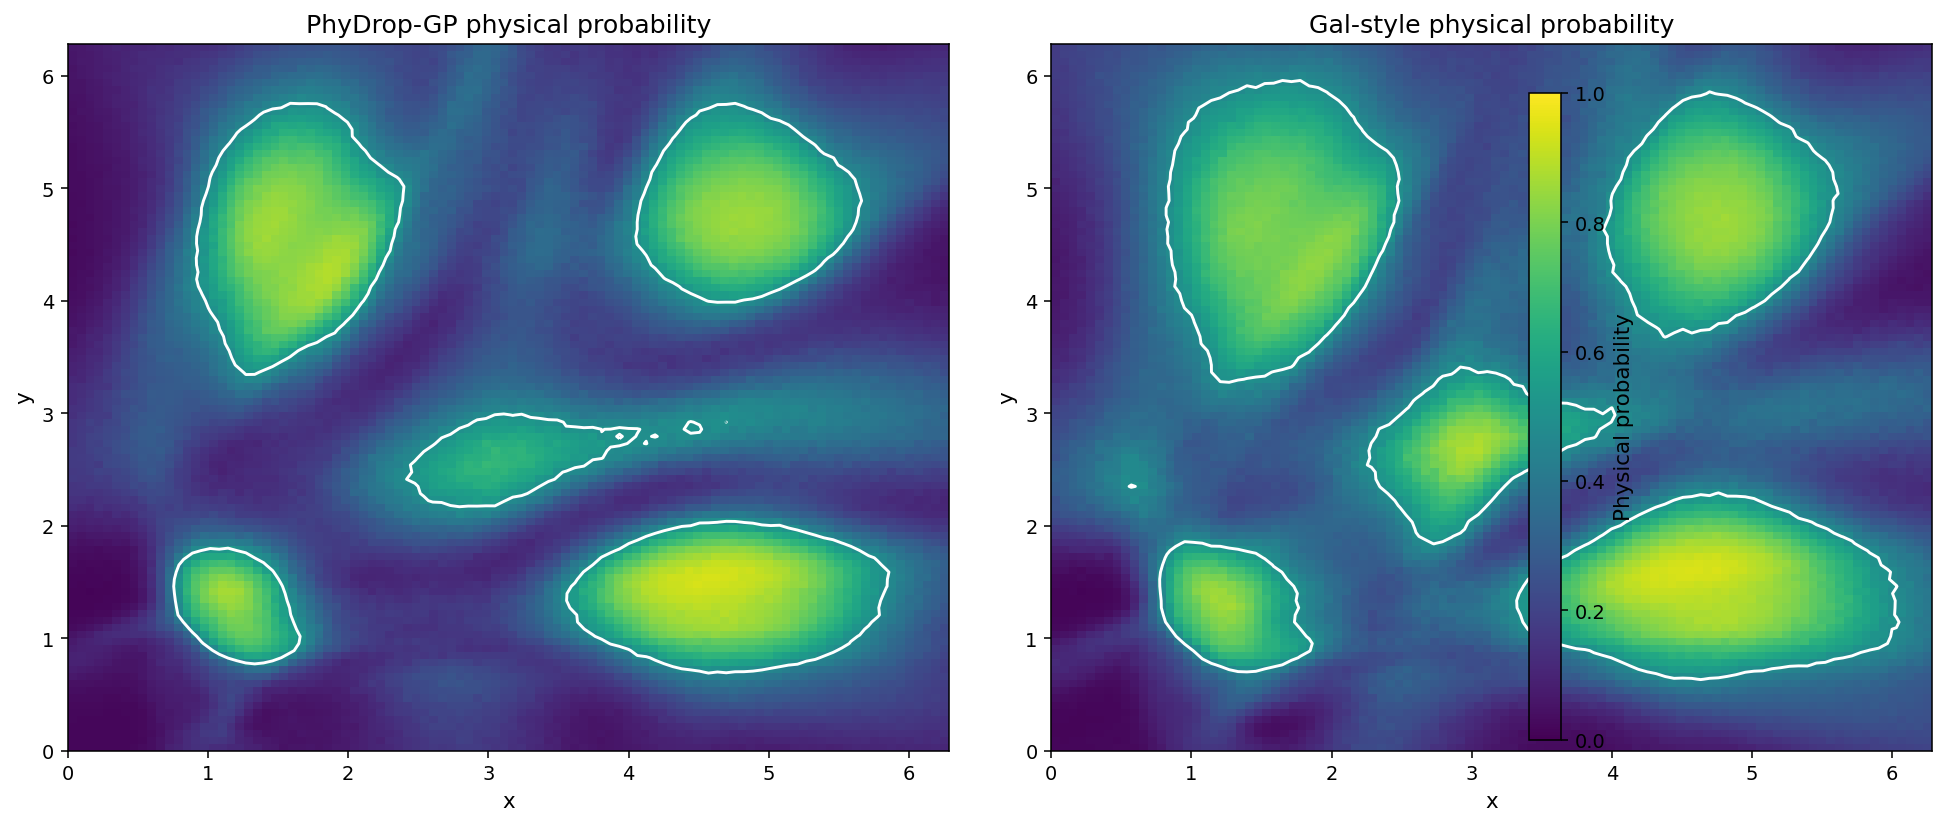

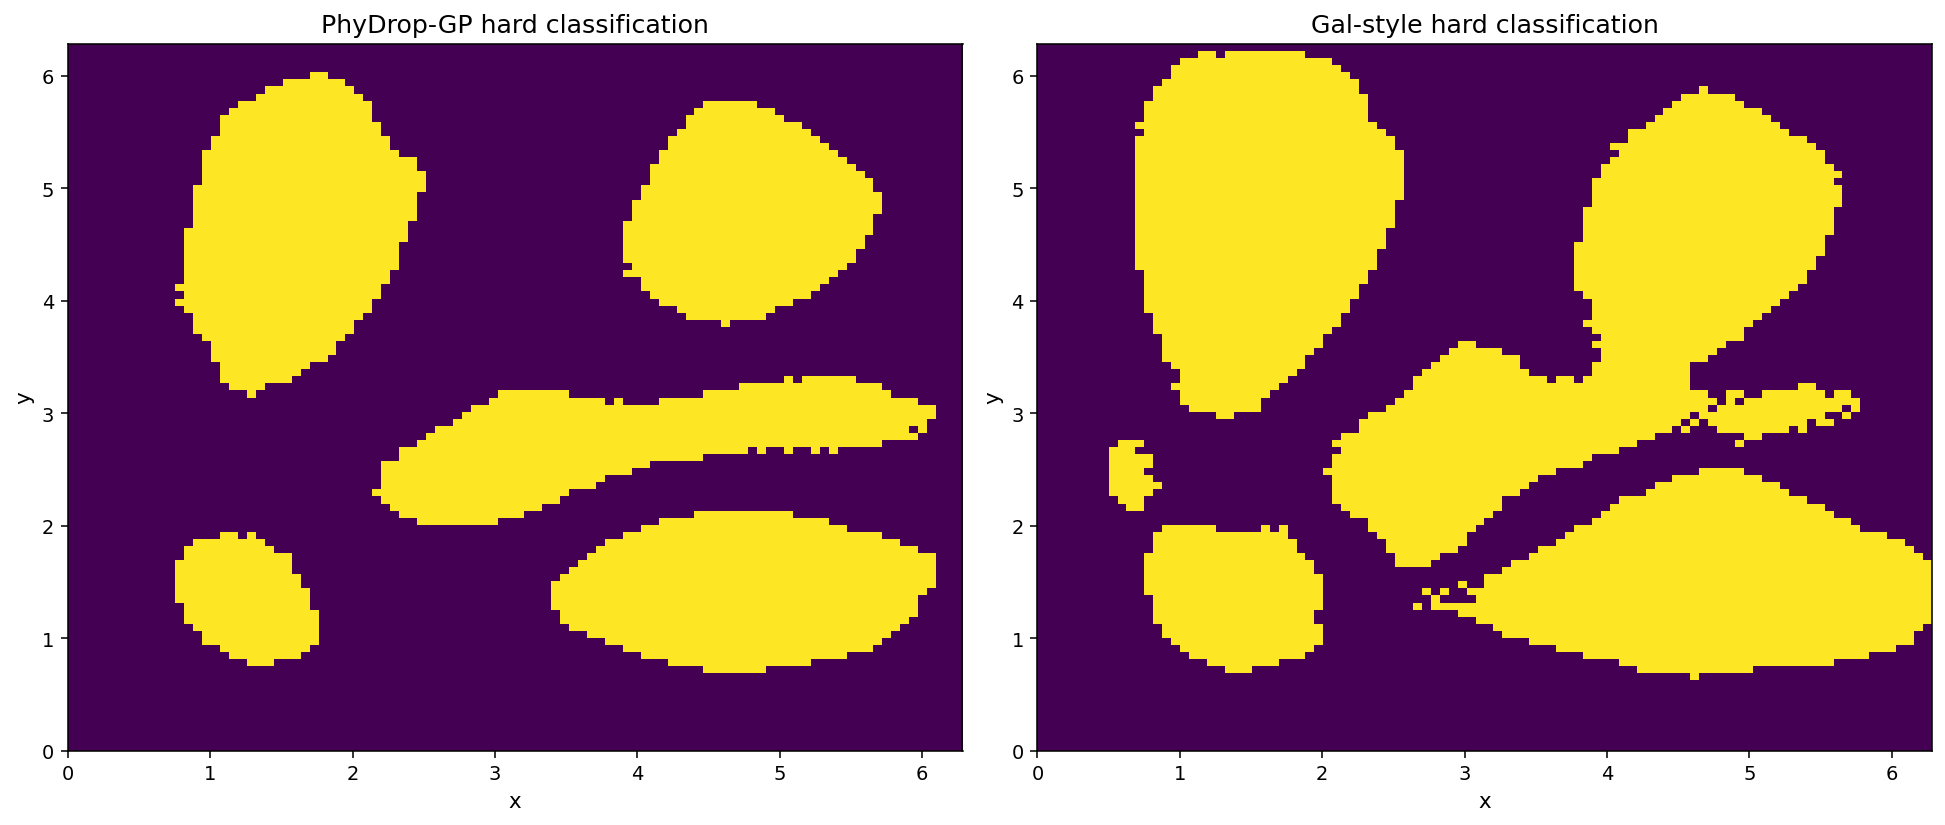

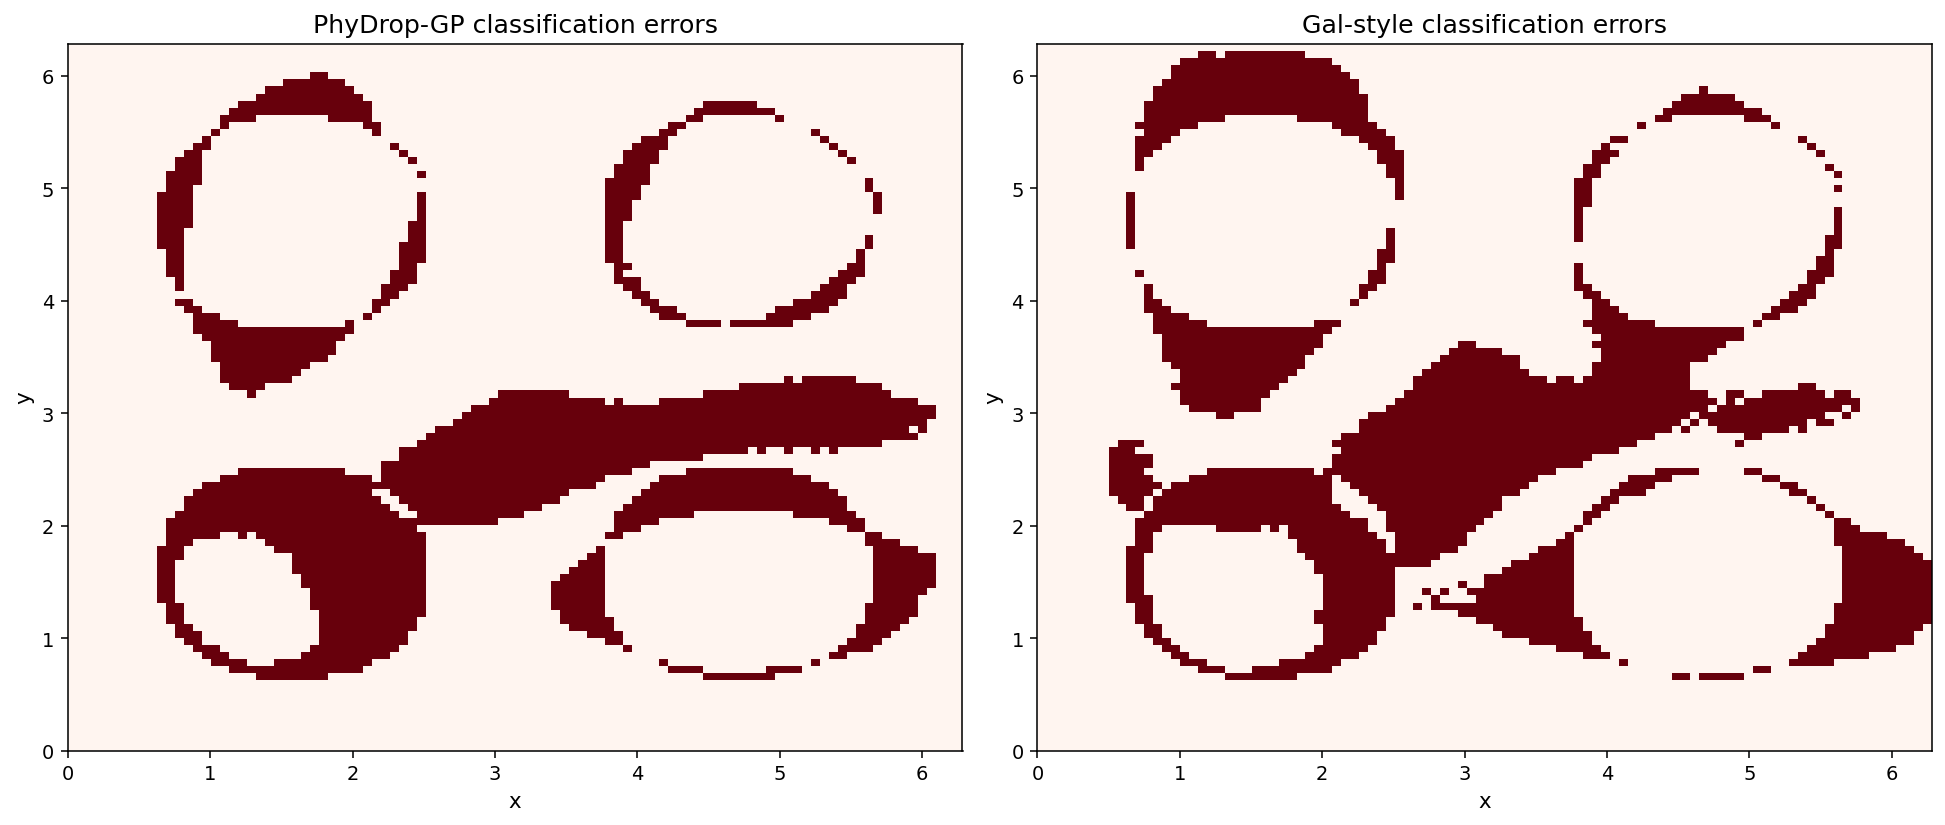

/tmp/ipykernel_8244/2322277137.py:2858: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


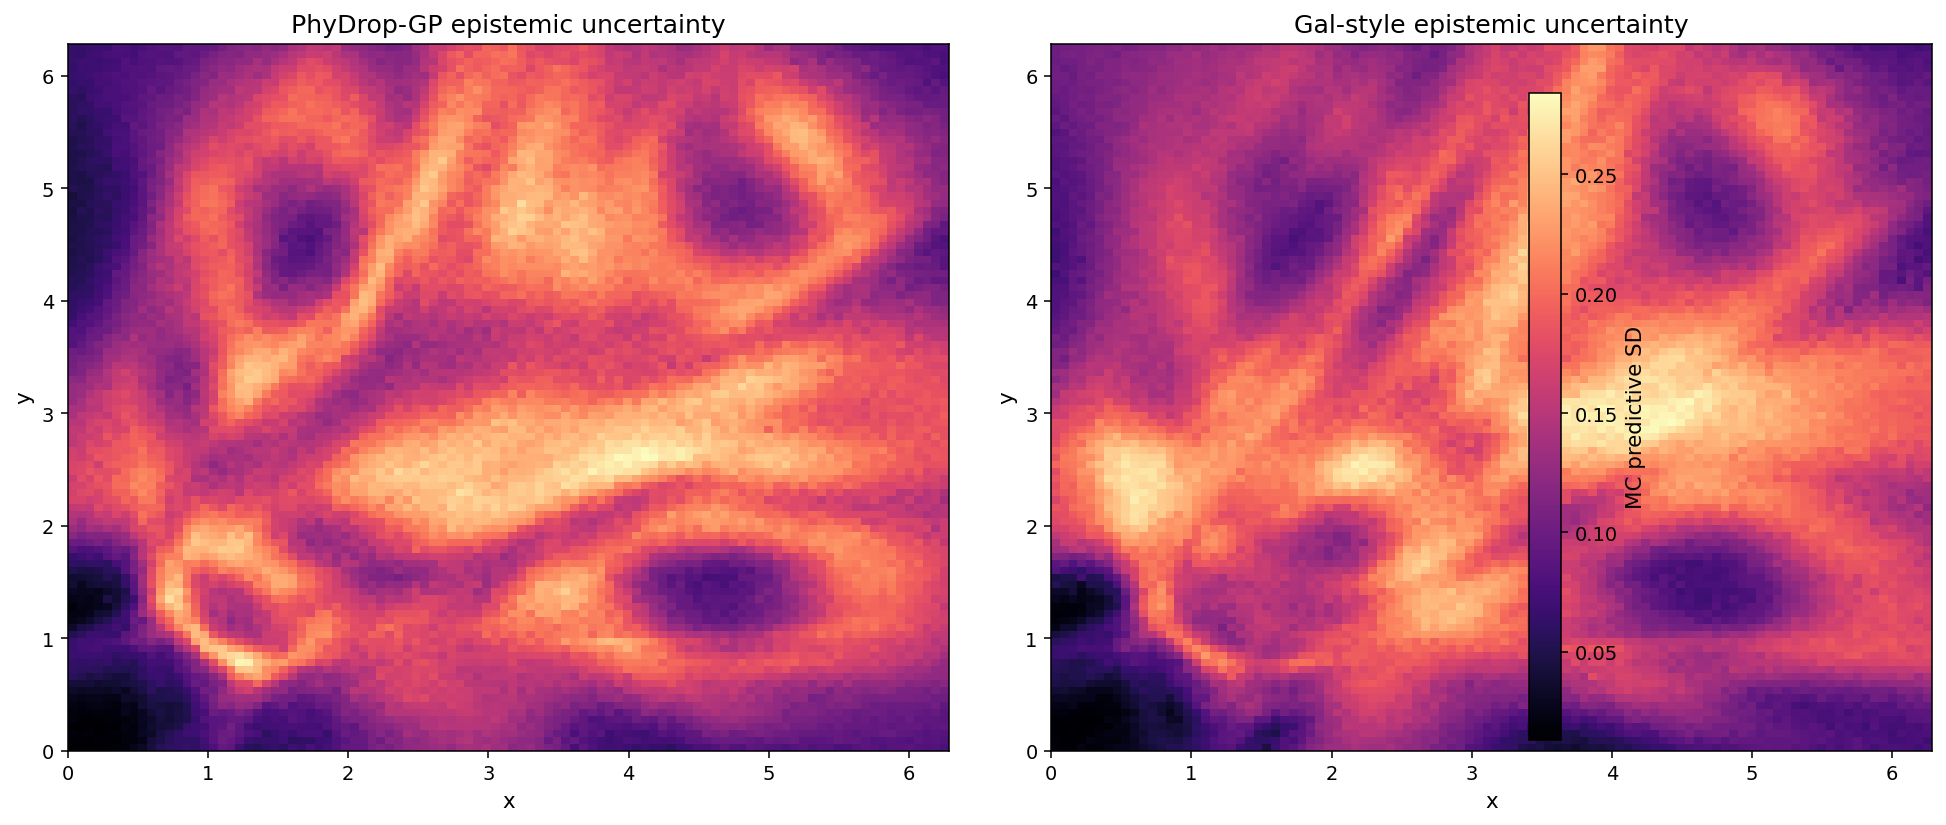

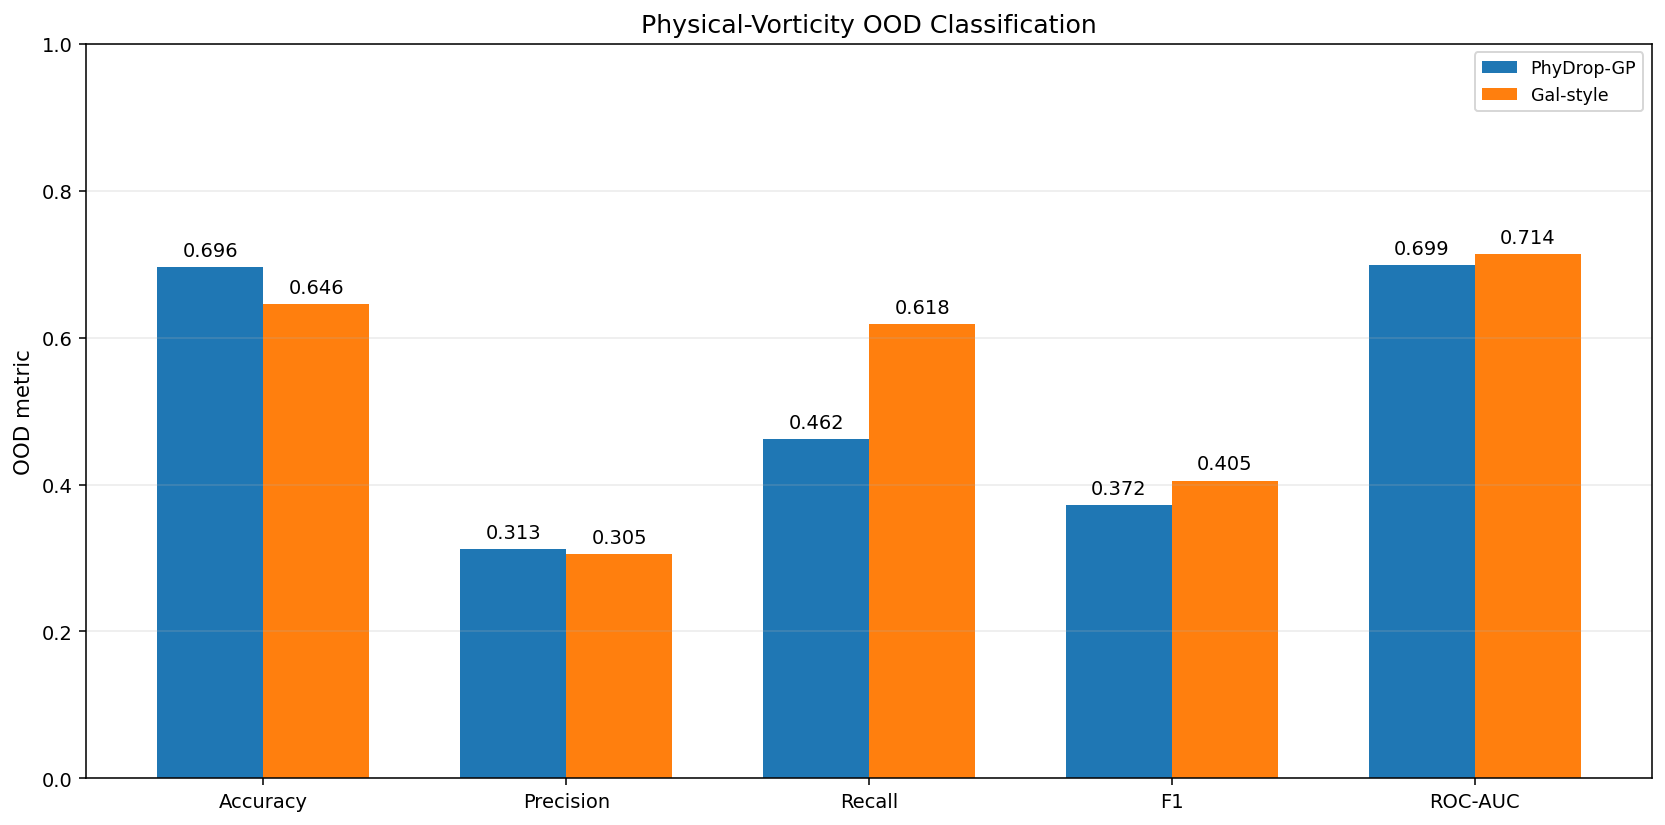

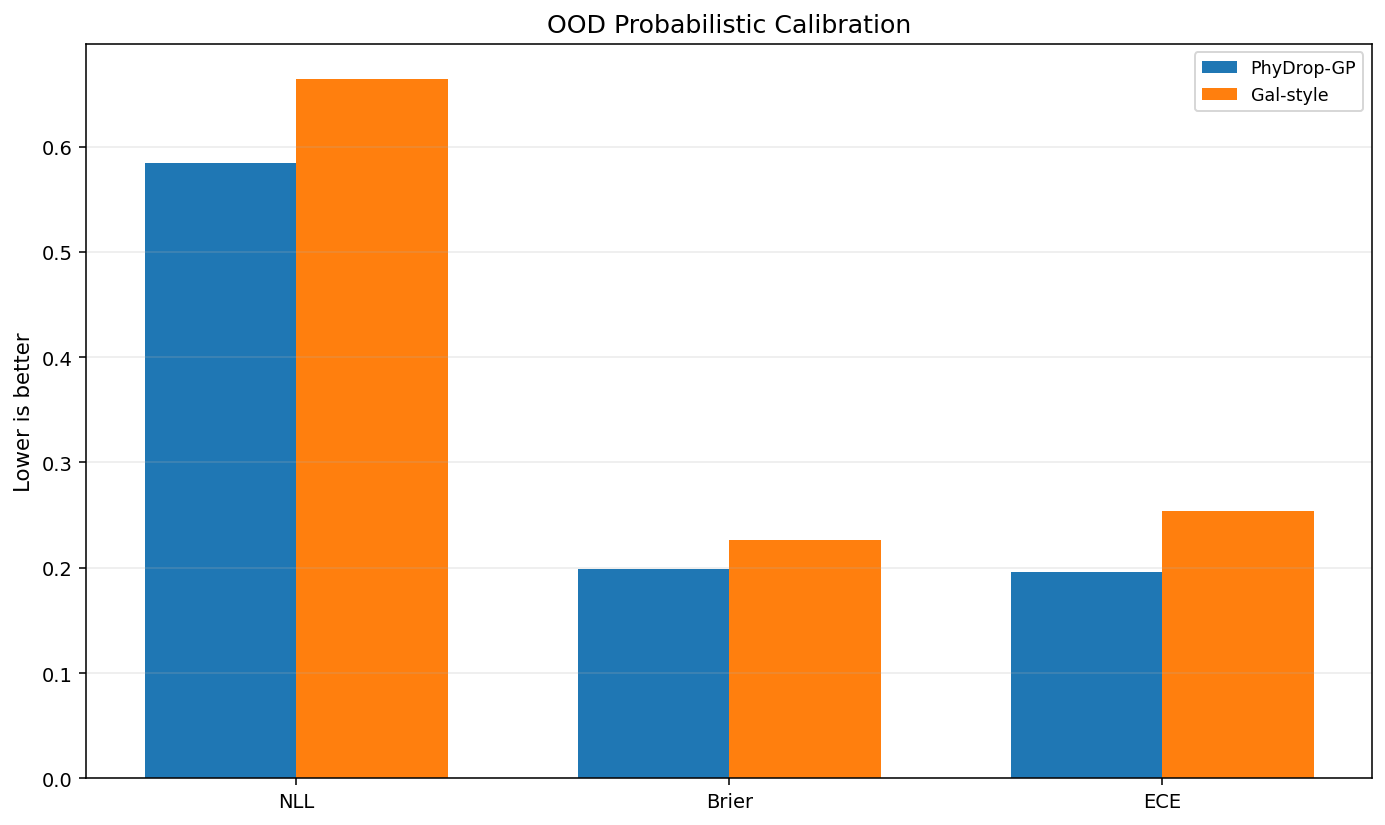

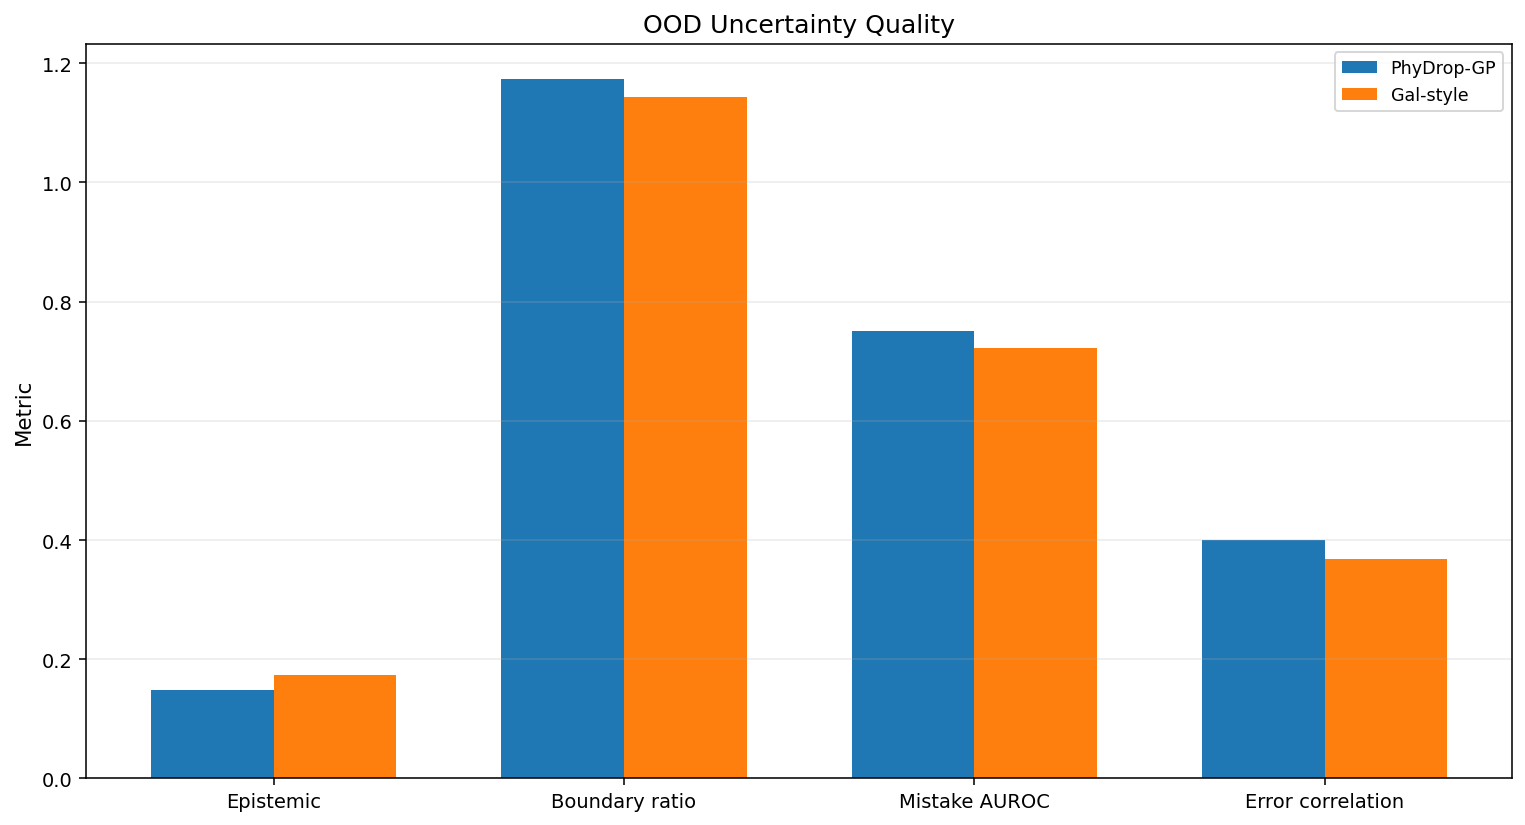

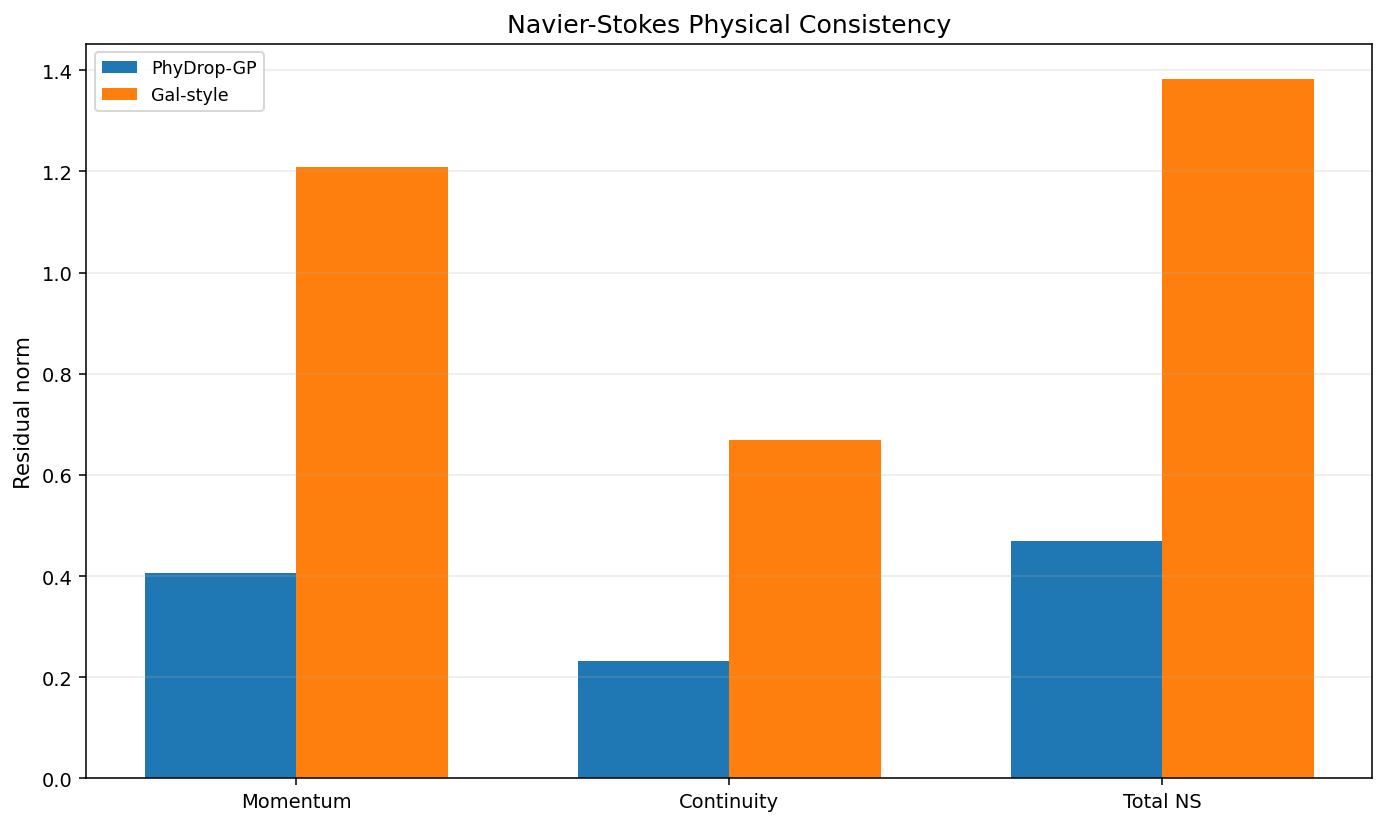

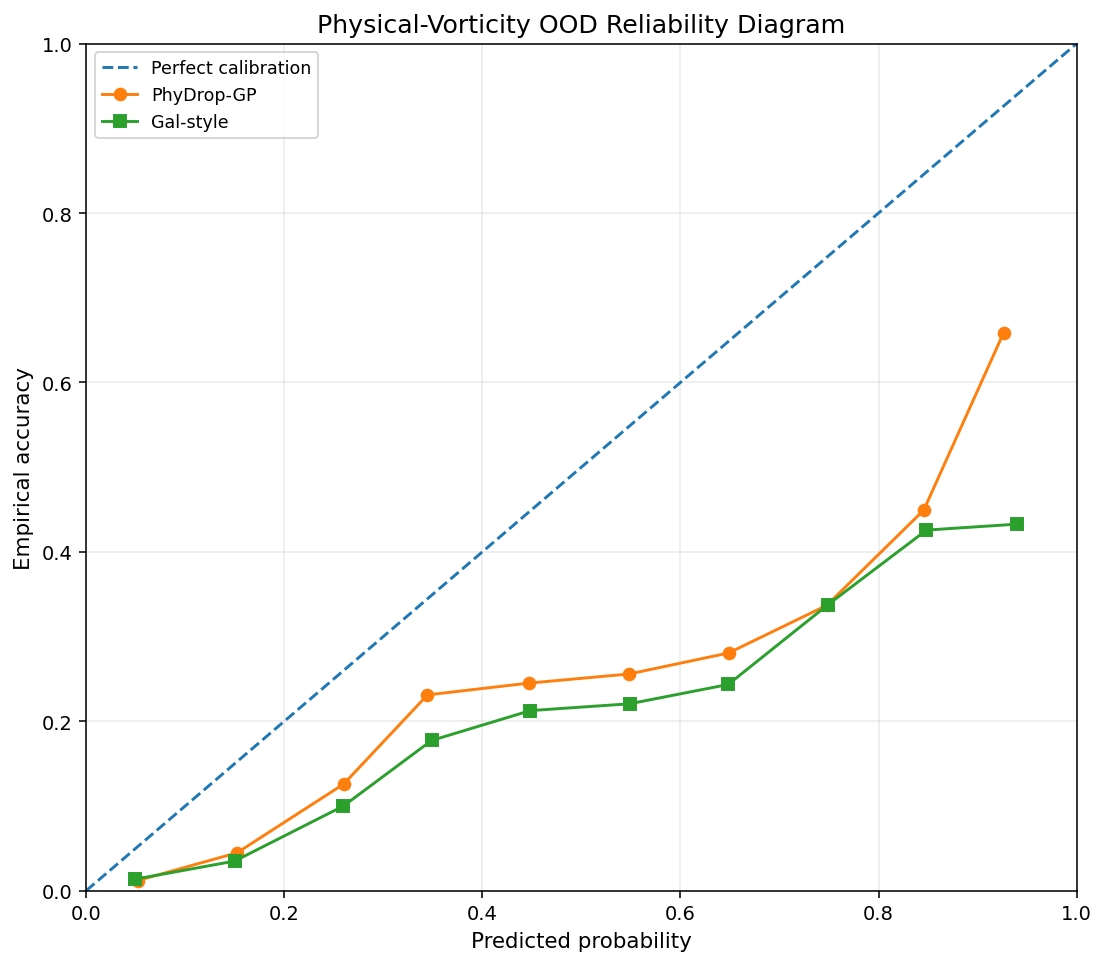

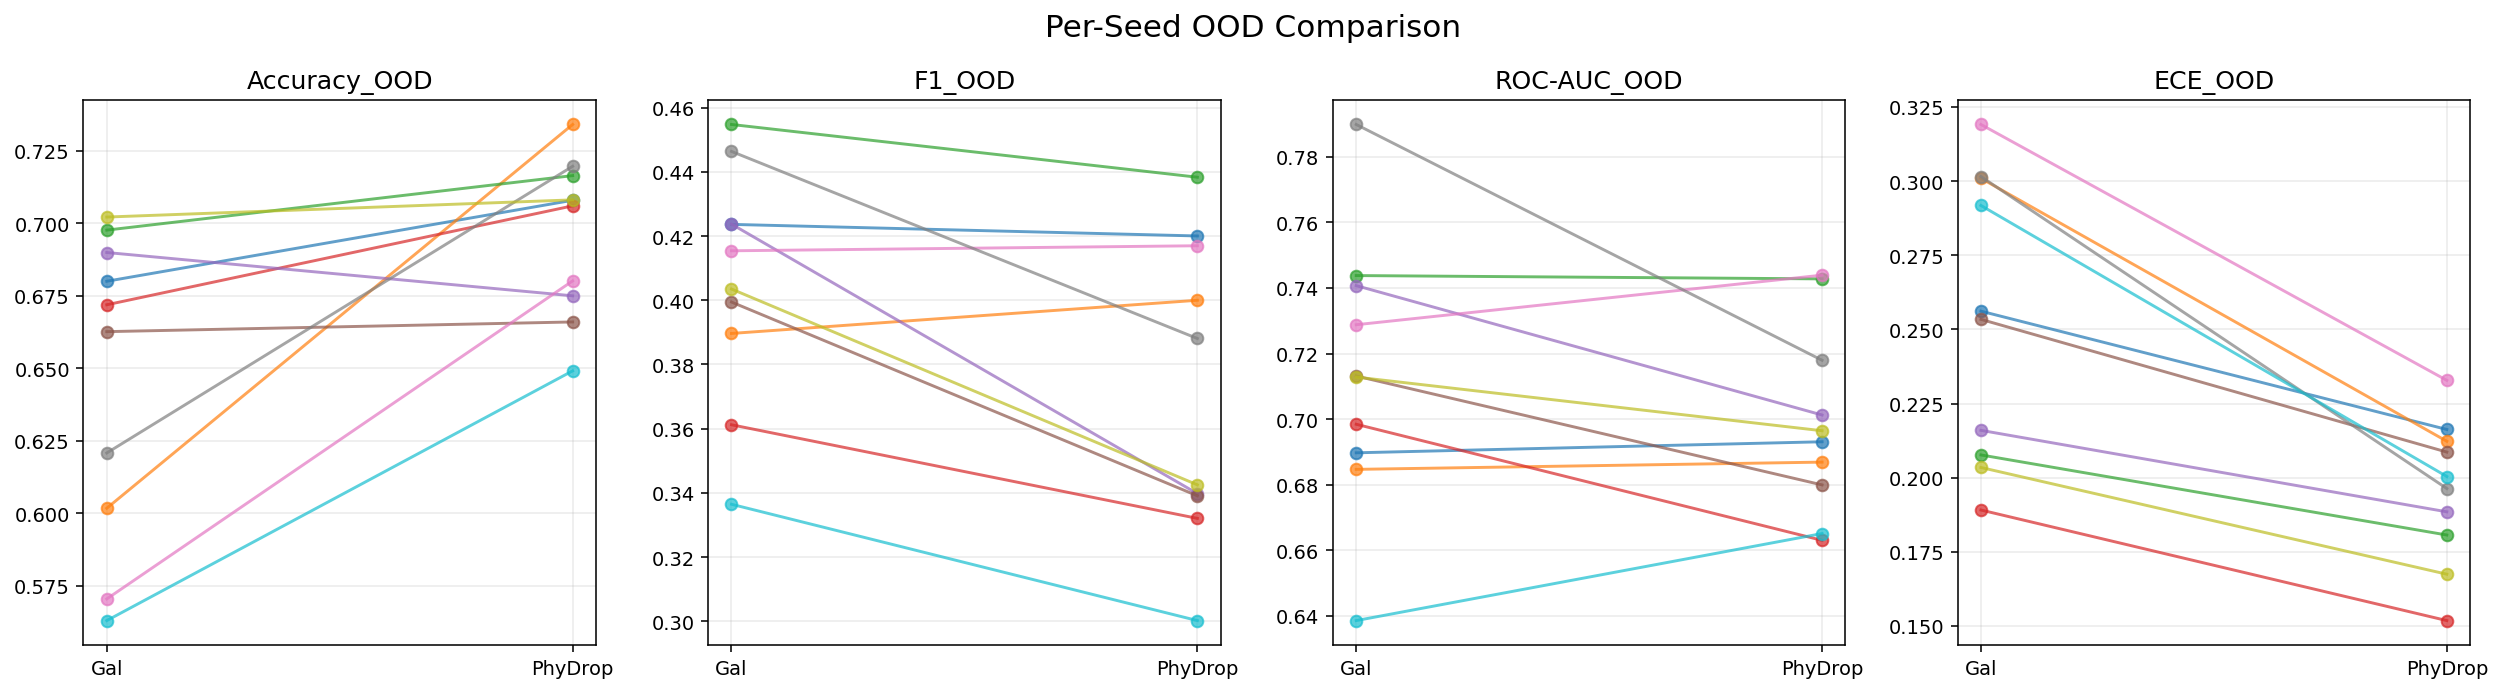

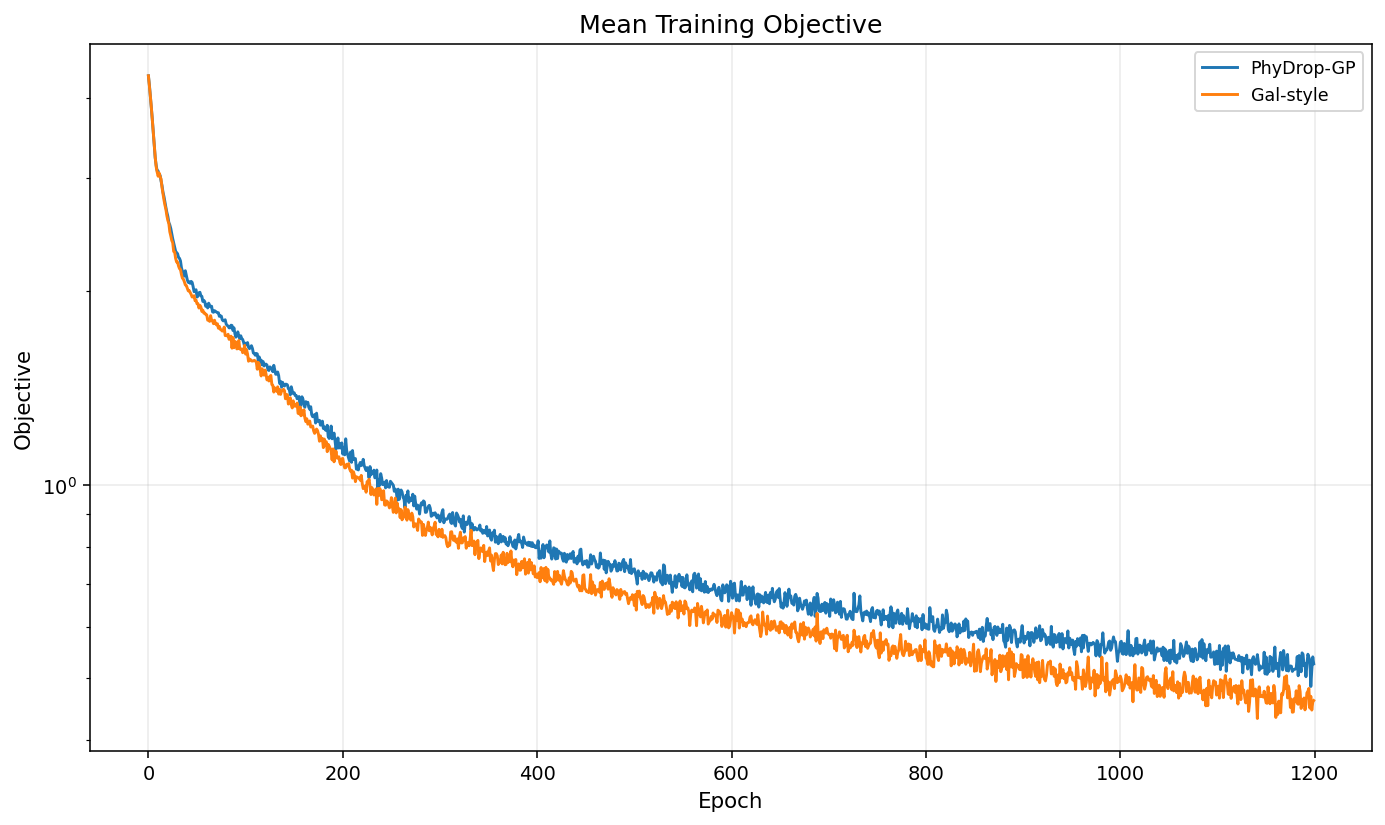

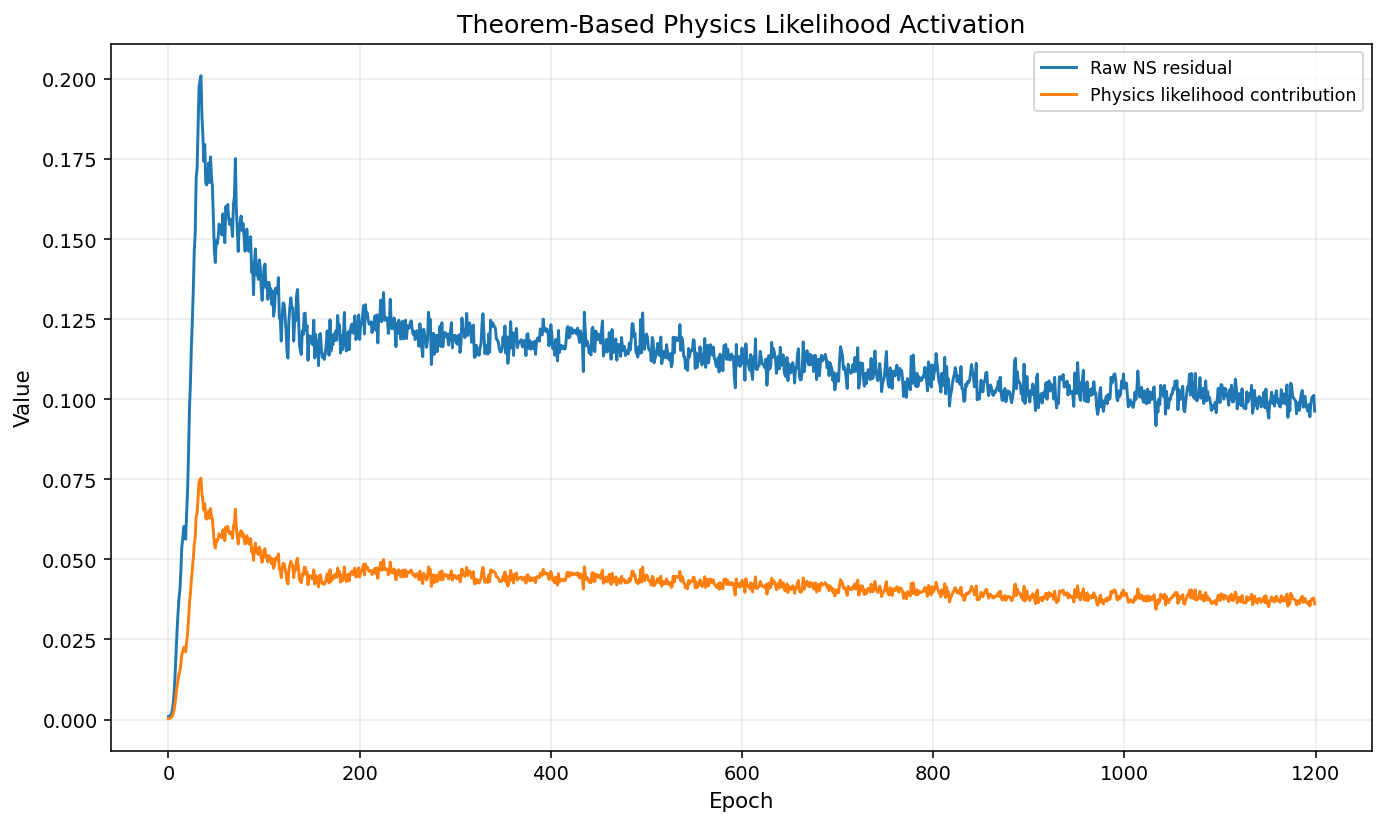


FINAL PHYSICAL-VORTICITY OOD REPORT

THEOREM PARAMETERS
tau_P = 0.250000
lambda_P = tau_P / (2 N_P)
tau_flow = 100.000000
tau_pressure = 156.250000

OOD DESIGN
Training time <= 0.65
Test time = 0.75
Sparse clustered flow observations
Classification labels restricted to training time
Evaluation on complete spatial test grid

FINAL PROBABILITY
gamma_vorticity = 0.75
vorticity logit scale = 5.00

OOD CLASSIFICATION
PhyDrop Accuracy = 0.6962
Gal Accuracy = 0.6460
PhyDrop F1 = 0.3717
Gal F1 = 0.4054
PhyDrop ROC-AUC = 0.6991
Gal ROC-AUC = 0.7141

CALIBRATION
PhyDrop NLL = 0.5839
Gal NLL = 0.6645
PhyDrop Brier = 0.1986
Gal Brier = 0.2267
PhyDrop ECE = 0.1955
Gal ECE = 0.2539

UNCERTAINTY
PhyDrop mistake AUROC = 0.7506
Gal mistake AUROC = 0.7227

PHYSICS
PhyDrop momentum residual = 0.4062
Gal momentum residual = 1.2091
PhyDrop continuity residual = 0.2313
Gal continuity residual = 0.6688
PhyDrop total NS residual = 0.4684
Gal total NS residual = 1.3832

OOD FLOW RECONSTRUCTION
PhyDrop u RMSE 

In [ ]:
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,log_loss,brier_score_loss
from scipy.stats import wilcoxon

SEEDS=[42,52,62,72,82,92,102,112,122,132]
EPOCHS=1200
LEARNING_RATE=1e-3
HIDDEN_DIM=96
DROPOUT=0.15
MC_SAMPLES=100
N_ECE_BINS=10
LAMBDA_CLASS=1.0
LAMBDA_VORT=0.90
LAMBDA_W=1e-6
VORTICITY_LOGIT_SCALE=5.0
GAMMA_VORT_FINAL=0.75
NU=0.01
RHO=1.0
FLOW_NOISE=0.10
PRESSURE_NOISE=0.08
OMEGA_LABEL_NOISE=0.10
LABEL_FLIP_RATE=0.05
TAU_FLOW=1.0/(FLOW_NOISE**2)
TAU_PRESSURE=1.0/(PRESSURE_NOISE**2)
TAU_P=0.25
X_MIN=0.0
X_MAX=2.0*np.pi
Y_MIN=0.0
Y_MAX=2.0*np.pi
T_MIN=0.0
T_MAX=1.0
T_TRAIN_MAX=0.65
T_TEST=0.75
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",DEVICE)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Ground-truth Navier-Stokes solution
def true_u(x,y,t):
    return -np.cos(x)*np.sin(y)*np.exp(-2.0*NU*t)

def true_v(x,y,t):
    return np.sin(x)*np.cos(y)*np.exp(-2.0*NU*t)

def true_p(x,y,t):
    return -0.25*(np.cos(2.0*x)+np.cos(2.0*y))*np.exp(-4.0*NU*t)

def true_vorticity(x,y,t):
    return 2.0*np.sin(x)*np.sin(y)*np.exp(-2.0*NU*t)

# Test grid and physical-vorticity OOD definition
N_GRID=100
x_grid=np.linspace(X_MIN,X_MAX,N_GRID)
y_grid=np.linspace(Y_MIN,Y_MAX,N_GRID)
XX,YY=np.meshgrid(x_grid,y_grid)
OMEGA_TRUE_TEST=true_vorticity(XX,YY,T_TEST)
VORTICITY_THRESHOLD=np.percentile(np.abs(OMEGA_TRUE_TEST),70)
Y_CLASS_TRUE=(np.abs(OMEGA_TRUE_TEST)>=VORTICITY_THRESHOLD).astype(int)

print()
print("PHYSICAL-VORTICITY OOD REGIME")
print(f"Training time <= {T_TRAIN_MAX:.2f}")
print(f"Test time      = {T_TEST:.2f}")
print(f"Vorticity threshold = {VORTICITY_THRESHOLD:.6f}")
print(f"True high-vorticity fraction = {Y_CLASS_TRUE.mean():.4f}")

TRAIN_CENTERS=np.array([
    [0.75,0.85],
    [4.60,1.10],
    [2.00,4.60],
    [5.05,5.10]
])
TRAIN_RADIUS=0.85

def spatial_training_mask(x,y):
    distance_sq=np.full(x.shape,np.inf,dtype=float)
    for center in TRAIN_CENTERS:
        current_distance=(x-center[0])**2+(y-center[1])**2
        distance_sq=np.minimum(distance_sq,current_distance)
    return distance_sq<=TRAIN_RADIUS**2

ID_MASK_GRID=spatial_training_mask(XX,YY)
OOD_MASK_GRID=~ID_MASK_GRID

print(f"ID spatial fraction  = {ID_MASK_GRID.mean():.4f}")
print(f"OOD spatial fraction = {OOD_MASK_GRID.mean():.4f}")

TRUE_BOUNDARY_DISTANCE=np.abs(np.abs(OMEGA_TRUE_TEST)-VORTICITY_THRESHOLD)
BOUNDARY_CUTOFF=np.percentile(TRUE_BOUNDARY_DISTANCE,20)
NEAR_BOUNDARY_MASK=TRUE_BOUNDARY_DISTANCE<=BOUNDARY_CUTOFF
FAR_BOUNDARY_MASK=~NEAR_BOUNDARY_MASK

# Sparse noisy observations, labels, and physics collocation
def generate_dataset(seed):
    set_seed(seed)
    N_OBS=300
    x_obs_locations=[]
    y_obs_locations=[]

    while len(x_obs_locations)<N_OBS:
        x_candidate=np.random.uniform(X_MIN,X_MAX)
        y_candidate=np.random.uniform(Y_MIN,Y_MAX)
        valid=spatial_training_mask(
            np.array([x_candidate]),
            np.array([y_candidate])
        )[0]
        if valid:
            x_obs_locations.append(x_candidate)
            y_obs_locations.append(y_candidate)

    x_obs_locations=np.asarray(x_obs_locations,dtype=float)
    y_obs_locations=np.asarray(y_obs_locations,dtype=float)
    t_obs=np.random.uniform(T_MIN,T_TRAIN_MAX,N_OBS)

    u_true_obs=true_u(x_obs_locations,y_obs_locations,t_obs)
    v_true_obs=true_v(x_obs_locations,y_obs_locations,t_obs)
    p_true_obs=true_p(x_obs_locations,y_obs_locations,t_obs)

    u_obs=u_true_obs+np.random.normal(0.0,FLOW_NOISE,N_OBS)
    v_obs=v_true_obs+np.random.normal(0.0,FLOW_NOISE,N_OBS)
    p_obs=p_true_obs+np.random.normal(0.0,PRESSURE_NOISE,N_OBS)

    N_CLASS_LABELS=140
    class_x_locations=[]
    class_y_locations=[]
    class_t_locations=[]

    while len(class_x_locations)<N_CLASS_LABELS:
        x_candidate=np.random.uniform(X_MIN,X_MAX)
        y_candidate=np.random.uniform(Y_MIN,Y_MAX)
        t_candidate=np.random.uniform(T_MIN,T_TRAIN_MAX)

        valid=spatial_training_mask(
            np.array([x_candidate]),
            np.array([y_candidate])
        )[0]

        if valid:
            class_x_locations.append(x_candidate)
            class_y_locations.append(y_candidate)
            class_t_locations.append(t_candidate)

    class_x_locations=np.asarray(class_x_locations,dtype=float)
    class_y_locations=np.asarray(class_y_locations,dtype=float)
    class_t_locations=np.asarray(class_t_locations,dtype=float)

    omega_label_true=true_vorticity(
        class_x_locations,
        class_y_locations,
        class_t_locations
    )

    omega_label_noisy=(
        omega_label_true+
        np.random.normal(
            0.0,
            OMEGA_LABEL_NOISE,
            N_CLASS_LABELS
        )
    )

    class_labels=(
        np.abs(omega_label_noisy)>=VORTICITY_THRESHOLD
    ).astype(int)

    flip_mask=np.random.rand(N_CLASS_LABELS)<LABEL_FLIP_RATE
    class_labels[flip_mask]=1-class_labels[flip_mask]

    CLASS_BOUNDARY_BAND=0.18

    keep_mask=(
        np.abs(
            np.abs(omega_label_noisy)-
            VORTICITY_THRESHOLD
        )>
        CLASS_BOUNDARY_BAND
    )

    x_class=class_x_locations[keep_mask]
    y_class=class_y_locations[keep_mask]
    t_class=class_t_locations[keep_mask]
    class_labels=class_labels[keep_mask]

    X_class=np.column_stack([
        x_class,
        y_class,
        t_class
    ])

    Y_class=class_labels.reshape(-1,1)

    N_COLL=1000

    X_coll=np.column_stack([
        np.random.uniform(X_MIN,X_MAX,N_COLL),
        np.random.uniform(Y_MIN,Y_MAX,N_COLL),
        np.random.uniform(T_MIN,T_MAX,N_COLL)
    ])

    X_obs_t=torch.tensor(
        np.column_stack([
            x_obs_locations,
            y_obs_locations,
            t_obs
        ]),
        dtype=torch.float32,
        device=DEVICE
    )

    Y_flow_t=torch.tensor(
        np.column_stack([
            u_obs,
            v_obs,
            p_obs
        ]),
        dtype=torch.float32,
        device=DEVICE
    )

    X_class_t=torch.tensor(
        X_class,
        dtype=torch.float32,
        device=DEVICE
    )

    Y_class_t=torch.tensor(
        Y_class,
        dtype=torch.float32,
        device=DEVICE
    )

    X_coll_t=torch.tensor(
        X_coll,
        dtype=torch.float32,
        device=DEVICE
    )

    return {
        "X_obs_t":X_obs_t,
        "Y_flow_t":Y_flow_t,
        "X_class_t":X_class_t,
        "Y_class_t":Y_class_t,
        "X_coll_t":X_coll_t,
        "N_COLL":N_COLL,
        "N_CLASS":len(X_class)
    }

# Neural network with shared flow features and classification head
class NSPhysicsDropoutClassifier(nn.Module):
    def __init__(self,hidden_dim=96,dropout=0.15):
        super().__init__()

        self.feature_net=nn.Sequential(
            nn.Linear(3,hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout)
        )

        self.flow_head=nn.Linear(hidden_dim,3)
        self.class_head=nn.Linear(hidden_dim,1)

    def forward(self,x):
        features=self.feature_net(x)
        flow=self.flow_head(features)
        class_logits=self.class_head(features)
        return flow,class_logits

def derivatives(
    output,
    X,
    create_graph=True,
    retain_graph=True
):
    return torch.autograd.grad(
        outputs=output,
        inputs=X,
        grad_outputs=torch.ones_like(output),
        create_graph=create_graph,
        retain_graph=retain_graph,
        allow_unused=False
    )[0]

# Navier-Stokes physics residual
def navier_stokes_residual(model,X):
    if not X.requires_grad:
        X=X.clone().detach().requires_grad_(True)

    flow,_=model(X)

    u=flow[:,0:1]
    v=flow[:,1:2]
    p=flow[:,2:3]

    grad_u=derivatives(
        u,
        X,
        create_graph=True,
        retain_graph=True
    )

    grad_v=derivatives(
        v,
        X,
        create_graph=True,
        retain_graph=True
    )

    grad_p=derivatives(
        p,
        X,
        create_graph=True,
        retain_graph=True
    )

    u_x=grad_u[:,0:1]
    u_y=grad_u[:,1:2]
    u_t=grad_u[:,2:3]

    v_x=grad_v[:,0:1]
    v_y=grad_v[:,1:2]
    v_t=grad_v[:,2:3]

    p_x=grad_p[:,0:1]
    p_y=grad_p[:,1:2]

    grad_ux=derivatives(
        u_x,
        X,
        create_graph=True,
        retain_graph=True
    )

    grad_uy=derivatives(
        u_y,
        X,
        create_graph=True,
        retain_graph=True
    )

    grad_vx=derivatives(
        v_x,
        X,
        create_graph=True,
        retain_graph=True
    )

    grad_vy=derivatives(
        v_y,
        X,
        create_graph=True,
        retain_graph=True
    )

    u_xx=grad_ux[:,0:1]
    u_yy=grad_uy[:,1:2]
    v_xx=grad_vx[:,0:1]
    v_yy=grad_vy[:,1:2]

    momentum_x=(
        u_t+
        u*u_x+
        v*u_y+
        (1.0/RHO)*p_x-
        NU*(u_xx+u_yy)
    )

    momentum_y=(
        v_t+
        u*v_x+
        v*v_y+
        (1.0/RHO)*p_y-
        NU*(v_xx+v_yy)
    )

    continuity=u_x+v_y

    return momentum_x,momentum_y,continuity

def vorticity_from_flow(
    flow,
    X,
    create_graph=True
):
    if not X.requires_grad:
        X=X.clone().detach().requires_grad_(True)

    u=flow[:,0:1]
    v=flow[:,1:2]

    grad_u=derivatives(
        u,
        X,
        create_graph=create_graph,
        retain_graph=True
    )

    grad_v=derivatives(
        v,
        X,
        create_graph=create_graph,
        retain_graph=True
    )

    u_y=grad_u[:,1:2]
    v_x=grad_v[:,0:1]

    omega=v_x-u_y

    return omega

# Vorticity-based physical consistency
def physical_vorticity_probability(omega):
    physical_logit=(
        VORTICITY_LOGIT_SCALE*
        (
            torch.abs(omega)-
            VORTICITY_THRESHOLD
        )
    )

    return torch.sigmoid(
        physical_logit
    )

def vorticity_consistency_loss(
    flow,
    X_class,
    Y_class
):
    omega=vorticity_from_flow(
        flow,
        X_class,
        create_graph=True
    )

    physical_probability=(
        physical_vorticity_probability(
            omega
        )
    )

    loss=nn.functional.binary_cross_entropy(
        physical_probability,
        Y_class
    )

    return loss,physical_probability,omega

def weight_regularisation(model):
    reg=torch.zeros(
        1,
        device=DEVICE
    )

    for parameter in model.parameters():
        reg=reg+torch.sum(
            parameter**2
        )

    return reg

def theorem_lambda_P(N_P):
    return TAU_P/(2.0*N_P)

# Physics-informed NN objective
def compute_phydrop_loss(
    model,
    dataset,
    X_physics
):
    flow_obs,_=model(
        dataset["X_obs_t"]
    )

    data_loss=torch.mean(
        (
            flow_obs-
            dataset["Y_flow_t"]
        )**2
    )

    X_class=(
        dataset["X_class_t"]
        .clone()
        .detach()
        .requires_grad_(True)
    )

    Y_class=dataset["Y_class_t"]

    flow_class,class_logits=model(
        X_class
    )

    class_probability=torch.sigmoid(
        class_logits
    )

    classification_loss=(
        nn.functional.binary_cross_entropy(
            class_probability,
            Y_class
        )
    )

    (
        vort_loss,
        physical_probability,
        omega_pred
    )=vorticity_consistency_loss(
        flow_class,
        X_class,
        Y_class
    )

    (
        momentum_x,
        momentum_y,
        continuity
    )=navier_stokes_residual(
        model,
        X_physics
    )

    N_P=X_physics.shape[0]

    lambda_P=theorem_lambda_P(
        N_P
    )

    physics_squared_sum=(
        torch.sum(momentum_x**2)+
        torch.sum(momentum_y**2)+
        torch.sum(continuity**2)
    )

    physics_nll=(
        lambda_P*
        physics_squared_sum
    )

    raw_physics_loss=(
        physics_squared_sum/
        (3.0*N_P)
    )

    weight_loss=weight_regularisation(
        model
    )

    weighted_weight_loss=(
        LAMBDA_W*
        weight_loss
    )

    total_loss=(
        data_loss+
        LAMBDA_CLASS*classification_loss+
        LAMBDA_VORT*vort_loss+
        physics_nll+
        weighted_weight_loss
    )

    return {
        "total":total_loss,
        "data":data_loss,
        "classification":classification_loss,
        "vorticity":vort_loss,
        "physics_raw":raw_physics_loss,
        "physics_nll":physics_nll,
        "lambda_P":lambda_P
    }

# Gal-style objective
def compute_gal_loss(
    model,
    dataset
):
    flow_obs,_=model(
        dataset["X_obs_t"]
    )

    data_loss=torch.mean(
        (
            flow_obs-
            dataset["Y_flow_t"]
        )**2
    )

    X_class=(
        dataset["X_class_t"]
        .clone()
        .detach()
        .requires_grad_(True)
    )

    Y_class=dataset["Y_class_t"]

    flow_class,class_logits=model(
        X_class
    )

    class_probability=torch.sigmoid(
        class_logits
    )

    classification_loss=(
        nn.functional.binary_cross_entropy(
            class_probability,
            Y_class
        )
    )

    (
        vort_loss,
        physical_probability,
        omega_pred
    )=vorticity_consistency_loss(
        flow_class,
        X_class,
        Y_class
    )

    weight_loss=weight_regularisation(
        model
    )

    weighted_weight_loss=(
        LAMBDA_W*
        weight_loss
    )

    total_loss=(
        data_loss+
        LAMBDA_CLASS*classification_loss+
        LAMBDA_VORT*vort_loss+
        weighted_weight_loss
    )

    return {
        "total":total_loss,
        "data":data_loss,
        "classification":classification_loss,
        "vorticity":vort_loss
    }

PHYSICS_BATCH=300

def get_physics_batch(
    X_coll_t
):
    N=X_coll_t.shape[0]
    batch_size=min(
        PHYSICS_BATCH,
        N
    )

    indices=torch.randint(
        low=0,
        high=N,
        size=(batch_size,),
        device=DEVICE
    )

    X_batch=(
        X_coll_t[
            indices
        ]
        .clone()
        .detach()
        .requires_grad_(True)
    )

    return X_batch

def train_model(
    model,
    dataset,
    use_physics,
    seed
):
    set_seed(seed)

    optimizer=optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history={
        "total":[],
        "data":[],
        "classification":[],
        "vorticity":[],
        "physics_raw":[],
        "physics_nll":[],
        "lambda_P":[]
    }

    for epoch in range(
        EPOCHS
    ):
        model.train()

        optimizer.zero_grad(
            set_to_none=True
        )

        if use_physics:
            X_physics=get_physics_batch(
                dataset["X_coll_t"]
            )

            losses=compute_phydrop_loss(
                model,
                dataset,
                X_physics
            )
        else:
            losses=compute_gal_loss(
                model,
                dataset
            )

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        history["total"].append(
            float(
                losses["total"]
                .detach()
                .cpu()
            )
        )

        history["data"].append(
            float(
                losses["data"]
                .detach()
                .cpu()
            )
        )

        history["classification"].append(
            float(
                losses["classification"]
                .detach()
                .cpu()
            )
        )

        history["vorticity"].append(
            float(
                losses["vorticity"]
                .detach()
                .cpu()
            )
        )

        if use_physics:
            history["physics_raw"].append(
                float(
                    losses["physics_raw"]
                    .detach()
                    .cpu()
                )
            )

            history["physics_nll"].append(
                float(
                    losses["physics_nll"]
                    .detach()
                    .cpu()
                )
            )

            history["lambda_P"].append(
                float(
                    losses["lambda_P"]
                )
            )
        else:
            history["physics_raw"].append(0.0)
            history["physics_nll"].append(0.0)
            history["lambda_P"].append(0.0)

        if (
            epoch%200==0
            or
            epoch==EPOCHS-1
        ):
            if use_physics:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Total={history['total'][-1]:.6f} | "
                    f"Data={history['data'][-1]:.6f} | "
                    f"Class={history['classification'][-1]:.6f} | "
                    f"Vort={history['vorticity'][-1]:.6f} | "
                    f"Phys={history['physics_nll'][-1]:.6f}"
                )
            else:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Total={history['total'][-1]:.6f} | "
                    f"Data={history['data'][-1]:.6f} | "
                    f"Class={history['classification'][-1]:.6f} | "
                    f"Vort={history['vorticity'][-1]:.6f}"
                )

    return history

# Monte Carlo dropout posterior predictive approximation
def mc_dropout_predict(
    model,
    X_eval_t
):
    model.train()

    head_samples=[]
    physical_samples=[]
    final_samples=[]
    u_samples=[]
    v_samples=[]
    p_samples=[]

    for _ in range(
        MC_SAMPLES
    ):
        X_mc=(
            X_eval_t
            .clone()
            .detach()
            .requires_grad_(True)
        )

        flow_pred,logits=model(
            X_mc
        )

        p_head=torch.sigmoid(
            logits
        )

        omega_pred=vorticity_from_flow(
            flow_pred,
            X_mc,
            create_graph=False
        )

        p_vort=physical_vorticity_probability(
            omega_pred
        )

        p_final=(
            (1.0-GAMMA_VORT_FINAL)*
            p_head+
            GAMMA_VORT_FINAL*
            p_vort
        )

        head_samples.append(
            p_head
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

        physical_samples.append(
            p_vort
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

        final_samples.append(
            p_final
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

        u_samples.append(
            flow_pred[:,0]
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

        v_samples.append(
            flow_pred[:,1]
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

        p_samples.append(
            flow_pred[:,2]
            .detach()
            .cpu()
            .numpy()
            .reshape(
                N_GRID,
                N_GRID
            )
        )

    return {
        "head":np.asarray(head_samples),
        "physical":np.asarray(physical_samples),
        "final":np.asarray(final_samples),
        "u":np.asarray(u_samples),
        "v":np.asarray(v_samples),
        "p":np.asarray(p_samples)
    }

def uncertainty_statistics(
    probability_samples
):
    mean_probability=np.mean(
        probability_samples,
        axis=0
    )

    epistemic_std=np.std(
        probability_samples,
        axis=0
    )

    p=np.clip(
        mean_probability,
        1e-8,
        1.0-1e-8
    )

    predictive_entropy=(
        -p*np.log(p)-
        (1.0-p)*np.log(1.0-p)
    )

    q=np.clip(
        probability_samples,
        1e-8,
        1.0-1e-8
    )

    sample_entropy=(
        -q*np.log(q)-
        (1.0-q)*np.log(1.0-q)
    )

    expected_entropy=np.mean(
        sample_entropy,
        axis=0
    )

    mutual_information=(
        predictive_entropy-
        expected_entropy
    )

    predicted_class=(
        mean_probability>=0.5
    ).astype(int)

    return {
        "mean":mean_probability,
        "std":epistemic_std,
        "entropy":predictive_entropy,
        "mi":mutual_information,
        "class":predicted_class
    }

def calculate_ece(
    y_true,
    probabilities,
    n_bins=10
):
    edges=np.linspace(
        0.0,
        1.0,
        n_bins+1
    )

    ece=0.0
    records=[]

    for i in range(
        n_bins
    ):
        lower=edges[i]
        upper=edges[i+1]

        if i==n_bins-1:
            mask=(
                (probabilities>=lower)&
                (probabilities<=upper)
            )
        else:
            mask=(
                (probabilities>=lower)&
                (probabilities<upper)
            )

        count=np.sum(
            mask
        )

        if count==0:
            continue

        confidence=np.mean(
            probabilities[mask]
        )

        empirical_accuracy=np.mean(
            y_true[mask]
        )

        gap=abs(
            confidence-
            empirical_accuracy
        )

        ece+=(
            count/
            len(probabilities)*
            gap
        )

        records.append({
            "bin":i+1,
            "confidence":confidence,
            "accuracy":empirical_accuracy,
            "count":count
        })

    return (
        float(ece),
        pd.DataFrame(records)
    )

# Physics residual evaluation
def physics_diagnostic(
    model,
    X_eval,
    batch_size=250
):
    model.eval()

    ru_all=[]
    rv_all=[]
    c_all=[]

    for start in range(
        0,
        len(X_eval),
        batch_size
    ):
        end=min(
            start+batch_size,
            len(X_eval)
        )

        X_batch=torch.tensor(
            X_eval[start:end],
            dtype=torch.float32,
            device=DEVICE,
            requires_grad=True
        )

        with torch.enable_grad():
            ru,rv,c=navier_stokes_residual(
                model,
                X_batch
            )

        ru_all.append(
            ru.detach()
            .cpu()
            .numpy()
        )

        rv_all.append(
            rv.detach()
            .cpu()
            .numpy()
        )

        c_all.append(
            c.detach()
            .cpu()
            .numpy()
        )

    ru=np.concatenate(
        ru_all,
        axis=0
    ).ravel()

    rv=np.concatenate(
        rv_all,
        axis=0
    ).ravel()

    c=np.concatenate(
        c_all,
        axis=0
    ).ravel()

    momentum=np.sqrt(
        np.mean(
            ru**2+
            rv**2
        )
    )

    continuity=np.sqrt(
        np.mean(
            c**2
        )
    )

    total=np.sqrt(
        momentum**2+
        continuity**2
    )

    return {
        "momentum":momentum,
        "continuity":continuity,
        "total":total
    }

def safe_corr(x,y):
    if (
        np.std(x)<1e-12
        or
        np.std(y)<1e-12
    ):
        return np.nan

    return np.corrcoef(
        x,
        y
    )[0,1]

def safe_error_auc(
    errors,
    uncertainty
):
    if len(
        np.unique(errors)
    )<2:
        return np.nan

    return roc_auc_score(
        errors,
        uncertainty
    )

# Single-seed experiment
def run_seed(seed):
    print()
    print(f"RUNNING SEED {seed}")

    dataset=generate_dataset(
        seed
    )

    print(
        "Classification training points:",
        dataset["N_CLASS"]
    )

    set_seed(
        seed
    )

    base_model=(
        NSPhysicsDropoutClassifier(
            hidden_dim=HIDDEN_DIM,
            dropout=DROPOUT
        )
        .to(DEVICE)
    )

    phy_model=(
        NSPhysicsDropoutClassifier(
            hidden_dim=HIDDEN_DIM,
            dropout=DROPOUT
        )
        .to(DEVICE)
    )

    gal_model=(
        NSPhysicsDropoutClassifier(
            hidden_dim=HIDDEN_DIM,
            dropout=DROPOUT
        )
        .to(DEVICE)
    )

    initial_state=copy.deepcopy(
        base_model.state_dict()
    )

    phy_model.load_state_dict(
        copy.deepcopy(
            initial_state
        )
    )

    gal_model.load_state_dict(
        copy.deepcopy(
            initial_state
        )
    )

    print()
    print("TRAINING PHYDROP-GP")

    phy_history=train_model(
        phy_model,
        dataset,
        use_physics=True,
        seed=seed*1000+1
    )

    print()
    print("TRAINING GAL-STYLE")

    gal_history=train_model(
        gal_model,
        dataset,
        use_physics=False,
        seed=seed*1000+2
    )

    X_eval=np.column_stack([
        XX.ravel(),
        YY.ravel(),
        np.full(
            XX.size,
            T_TEST
        )
    ])

    X_eval_t=torch.tensor(
        X_eval,
        dtype=torch.float32,
        device=DEVICE
    )

    set_seed(
        seed*1000+10
    )

    phy_samples=mc_dropout_predict(
        phy_model,
        X_eval_t
    )

    set_seed(
        seed*1000+20
    )

    gal_samples=mc_dropout_predict(
        gal_model,
        X_eval_t
    )

    phy_stats=uncertainty_statistics(
        phy_samples["final"]
    )

    gal_stats=uncertainty_statistics(
        gal_samples["final"]
    )

    y_true=Y_CLASS_TRUE.ravel()

    phy_probability=(
        phy_stats["mean"]
        .ravel()
    )

    gal_probability=(
        gal_stats["mean"]
        .ravel()
    )

    phy_prediction=(
        phy_stats["class"]
        .ravel()
    )

    gal_prediction=(
        gal_stats["class"]
        .ravel()
    )

    phy_uncertainty=(
        phy_stats["std"]
        .ravel()
    )

    gal_uncertainty=(
        gal_stats["std"]
        .ravel()
    )

    id_mask=ID_MASK_GRID.ravel()
    ood_mask=OOD_MASK_GRID.ravel()

    def evaluate_subset(
        mask,
        split_name
    ):
        yt=y_true[mask]
        pp=phy_probability[mask]
        gp=gal_probability[mask]
        py=phy_prediction[mask]
        gy=gal_prediction[mask]
        pu=phy_uncertainty[mask]
        gu=gal_uncertainty[mask]

        phy_error=(
            py!=yt
        ).astype(int)

        gal_error=(
            gy!=yt
        ).astype(int)

        values={}

        values[
            f"Accuracy_{split_name}"
        ]=(
            accuracy_score(
                yt,
                py
            ),
            accuracy_score(
                yt,
                gy
            )
        )

        values[
            f"Precision_{split_name}"
        ]=(
            precision_score(
                yt,
                py,
                zero_division=0
            ),
            precision_score(
                yt,
                gy,
                zero_division=0
            )
        )

        values[
            f"Recall_{split_name}"
        ]=(
            recall_score(
                yt,
                py,
                zero_division=0
            ),
            recall_score(
                yt,
                gy,
                zero_division=0
            )
        )

        values[
            f"F1_{split_name}"
        ]=(
            f1_score(
                yt,
                py,
                zero_division=0
            ),
            f1_score(
                yt,
                gy,
                zero_division=0
            )
        )

        if len(
            np.unique(yt)
        )>1:
            values[
                f"ROC-AUC_{split_name}"
            ]=(
                roc_auc_score(
                    yt,
                    pp
                ),
                roc_auc_score(
                    yt,
                    gp
                )
            )
        else:
            values[
                f"ROC-AUC_{split_name}"
            ]=(
                np.nan,
                np.nan
            )

        values[
            f"NLL_{split_name}"
        ]=(
            log_loss(
                yt,
                np.clip(
                    pp,
                    1e-6,
                    1.0-1e-6
                )
            ),
            log_loss(
                yt,
                np.clip(
                    gp,
                    1e-6,
                    1.0-1e-6
                )
            )
        )

        values[
            f"Brier_{split_name}"
        ]=(
            brier_score_loss(
                yt,
                pp
            ),
            brier_score_loss(
                yt,
                gp
            )
        )

        phy_ece,phy_bins=calculate_ece(
            yt,
            pp,
            N_ECE_BINS
        )

        gal_ece,gal_bins=calculate_ece(
            yt,
            gp,
            N_ECE_BINS
        )

        values[
            f"ECE_{split_name}"
        ]=(
            phy_ece,
            gal_ece
        )

        values[
            f"Mean epistemic uncertainty_{split_name}"
        ]=(
            np.mean(pu),
            np.mean(gu)
        )

        values[
            f"Predictive entropy_{split_name}"
        ]=(
            np.mean(
                phy_stats["entropy"]
                .ravel()[mask]
            ),
            np.mean(
                gal_stats["entropy"]
                .ravel()[mask]
            )
        )

        values[
            f"Mutual information_{split_name}"
        ]=(
            np.mean(
                phy_stats["mi"]
                .ravel()[mask]
            ),
            np.mean(
                gal_stats["mi"]
                .ravel()[mask]
            )
        )

        values[
            f"Uncertainty-error correlation_{split_name}"
        ]=(
            safe_corr(
                phy_error,
                pu
            ),
            safe_corr(
                gal_error,
                gu
            )
        )

        values[
            f"Misclassification-detection AUROC_{split_name}"
        ]=(
            safe_error_auc(
                phy_error,
                pu
            ),
            safe_error_auc(
                gal_error,
                gu
            )
        )

        return (
            values,
            phy_bins,
            gal_bins
        )

    (
        id_metrics,
        id_phy_bins,
        id_gal_bins
    )=evaluate_subset(
        id_mask,
        "ID"
    )

    (
        ood_metrics,
        ood_phy_bins,
        ood_gal_bins
    )=evaluate_subset(
        ood_mask,
        "OOD"
    )

    phy_near=np.mean(
        phy_stats["std"][
            NEAR_BOUNDARY_MASK
        ]
    )

    phy_far=np.mean(
        phy_stats["std"][
            FAR_BOUNDARY_MASK
        ]
    )

    gal_near=np.mean(
        gal_stats["std"][
            NEAR_BOUNDARY_MASK
        ]
    )

    gal_far=np.mean(
        gal_stats["std"][
            FAR_BOUNDARY_MASK
        ]
    )

    phy_boundary_ratio=(
        phy_near/
        (
            phy_far+
            1e-12
        )
    )

    gal_boundary_ratio=(
        gal_near/
        (
            gal_far+
            1e-12
        )
    )

    phy_ood_error=(
        phy_prediction[ood_mask]!=
        y_true[ood_mask]
    ).astype(int)

    gal_ood_error=(
        gal_prediction[ood_mask]!=
        y_true[ood_mask]
    ).astype(int)

    phy_ood_unc=(
        phy_uncertainty[ood_mask]
    )

    gal_ood_unc=(
        gal_uncertainty[ood_mask]
    )

    phy_correct_unc=np.mean(
        phy_ood_unc[
            phy_ood_error==0
        ]
    )

    gal_correct_unc=np.mean(
        gal_ood_unc[
            gal_ood_error==0
        ]
    )

    if np.any(
        phy_ood_error==1
    ):
        phy_incorrect_unc=np.mean(
            phy_ood_unc[
                phy_ood_error==1
            ]
        )
    else:
        phy_incorrect_unc=np.nan

    if np.any(
        gal_ood_error==1
    ):
        gal_incorrect_unc=np.mean(
            gal_ood_unc[
                gal_ood_error==1
            ]
        )
    else:
        gal_incorrect_unc=np.nan

    phy_physics=physics_diagnostic(
        phy_model,
        X_eval
    )

    gal_physics=physics_diagnostic(
        gal_model,
        X_eval
    )

    phy_u=np.mean(
        phy_samples["u"],
        axis=0
    )

    phy_v=np.mean(
        phy_samples["v"],
        axis=0
    )

    phy_p=np.mean(
        phy_samples["p"],
        axis=0
    )

    gal_u=np.mean(
        gal_samples["u"],
        axis=0
    )

    gal_v=np.mean(
        gal_samples["v"],
        axis=0
    )

    gal_p=np.mean(
        gal_samples["p"],
        axis=0
    )

    U_TRUE_GRID=true_u(
        XX,
        YY,
        T_TEST
    )

    V_TRUE_GRID=true_v(
        XX,
        YY,
        T_TEST
    )

    P_TRUE_GRID=true_p(
        XX,
        YY,
        T_TEST
    )

    phy_u_rmse=np.sqrt(
        np.mean(
            (
                phy_u[OOD_MASK_GRID]-
                U_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    gal_u_rmse=np.sqrt(
        np.mean(
            (
                gal_u[OOD_MASK_GRID]-
                U_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    phy_v_rmse=np.sqrt(
        np.mean(
            (
                phy_v[OOD_MASK_GRID]-
                V_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    gal_v_rmse=np.sqrt(
        np.mean(
            (
                gal_v[OOD_MASK_GRID]-
                V_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    phy_p_rmse=np.sqrt(
        np.mean(
            (
                phy_p[OOD_MASK_GRID]-
                P_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    gal_p_rmse=np.sqrt(
        np.mean(
            (
                gal_p[OOD_MASK_GRID]-
                P_TRUE_GRID[OOD_MASK_GRID]
            )**2
        )
    )

    raw_physics_loss=np.mean(
        phy_history["physics_raw"]
    )

    physics_likelihood_contribution=np.mean(
        phy_history["physics_nll"]
    )

    lambda_p_mean=np.mean(
        phy_history["lambda_P"]
    )

    phy_vort_loss=np.mean(
        phy_history["vorticity"]
    )

    gal_vort_loss=np.mean(
        gal_history["vorticity"]
    )

    rows=[]

    for dictionary in [
        id_metrics,
        ood_metrics
    ]:
        for metric_name,values in dictionary.items():
            rows.append({
                "Seed":seed,
                "Metric":metric_name,
                "PhyDrop-GP":values[0],
                "Gal-style":values[1],
                "Difference":values[0]-values[1]
            })

    extra_metrics={
        "Boundary uncertainty ratio":(
            phy_boundary_ratio,
            gal_boundary_ratio
        ),
        "Correct uncertainty OOD":(
            phy_correct_unc,
            gal_correct_unc
        ),
        "Incorrect uncertainty OOD":(
            phy_incorrect_unc,
            gal_incorrect_unc
        ),
        "Momentum residual":(
            phy_physics["momentum"],
            gal_physics["momentum"]
        ),
        "Continuity residual":(
            phy_physics["continuity"],
            gal_physics["continuity"]
        ),
        "Total NS residual":(
            phy_physics["total"],
            gal_physics["total"]
        ),
        "u RMSE OOD":(
            phy_u_rmse,
            gal_u_rmse
        ),
        "v RMSE OOD":(
            phy_v_rmse,
            gal_v_rmse
        ),
        "p RMSE OOD":(
            phy_p_rmse,
            gal_p_rmse
        ),
        "Raw physics loss":(
            raw_physics_loss,
            np.nan
        ),
        "Physics likelihood contribution":(
            physics_likelihood_contribution,
            np.nan
        ),
        "lambda_P":(
            lambda_p_mean,
            np.nan
        ),
        "Vorticity coupling loss":(
            phy_vort_loss,
            gal_vort_loss
        )
    }

    for metric_name,values in extra_metrics.items():
        if (
            np.isfinite(values[0])
            and
            np.isfinite(values[1])
        ):
            difference=(
                values[0]-
                values[1]
            )
        else:
            difference=np.nan

        rows.append({
            "Seed":seed,
            "Metric":metric_name,
            "PhyDrop-GP":values[0],
            "Gal-style":values[1],
            "Difference":difference
        })

    seed_df=pd.DataFrame(rows)

    ece_frames=[]

    for df,model_name,split_name in [
        (
            id_phy_bins,
            "PhyDrop-GP",
            "ID"
        ),
        (
            id_gal_bins,
            "Gal-style",
            "ID"
        ),
        (
            ood_phy_bins,
            "PhyDrop-GP",
            "OOD"
        ),
        (
            ood_gal_bins,
            "Gal-style",
            "OOD"
        )
    ]:
        temp=df.copy()
        temp["Seed"]=seed
        temp["Model"]=model_name
        temp["Split"]=split_name
        ece_frames.append(temp)

    ece_df=pd.concat(
        ece_frames,
        ignore_index=True
    )

    return {
        "metrics":seed_df,
        "ece":ece_df,
        "phy_history":phy_history,
        "gal_history":gal_history,
        "phy_samples":phy_samples,
        "gal_samples":gal_samples,
        "phy_stats":phy_stats,
        "gal_stats":gal_stats,
        "X_eval":X_eval,
        "phy_uncertainty":phy_uncertainty,
        "gal_uncertainty":gal_uncertainty
    }

# Multi-seed experiment
all_results=[]

print()
print("MULTI-SEED PHYSICAL-VORTICITY OOD EXPERIMENT")

for seed in SEEDS:
    result=run_seed(seed)
    all_results.append(result)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

raw_results=pd.concat(
    [
        result["metrics"]
        for result in all_results
    ],
    ignore_index=True
)

ece_results=pd.concat(
    [
        result["ece"]
        for result in all_results
    ],
    ignore_index=True
)

summary_rows=[]

for metric_name in raw_results["Metric"].unique():

    df=(
        raw_results[
            raw_results["Metric"]==
            metric_name
        ]
    )

    phy_values=df["PhyDrop-GP"].values
    gal_values=df["Gal-style"].values

    phy_mean=np.nanmean(
        phy_values
    )

    gal_mean=np.nanmean(
        gal_values
    )

    phy_sd=np.nanstd(
        phy_values,
        ddof=1
    )

    gal_sd=np.nanstd(
        gal_values,
        ddof=1
    )

    difference=phy_mean-gal_mean

    percentage_improvement=(
        100.0*
        (gal_mean-phy_mean)/
        (abs(gal_mean)+1e-12)
    )

    summary_rows.append({
        "Metric":metric_name,
        "PhyDrop_mean":phy_mean,
        "PhyDrop_SD":phy_sd,
        "PhyDrop_mean_plus_minus_SD":(
            f"{phy_mean:.6f} +/- {phy_sd:.6f}"
            if np.isfinite(phy_sd)
            else "NA"
        ),
        "Gal_mean":gal_mean,
        "Gal_SD":gal_sd,
        "Gal_mean_plus_minus_SD":(
            f"{gal_mean:.6f} +/- {gal_sd:.6f}"
            if np.isfinite(gal_sd)
            else "NA"
        ),
        "Difference_PhyDrop_minus_Gal":difference,
        "Percentage_improvement":percentage_improvement
    })

summary=pd.DataFrame(
    summary_rows
)

PRIMARY_METRICS=[
    "Accuracy_OOD",
    "F1_OOD",
    "ROC-AUC_OOD",
    "NLL_OOD",
    "Brier_OOD",
    "ECE_OOD",
    "Misclassification-detection AUROC_OOD",
    "Total NS residual"
]

test_rows=[]

for metric_name in PRIMARY_METRICS:

    df=(
        raw_results[
            raw_results["Metric"]==
            metric_name
        ]
        .sort_values("Seed")
    )

    phy_values=df[
        "PhyDrop-GP"
    ].values

    gal_values=df[
        "Gal-style"
    ].values

    differences=phy_values-gal_values

    finite_mask=np.isfinite(
        differences
    )

    phy_finite=phy_values[
        finite_mask
    ]

    gal_finite=gal_values[
        finite_mask
    ]

    diff_finite=differences[
        finite_mask
    ]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore"
            )

            test=wilcoxon(
                phy_finite,
                gal_finite,
                alternative="two-sided"
            )

        statistic=test.statistic
        p_value=test.pvalue

    except Exception:
        statistic=np.nan
        p_value=np.nan

    phy_wins=np.sum(
        diff_finite>0
    )

    gal_wins=np.sum(
        diff_finite<0
    )

    ties=np.sum(
        np.isclose(
            diff_finite,
            0.0
        )
    )

    test_rows.append({
        "Metric":metric_name,
        "Mean_difference":(
            np.mean(diff_finite)
            if len(diff_finite)
            else np.nan
        ),
        "Median_difference":(
            np.median(diff_finite)
            if len(diff_finite)
            else np.nan
        ),
        "PhyDrop_wins":phy_wins,
        "Gal_wins":gal_wins,
        "Ties":ties,
        "Wilcoxon_statistic":statistic,
        "p_value":p_value
    })

test_results=pd.DataFrame(
    test_rows
)

def lookup(
    metric_name,
    column_name
):
    row=summary[
        summary["Metric"]==
        metric_name
    ]

    if len(row)==0:
        return np.nan

    return float(
        row.iloc[0][
            column_name
        ]
    )

mean_histories_phy=np.array([
    result[
        "phy_history"
    ][
        "total"
    ]
    for result in all_results
])

mean_histories_gal=np.array([
    result[
        "gal_history"
    ][
        "total"
    ]
    for result in all_results
])

mean_data_histories_phy=np.array([
    result[
        "phy_history"
    ][
        "data"
    ]
    for result in all_results
])

mean_data_histories_gal=np.array([
    result[
        "gal_history"
    ][
        "data"
    ]
    for result in all_results
])

mean_class_histories_phy=np.array([
    result[
        "phy_history"
    ][
        "classification"
    ]
    for result in all_results
])

mean_class_histories_gal=np.array([
    result[
        "gal_history"
    ][
        "classification"
    ]
    for result in all_results
])

mean_vort_histories_phy=np.array([
    result[
        "phy_history"
    ][
        "vorticity"
    ]
    for result in all_results
])

mean_vort_histories_gal=np.array([
    result[
        "gal_history"
    ][
        "vorticity"
    ]
    for result in all_results
])

physics_raw_histories=np.array([
    result[
        "phy_history"
    ][
        "physics_raw"
    ]
    for result in all_results
])

physics_nll_histories=np.array([
    result[
        "phy_history"
    ][
        "physics_nll"
    ]
    for result in all_results
])

# Training-loss diagnostics
fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.plot(
    np.mean(
        mean_histories_phy,
        axis=0
    ),
    label="PhyDrop-GP"
)

ax.plot(
    np.mean(
        mean_histories_gal,
        axis=0
    ),
    label="Gal-style"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("Training loss")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()
plt.close(fig)

fig,axes=plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes[0,0].plot(
    np.mean(
        mean_data_histories_phy,
        axis=0
    ),
    label="PhyDrop-GP"
)

axes[0,0].plot(
    np.mean(
        mean_data_histories_gal,
        axis=0
    ),
    label="Gal-style"
)

axes[0,0].set_title(
    "Data loss"
)

axes[0,0].legend()
axes[0,0].grid(alpha=0.25)

axes[0,1].plot(
    np.mean(
        mean_class_histories_phy,
        axis=0
    ),
    label="PhyDrop-GP"
)

axes[0,1].plot(
    np.mean(
        mean_class_histories_gal,
        axis=0
    ),
    label="Gal-style"
)

axes[0,1].set_title(
    "Classification loss"
)

axes[0,1].legend()
axes[0,1].grid(alpha=0.25)

axes[1,0].plot(
    np.mean(
        mean_vort_histories_phy,
        axis=0
    ),
    label="PhyDrop-GP"
)

axes[1,0].plot(
    np.mean(
        mean_vort_histories_gal,
        axis=0
    ),
    label="Gal-style"
)

axes[1,0].set_title(
    "Vorticity consistency loss"
)

axes[1,0].legend()
axes[1,0].grid(alpha=0.25)

axes[1,1].plot(
    np.mean(
        physics_raw_histories,
        axis=0
    ),
    label="Raw NS residual"
)

axes[1,1].plot(
    np.mean(
        physics_nll_histories,
        axis=0
    ),
    label="Physics likelihood contribution"
)

axes[1,1].set_title(
    "Physics loss"
)

axes[1,1].legend()
axes[1,1].grid(alpha=0.25)

plt.tight_layout()
plt.show()
plt.close(fig)

# Mean predictive fields and uncertainty
mean_final_probability_phy=np.mean([
    result[
        "phy_stats"
    ][
        "mean"
    ]
    for result in all_results
],axis=0)

mean_final_probability_gal=np.mean([
    result[
        "gal_stats"
    ][
        "mean"
    ]
    for result in all_results
],axis=0)

mean_physical_probability_phy=np.mean([
    result[
        "phy_samples"
    ][
        "physical"
    ].mean(axis=0)
    for result in all_results
],axis=0)

mean_physical_probability_gal=np.mean([
    result[
        "gal_samples"
    ][
        "physical"
    ].mean(axis=0)
    for result in all_results
],axis=0)

mean_uncertainty_phy=np.mean([
    result[
        "phy_stats"
    ][
        "std"
    ]
    for result in all_results
],axis=0)

mean_uncertainty_gal=np.mean([
    result[
        "gal_stats"
    ][
        "std"
    ]
    for result in all_results
],axis=0)

mean_mi_phy=np.mean([
    result[
        "phy_stats"
    ][
        "mi"
    ]
    for result in all_results
],axis=0)

mean_mi_gal=np.mean([
    result[
        "gal_stats"
    ][
        "mi"
    ]
    for result in all_results
],axis=0)

mean_entropy_phy=np.mean([
    result[
        "phy_stats"
    ][
        "entropy"
    ]
    for result in all_results
],axis=0)

mean_entropy_gal=np.mean([
    result[
        "gal_stats"
    ][
        "entropy"
    ]
    for result in all_results
],axis=0)

fig,axes=plt.subplots(
    1,
    3,
    figsize=(18,5)
)

im0=axes[0].imshow(
    np.abs(OMEGA_TRUE_TEST),
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

axes[0].set_title(
    "TRUE\n|vorticity|"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1=axes[1].imshow(
    mean_final_probability_phy,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "PHYDROP-GP\nFinal regime probability",
    fontweight="bold"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

im2=axes[2].imshow(
    mean_final_probability_gal,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[2].set_title(
    "GAL-STYLE\nFinal regime probability",
    fontweight="bold"
)

axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

for ax in axes:
    try:
        ax.contour(
            XX,
            YY,
            ID_MASK_GRID.astype(float),
            levels=[0.5],
            linewidths=1.5,
            linestyles="--"
        )
    except ValueError:
        pass

fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    label="P(high-vorticity)"
)

fig.suptitle(
    "Sparse/Noisy Navier-Stokes OOD Flow-Regime Classification",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
plt.close(fig)

fig,axes=plt.subplots(
    1,
    2,
    figsize=(14,6)
)

im1=axes[0].imshow(
    mean_physical_probability_phy,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

try:
    axes[0].contour(
        XX,
        YY,
        mean_physical_probability_phy,
        levels=[0.5],
        colors="white",
        linewidths=1.5
    )
except ValueError:
    pass

axes[0].set_title(
    "PhyDrop-GP physical probability"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im2=axes[1].imshow(
    mean_physical_probability_gal,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

try:
    axes[1].contour(
        XX,
        YY,
        mean_physical_probability_gal,
        levels=[0.5],
        colors="white",
        linewidths=1.5
    )
except ValueError:
    pass

axes[1].set_title(
    "Gal-style physical probability"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    label="Physical probability"
)

plt.tight_layout()
plt.show()
plt.close(fig)

phy_hard=(
    mean_final_probability_phy>=0.5
).astype(int)

gal_hard=(
    mean_final_probability_gal>=0.5
).astype(int)

fig,axes=plt.subplots(
    1,
    2,
    figsize=(14,6)
)

axes[0].imshow(
    phy_hard,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[0].set_title(
    "PhyDrop-GP hard classification"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].imshow(
    gal_hard,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Gal-style hard classification"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()
plt.close(fig)

phy_error_map=(
    phy_hard!=Y_CLASS_TRUE
).astype(int)

gal_error_map=(
    gal_hard!=Y_CLASS_TRUE
).astype(int)

fig,axes=plt.subplots(
    1,
    2,
    figsize=(14,6)
)

axes[0].imshow(
    phy_error_map,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="Reds",
    vmin=0,
    vmax=1
)

axes[0].set_title(
    "PhyDrop-GP classification errors"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].imshow(
    gal_error_map,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="Reds",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Gal-style classification errors"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()
plt.close(fig)

fig,axes=plt.subplots(
    1,
    2,
    figsize=(14,6)
)

im1=axes[0].imshow(
    mean_uncertainty_phy,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="magma"
)

axes[0].set_title(
    "PhyDrop-GP epistemic uncertainty"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im2=axes[1].imshow(
    mean_uncertainty_gal,
    extent=[
        X_MIN,
        X_MAX,
        Y_MIN,
        Y_MAX
    ],
    origin="lower",
    aspect="auto",
    cmap="magma"
)

axes[1].set_title(
    "Gal-style epistemic uncertainty"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    label="MC predictive SD"
)

plt.tight_layout()
plt.show()
plt.close(fig)

classification_names=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

phy_class_values=[
    lookup(
        "Accuracy_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "Precision_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "Recall_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "F1_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "ROC-AUC_OOD",
        "PhyDrop_mean"
    )
]

gal_class_values=[
    lookup(
        "Accuracy_OOD",
        "Gal_mean"
    ),
    lookup(
        "Precision_OOD",
        "Gal_mean"
    ),
    lookup(
        "Recall_OOD",
        "Gal_mean"
    ),
    lookup(
        "F1_OOD",
        "Gal_mean"
    ),
    lookup(
        "ROC-AUC_OOD",
        "Gal_mean"
    )
]

x=np.arange(
    len(classification_names)
)

width=0.35

fig,ax=plt.subplots(
    figsize=(12,6)
)

bars_phy=ax.bar(
    x-width/2,
    phy_class_values,
    width,
    label="PhyDrop-GP"
)

bars_gal=ax.bar(
    x+width/2,
    gal_class_values,
    width,
    label="Gal-style"
)

ax.set_xticks(x)

ax.set_xticklabels(
    classification_names
)

ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "OOD metric"
)

ax.set_title(
    "Physical-Vorticity OOD Classification"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

for bars in [
    bars_phy,
    bars_gal
]:
    for bar in bars:
        value=bar.get_height()
        ax.text(
            bar.get_x()+
            bar.get_width()/2,
            value+0.015,
            f"{value:.3f}",
            ha="center"
        )

plt.tight_layout()
plt.show()
plt.close(fig)

cal_names=[
    "NLL",
    "Brier",
    "ECE"
]

phy_cal_values=[
    lookup(
        "NLL_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "Brier_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "ECE_OOD",
        "PhyDrop_mean"
    )
]

gal_cal_values=[
    lookup(
        "NLL_OOD",
        "Gal_mean"
    ),
    lookup(
        "Brier_OOD",
        "Gal_mean"
    ),
    lookup(
        "ECE_OOD",
        "Gal_mean"
    )
]

x=np.arange(
    len(cal_names)
)

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    phy_cal_values,
    width,
    label="PhyDrop-GP"
)

ax.bar(
    x+width/2,
    gal_cal_values,
    width,
    label="Gal-style"
)

ax.set_xticks(x)
ax.set_xticklabels(cal_names)

ax.set_ylabel(
    "Lower is better"
)

ax.set_title(
    "OOD Probabilistic Calibration"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()
plt.close(fig)

unc_names=[
    "Epistemic",
    "Boundary ratio",
    "Mistake AUROC",
    "Error correlation"
]

phy_unc_values=[
    lookup(
        "Mean epistemic uncertainty_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "Boundary uncertainty ratio",
        "PhyDrop_mean"
    ),
    lookup(
        "Misclassification-detection AUROC_OOD",
        "PhyDrop_mean"
    ),
    lookup(
        "Uncertainty-error correlation_OOD",
        "PhyDrop_mean"
    )
]

gal_unc_values=[
    lookup(
        "Mean epistemic uncertainty_OOD",
        "Gal_mean"
    ),
    lookup(
        "Boundary uncertainty ratio",
        "Gal_mean"
    ),
    lookup(
        "Misclassification-detection AUROC_OOD",
        "Gal_mean"
    ),
    lookup(
        "Uncertainty-error correlation_OOD",
        "Gal_mean"
    )
]

x=np.arange(
    len(unc_names)
)

fig,ax=plt.subplots(
    figsize=(11,6)
)

ax.bar(
    x-width/2,
    phy_unc_values,
    width,
    label="PhyDrop-GP"
)

ax.bar(
    x+width/2,
    gal_unc_values,
    width,
    label="Gal-style"
)

ax.set_xticks(x)

ax.set_xticklabels(
    unc_names
)

ax.set_ylabel(
    "Metric"
)

ax.set_title(
    "OOD Uncertainty Quality"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()
plt.close(fig)

physics_names=[
    "Momentum",
    "Continuity",
    "Total NS"
]

phy_phys_values=[
    lookup(
        "Momentum residual",
        "PhyDrop_mean"
    ),
    lookup(
        "Continuity residual",
        "PhyDrop_mean"
    ),
    lookup(
        "Total NS residual",
        "PhyDrop_mean"
    )
]

gal_phys_values=[
    lookup(
        "Momentum residual",
        "Gal_mean"
    ),
    lookup(
        "Continuity residual",
        "Gal_mean"
    ),
    lookup(
        "Total NS residual",
        "Gal_mean"
    )
]

x=np.arange(
    len(physics_names)
)

fig,ax=plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    phy_phys_values,
    width,
    label="PhyDrop-GP"
)

ax.bar(
    x+width/2,
    gal_phys_values,
    width,
    label="Gal-style"
)

ax.set_xticks(x)

ax.set_xticklabels(
    physics_names
)

ax.set_ylabel(
    "Residual norm"
)

ax.set_title(
    "Navier-Stokes Physical Consistency"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()
plt.close(fig)

def reliability_curve(
    model_name
):
    df=ece_results[
        (
            ece_results["Model"]==
            model_name
        )
        &
        (
            ece_results["Split"]==
            "OOD"
        )
    ]

    confidence=[]
    accuracy=[]

    for _,group in df.groupby(
        "bin"
    ):
        confidence.append(
            group["confidence"].mean()
        )

        accuracy.append(
            group["accuracy"].mean()
        )

    return (
        np.asarray(confidence),
        np.asarray(accuracy)
    )

phy_conf,phy_acc=reliability_curve(
    "PhyDrop-GP"
)

gal_conf,gal_acc=reliability_curve(
    "Gal-style"
)

plt.figure(
    figsize=(8,7)
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    phy_conf,
    phy_acc,
    marker="o",
    label="PhyDrop-GP"
)

plt.plot(
    gal_conf,
    gal_acc,
    marker="s",
    label="Gal-style"
)

plt.xlabel(
    "Predicted probability"
)

plt.ylabel(
    "Empirical accuracy"
)

plt.title(
    "Physical-Vorticity OOD Reliability Diagram"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

headline_metrics=[
    "Accuracy_OOD",
    "F1_OOD",
    "ROC-AUC_OOD",
    "ECE_OOD"
]

fig,axes=plt.subplots(
    1,
    4,
    figsize=(18,5)
)

for ax,metric_name in zip(
    axes,
    headline_metrics
):
    df=(
        raw_results[
            raw_results["Metric"]==
            metric_name
        ]
        .sort_values(
            "Seed"
        )
    )

    for _,row in df.iterrows():
        ax.plot(
            [0,1],
            [
                row["Gal-style"],
                row["PhyDrop-GP"]
            ],
            marker="o",
            alpha=0.7
        )

    ax.set_xticks([
        0,
        1
    ])

    ax.set_xticklabels([
        "Gal",
        "PhyDrop"
    ])

    ax.set_title(
        metric_name
    )

    ax.grid(
        alpha=0.25
    )

fig.suptitle(
    "Per-Seed OOD Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()
plt.close(fig)

phy_training=np.asarray([
    result[
        "phy_history"
    ][
        "total"
    ]
    for result in all_results
])

gal_training=np.asarray([
    result[
        "gal_history"
    ][
        "total"
    ]
    for result in all_results
])

plt.figure(
    figsize=(10,6)
)

plt.plot(
    np.mean(
        phy_training,
        axis=0
    ),
    label="PhyDrop-GP"
)

plt.plot(
    np.mean(
        gal_training,
        axis=0
    ),
    label="Gal-style"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Mean Training Objective")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

physics_raw_histories=np.asarray([
    result[
        "phy_history"
    ][
        "physics_raw"
    ]
    for result in all_results
])

physics_nll_histories=np.asarray([
    result[
        "phy_history"
    ][
        "physics_nll"
    ]
    for result in all_results
])

plt.figure(
    figsize=(10,6)
)

plt.plot(
    np.mean(
        physics_raw_histories,
        axis=0
    ),
    label="Raw NS residual"
)

plt.plot(
    np.mean(
        physics_nll_histories,
        axis=0
    ),
    label="Physics likelihood contribution"
)

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Theorem-Based Physics Likelihood Activation")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print()
print("FINAL PHYSICAL-VORTICITY OOD REPORT")
print()
print("THEOREM PARAMETERS")
print(f"tau_P = {TAU_P:.6f}")
print("lambda_P = tau_P / (2 N_P)")
print(f"tau_flow = {TAU_FLOW:.6f}")
print(f"tau_pressure = {TAU_PRESSURE:.6f}")
print()
print("OOD DESIGN")
print(f"Training time <= {T_TRAIN_MAX:.2f}")
print(f"Test time = {T_TEST:.2f}")
print("Sparse clustered flow observations")
print("Classification labels restricted to training time")
print("Evaluation on complete spatial test grid")
print()
print("FINAL PROBABILITY")
print(f"gamma_vorticity = {GAMMA_VORT_FINAL:.2f}")
print(f"vorticity logit scale = {VORTICITY_LOGIT_SCALE:.2f}")
print()
print("OOD CLASSIFICATION")
print(
    f"PhyDrop Accuracy = "
    f"{lookup('Accuracy_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal Accuracy = "
    f"{lookup('Accuracy_OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop F1 = "
    f"{lookup('F1_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal F1 = "
    f"{lookup('F1_OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop ROC-AUC = "
    f"{lookup('ROC-AUC_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal ROC-AUC = "
    f"{lookup('ROC-AUC_OOD','Gal_mean'):.4f}"
)
print()
print("CALIBRATION")
print(
    f"PhyDrop NLL = "
    f"{lookup('NLL_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal NLL = "
    f"{lookup('NLL_OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop Brier = "
    f"{lookup('Brier_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal Brier = "
    f"{lookup('Brier_OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop ECE = "
    f"{lookup('ECE_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal ECE = "
    f"{lookup('ECE_OOD','Gal_mean'):.4f}"
)
print()
print("UNCERTAINTY")
print(
    f"PhyDrop mistake AUROC = "
    f"{lookup('Misclassification-detection AUROC_OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal mistake AUROC = "
    f"{lookup('Misclassification-detection AUROC_OOD','Gal_mean'):.4f}"
)
print()
print("PHYSICS")
print(
    f"PhyDrop momentum residual = "
    f"{lookup('Momentum residual','PhyDrop_mean'):.4f}"
)
print(
    f"Gal momentum residual = "
    f"{lookup('Momentum residual','Gal_mean'):.4f}"
)
print(
    f"PhyDrop continuity residual = "
    f"{lookup('Continuity residual','PhyDrop_mean'):.4f}"
)
print(
    f"Gal continuity residual = "
    f"{lookup('Continuity residual','Gal_mean'):.4f}"
)
print(
    f"PhyDrop total NS residual = "
    f"{lookup('Total NS residual','PhyDrop_mean'):.4f}"
)
print(
    f"Gal total NS residual = "
    f"{lookup('Total NS residual','Gal_mean'):.4f}"
)
print()
print("OOD FLOW RECONSTRUCTION")
print(
    f"PhyDrop u RMSE = "
    f"{lookup('u RMSE OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal u RMSE = "
    f"{lookup('u RMSE OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop v RMSE = "
    f"{lookup('v RMSE OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal v RMSE = "
    f"{lookup('v RMSE OOD','Gal_mean'):.4f}"
)
print(
    f"PhyDrop p RMSE = "
    f"{lookup('p RMSE OOD','PhyDrop_mean'):.4f}"
)
print(
    f"Gal p RMSE = "
    f"{lookup('p RMSE OOD','Gal_mean'):.4f}"
)
print()
print("PHYSICAL-VORTICITY OOD EXPERIMENT COMPLETE")

## Experiment 3 — Physics-Informed RUL Prediction on C-MAPSS

This experiment tests PhyDrop-GP on the NASA C-MAPSS turbofan engine dataset, providing a real-world degradation modelling problem. Consecutive observations from the same engine are paired so that the model can learn the known cycle-to-cycle structure of remaining useful life (RUL).

The physical constraint is expressed through the discrete residual

$$
r_P(t)=\hat{R}_{t+1}-\hat{R}_t+1,
$$

which encodes the expected decrease in RUL between consecutive engine cycles. The Gal model uses only the probabilistic data likelihood, while PhyDrop-GP combines this likelihood with the physics residual.

FD001 is treated as the in-distribution setting, while FD002, FD003 and FD004 provide progressively different distribution shifts. The models are evaluated using RMSE, MAE, NLL and uncertainty-based measures.

The main observation is that the benefit of the physics constraint is not uniform across all datasets. Performance is very similar on FD001 and FD003, while substantially larger improvements appear under the stronger distribution shifts in FD002 and FD004. This suggests that the physical constraint becomes particularly valuable when the test distribution differs from the training regime.

The experiment therefore examines two complementary objectives: accurate RUL prediction and reliable uncertainty under distribution shift. The results indicate that PhyDrop-GP can provide substantially more informative epistemic uncertainty while simultaneously improving predictive performance in the more challenging shifted environments.

DEVICE
cpu

C-MAPSS ZIP
/content/CMAPSSData.zip
Extracted to: /content/CMAPSS_CORRECTED

LOADING FD001
Train: (20631, 27)
Test: (13096, 27)
Training engines: 100
Test engines: 100

LOADING FD002
Train: (53759, 27)
Test: (33991, 27)
Training engines: 260
Test engines: 259

LOADING FD003
Train: (24720, 27)
Test: (16596, 27)
Training engines: 100
Test engines: 100

LOADING FD004
Train: (61249, 27)
Test: (41214, 27)
Training engines: 249
Test engines: 248

FD001 OPERATING CONDITIONS
Train condition counts:
condition_id
0       39
1       27
2       42
3       34
4       23
        ..
1533    23
1534    20
1535    14
1536     9
1537     6
Name: count, Length: 1538, dtype: int64

Test condition counts:
condition_id
0       20
1       18
2       35
3       14
4       17
        ..
1447    14
1448    10
1449    14
1450     7
1451     2
Name: count, Length: 1452, dtype: int64

FD002 OPERATING CONDITIONS
Train condition counts:
condition_id
0        7
1        6
2        3
3        7
4        4


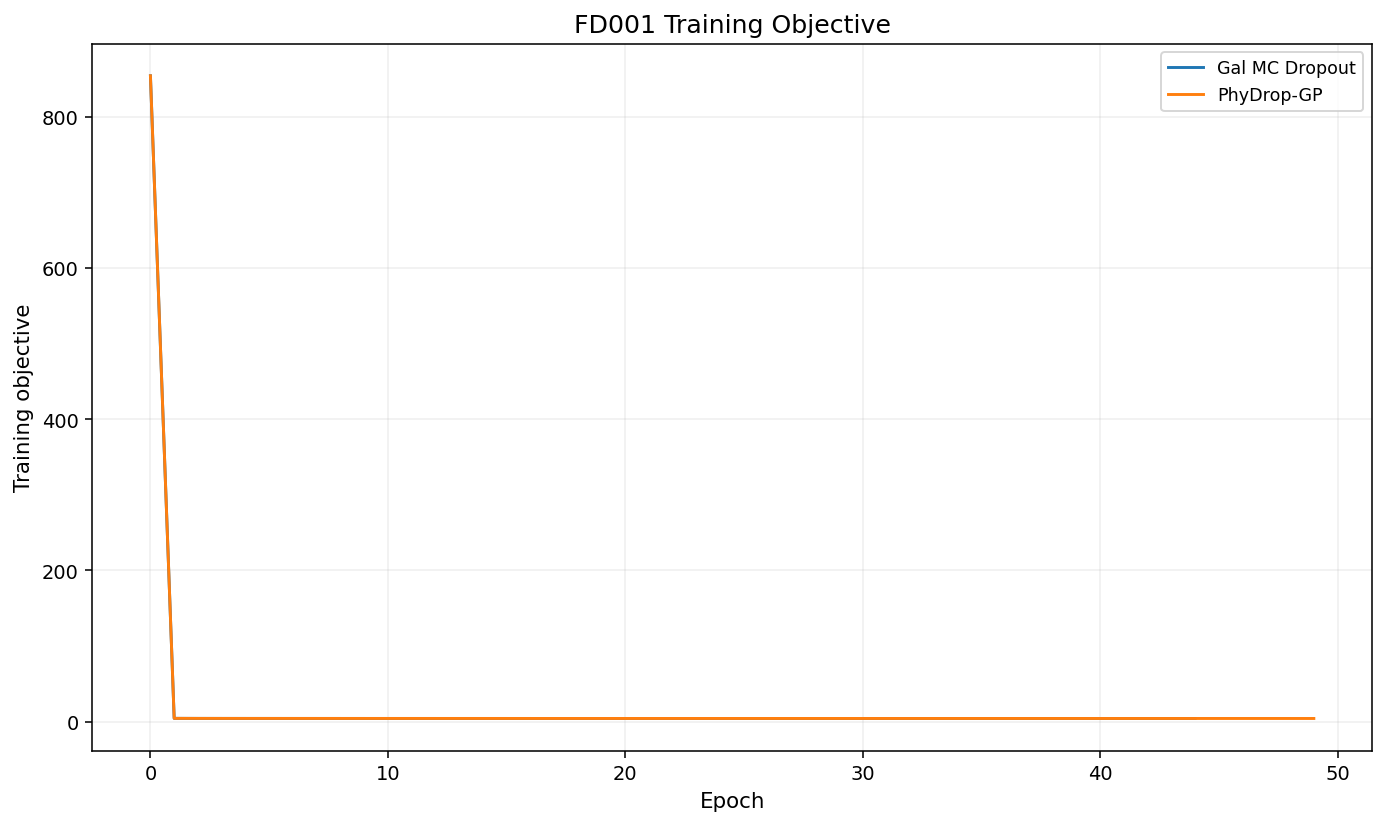

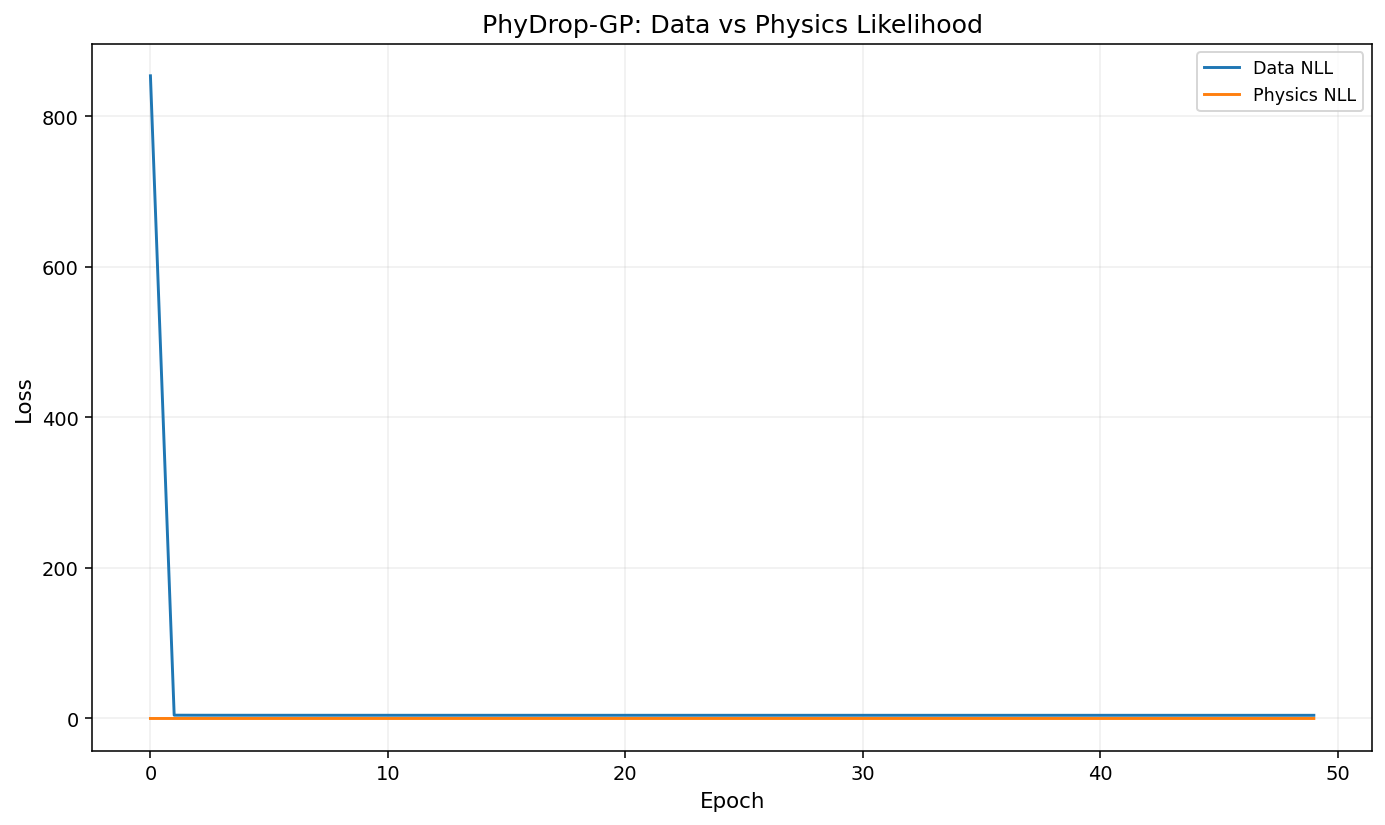

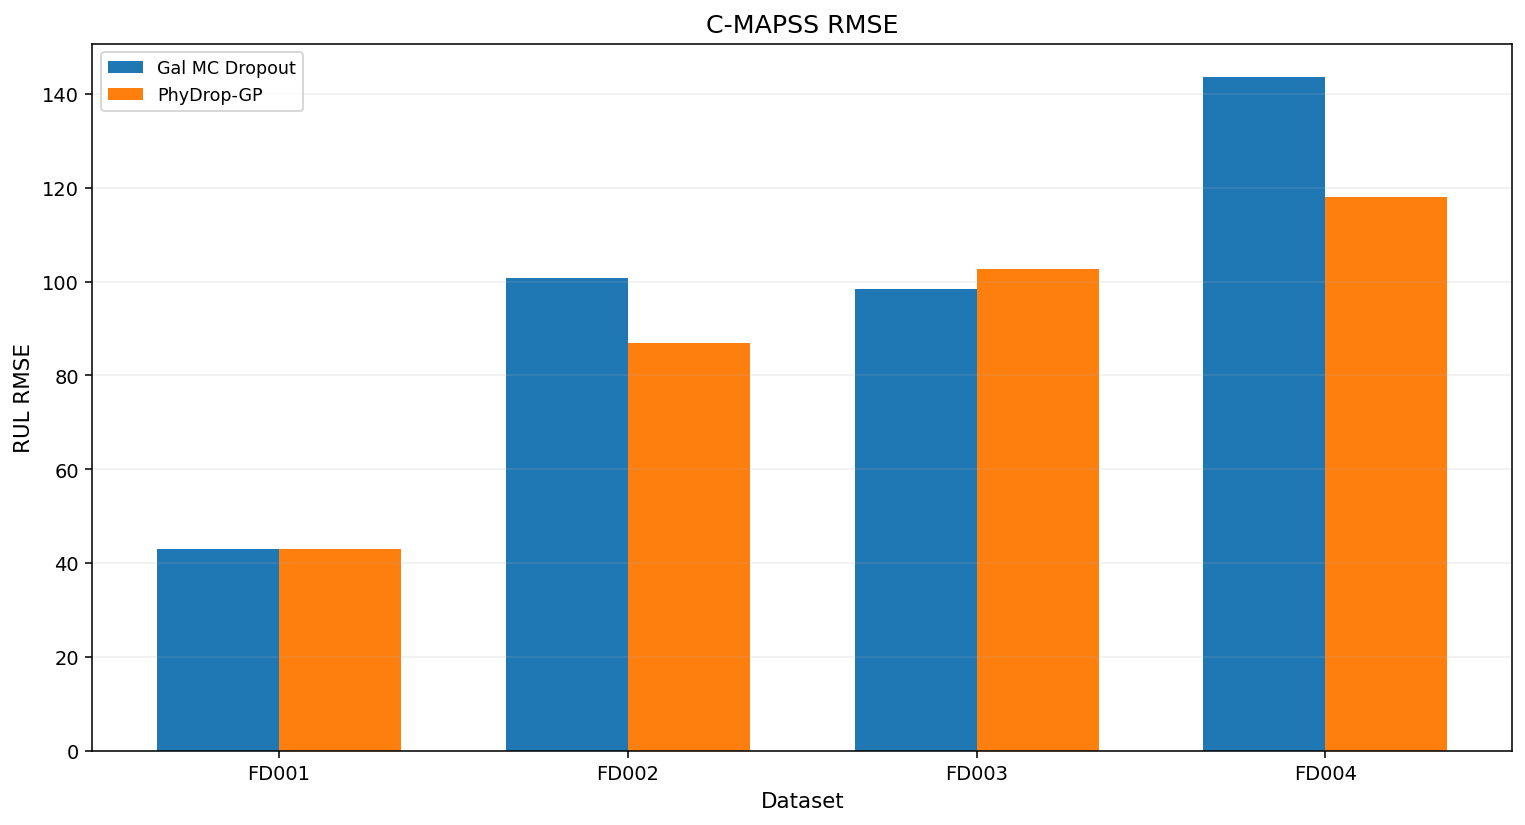

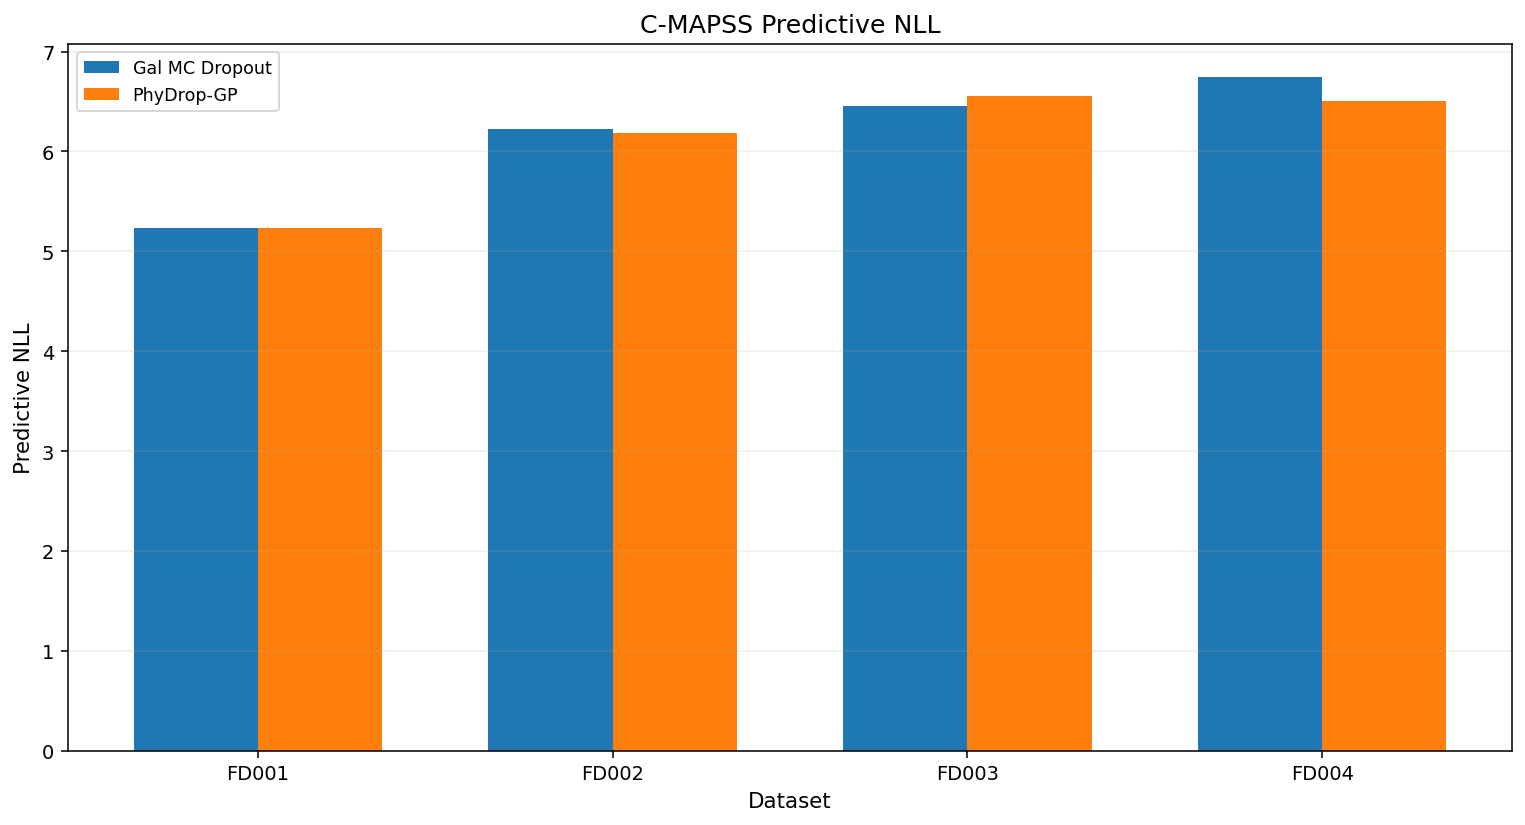

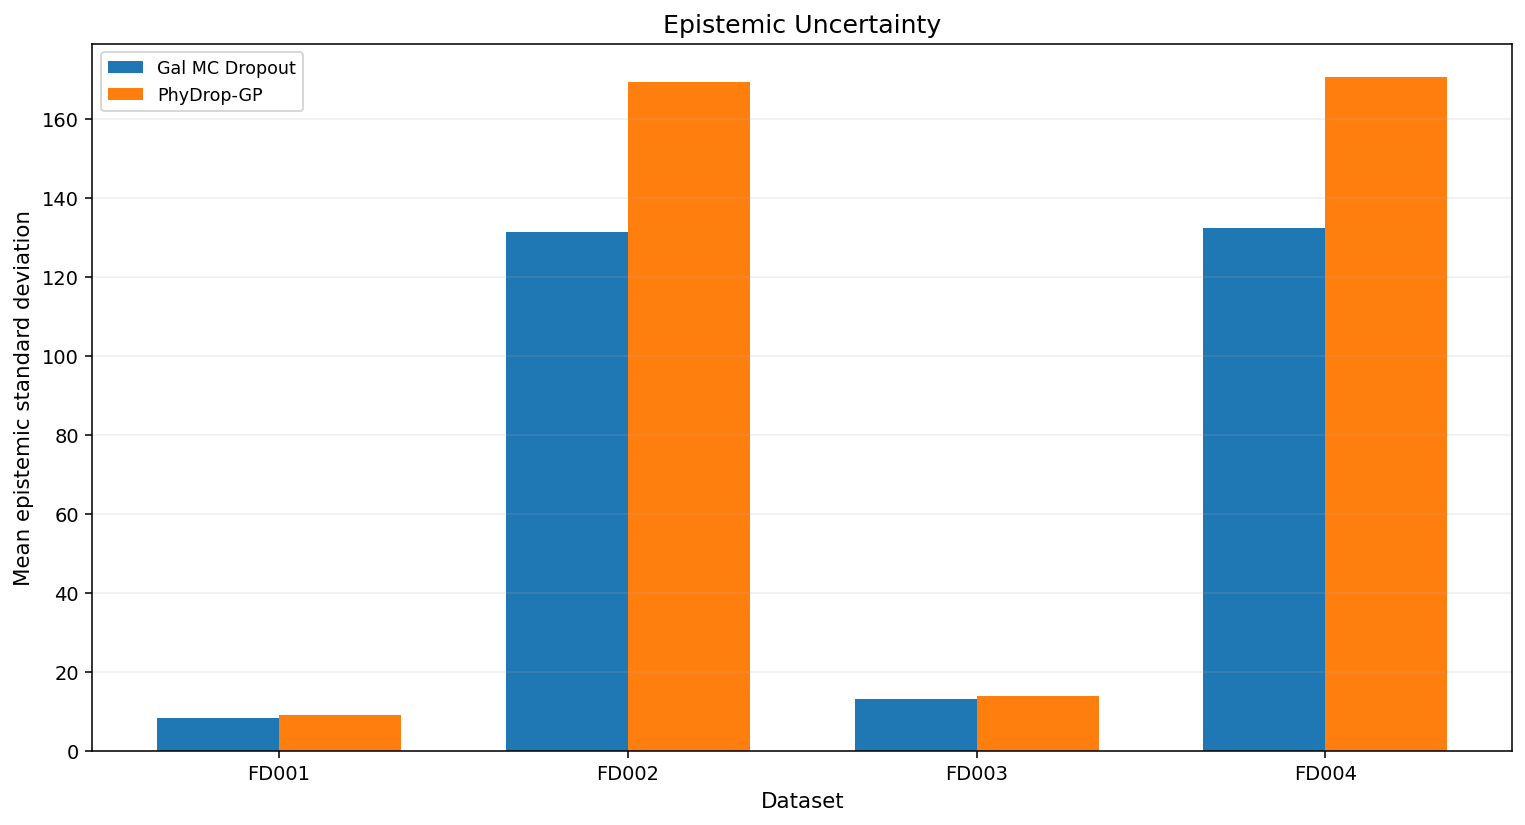

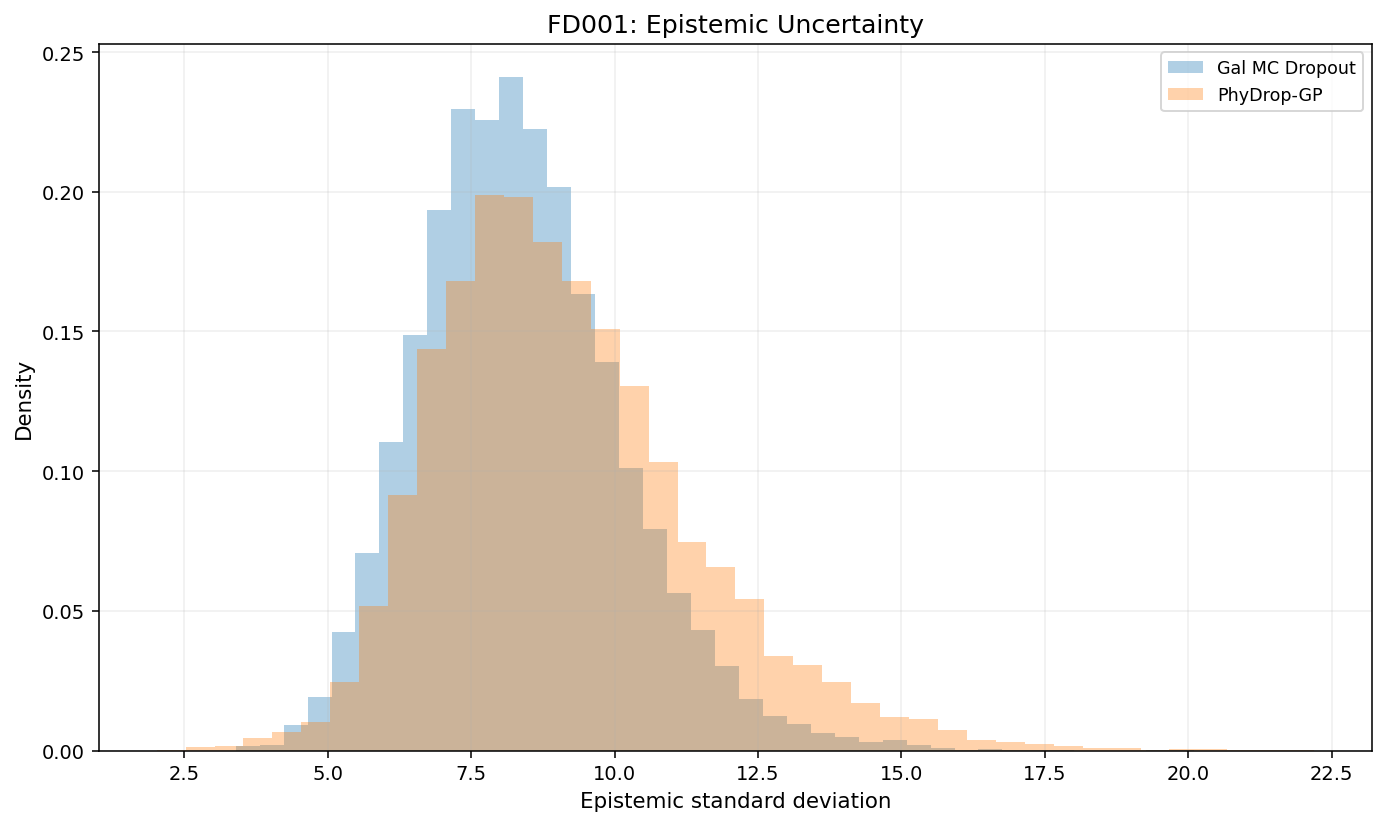

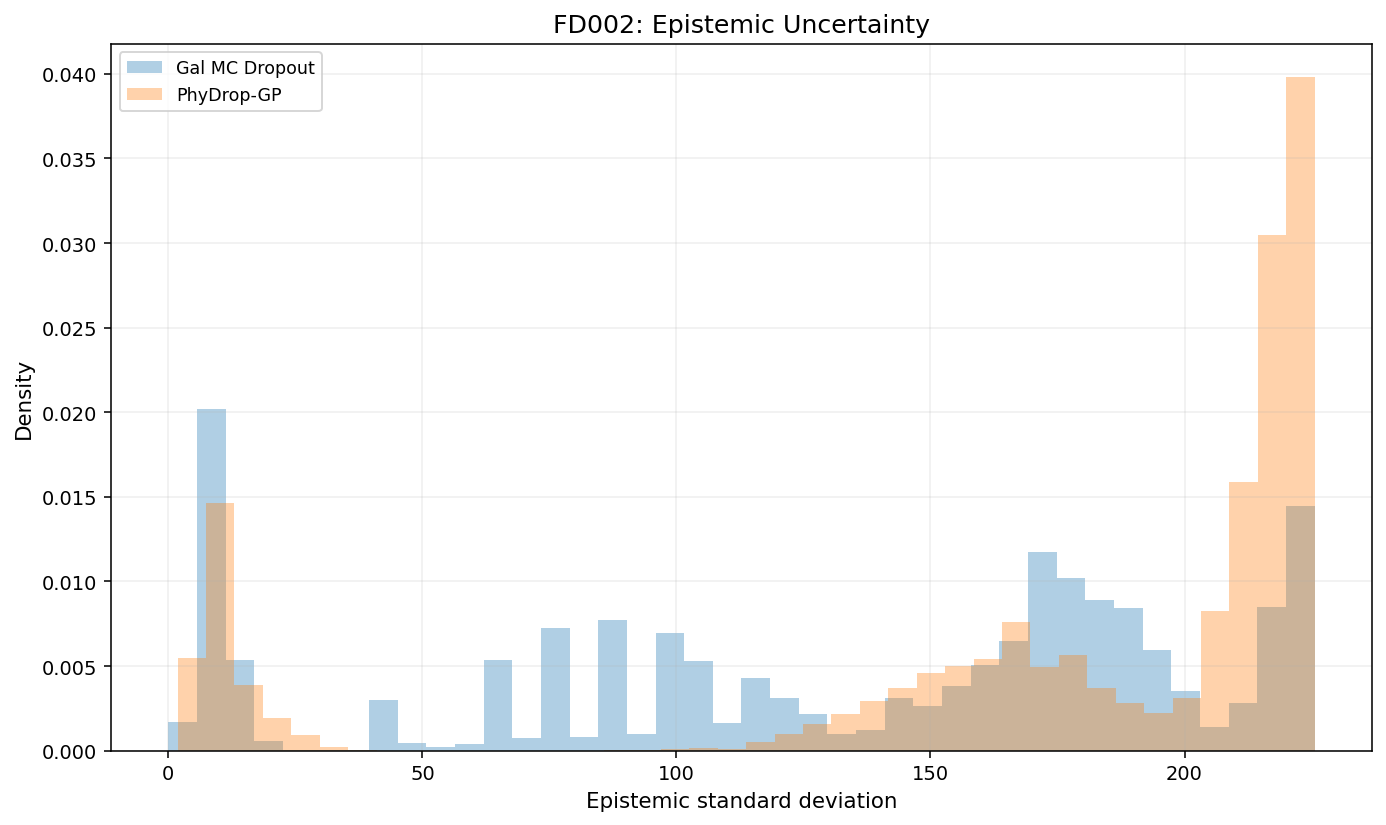

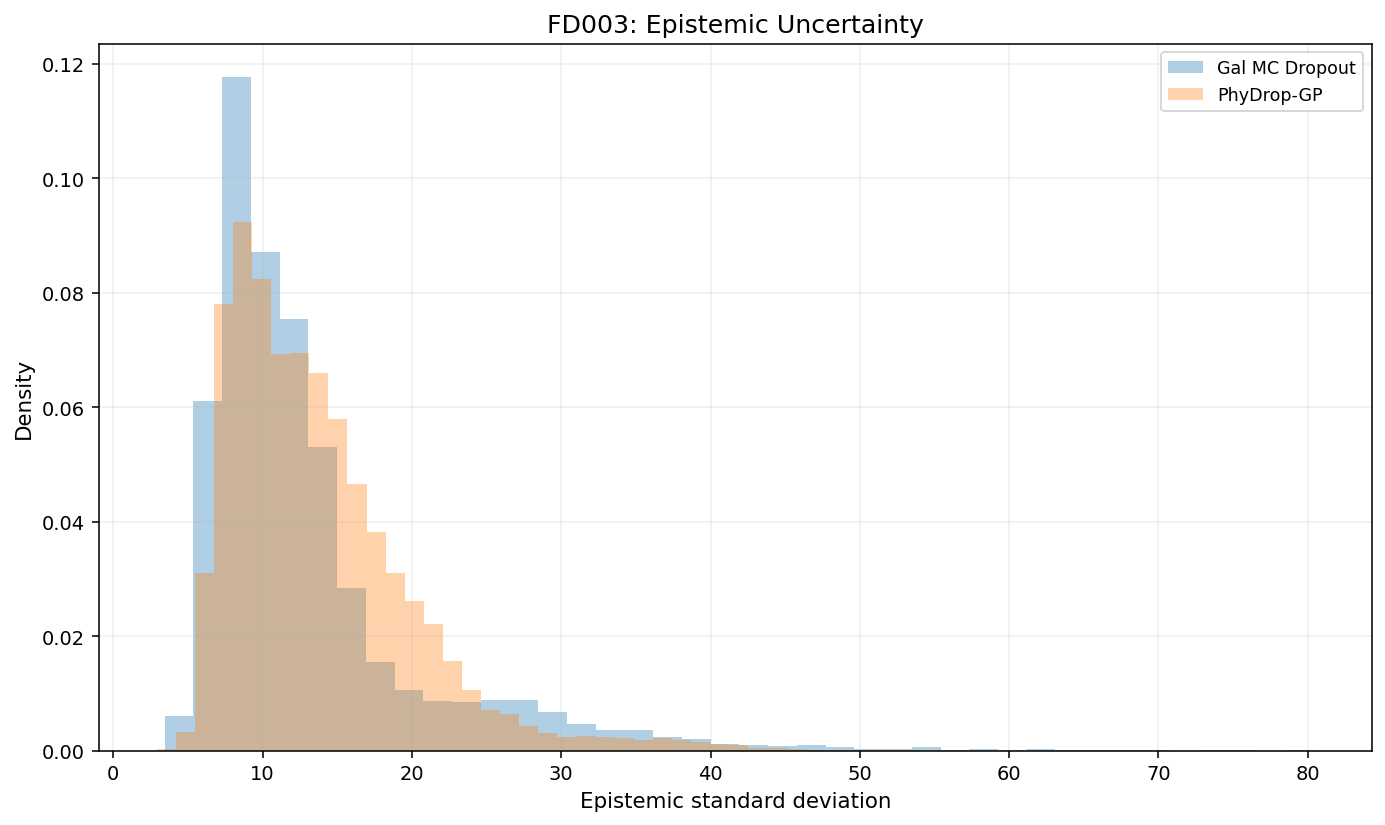

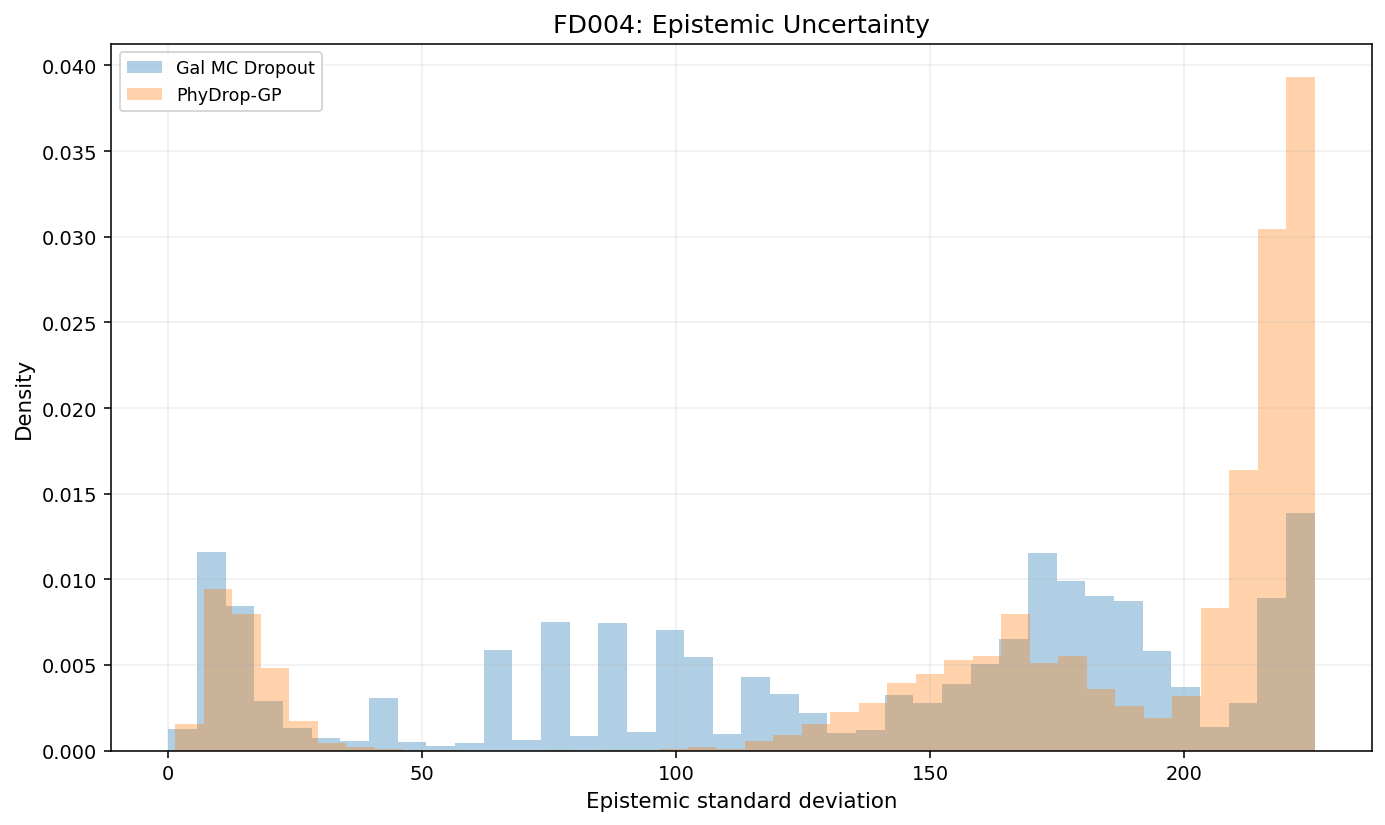

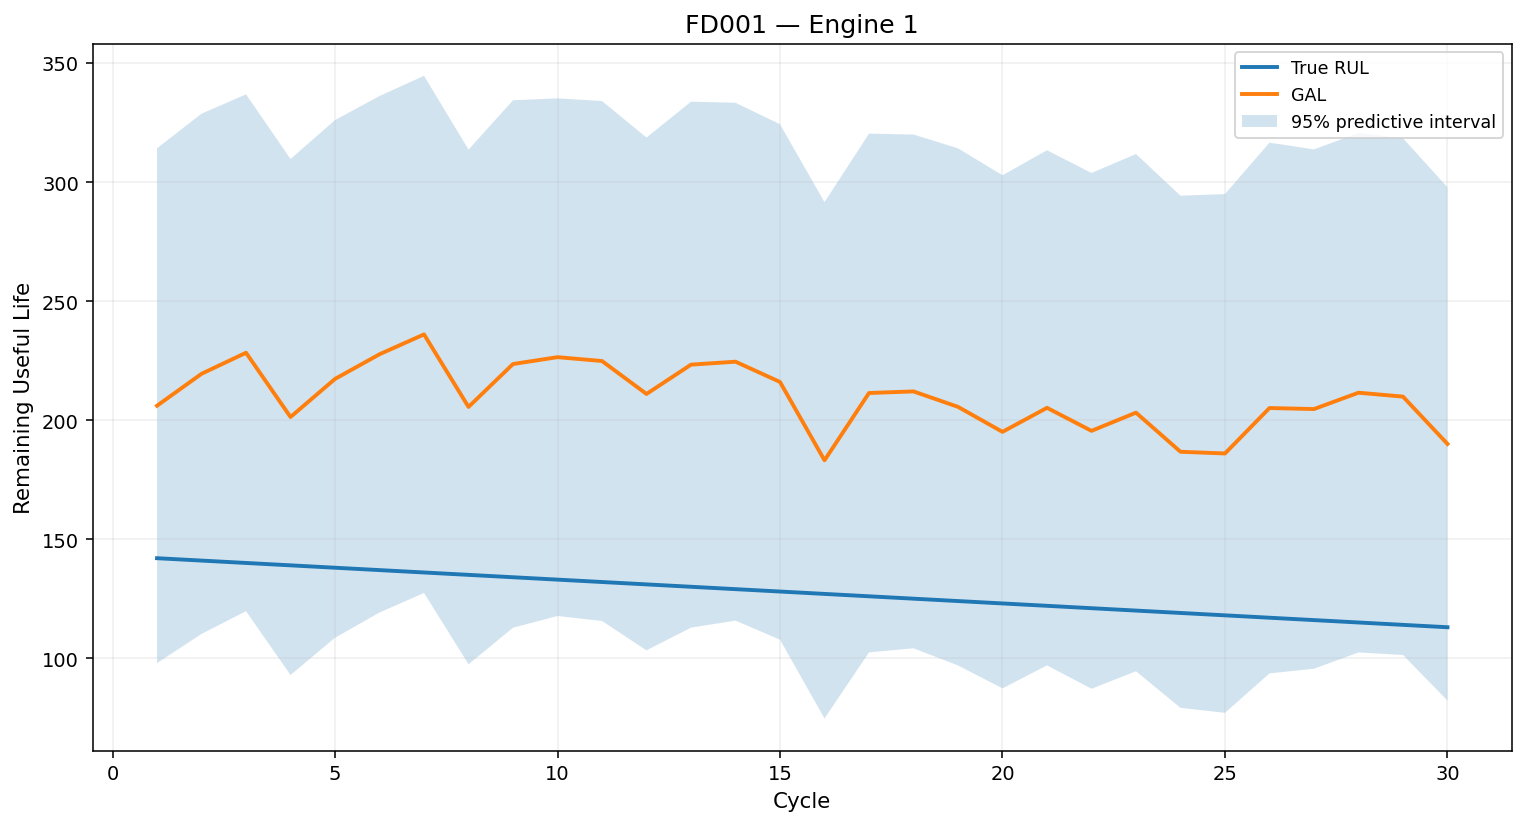

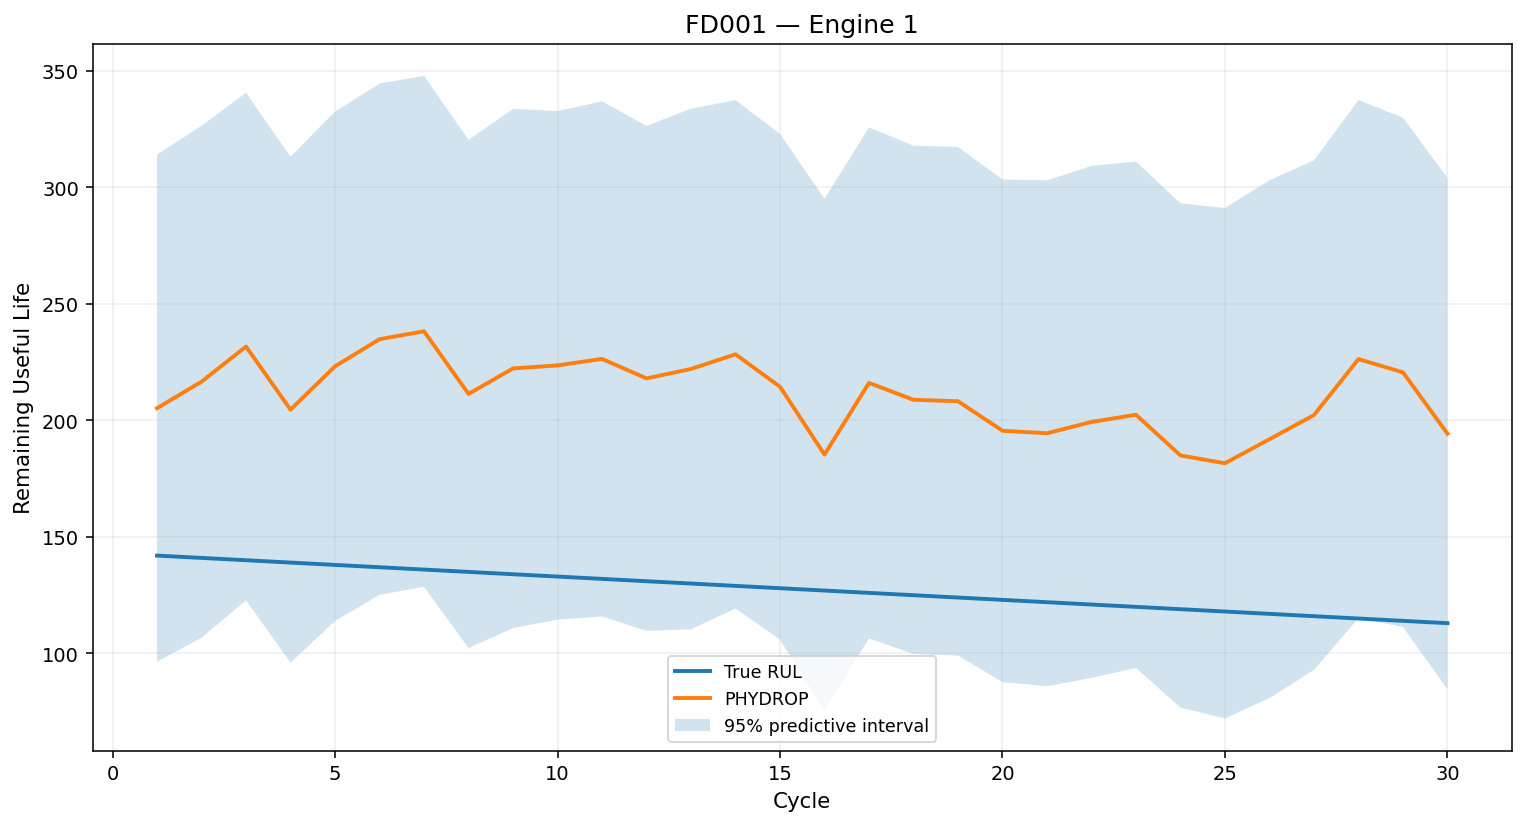


FINAL SCIENTIFIC INTERPRETATION

FD001
GAL | RMSE=42.902897 | MAE=34.188999 | NLL=5.231987 | Epistemic=8.381810
PHYDROP | RMSE=42.990981 | MAE=33.103603 | NLL=5.234778 | Epistemic=9.137518

FD002
GAL | RMSE=100.741266 | MAE=80.561836 | NLL=6.225798 | Epistemic=131.263260
PHYDROP | RMSE=86.896454 | MAE=68.959068 | NLL=6.184590 | Epistemic=169.343216

FD003
GAL | RMSE=98.346689 | MAE=70.528008 | NLL=6.452716 | Epistemic=13.142765
PHYDROP | RMSE=102.752043 | MAE=71.481979 | NLL=6.551677 | Epistemic=13.765972

FD004
GAL | RMSE=143.547003 | MAE=113.501328 | NLL=6.742249 | Epistemic=132.307175
PHYDROP | RMSE=118.049695 | MAE=91.356728 | NLL=6.508328 | Epistemic=170.474472

FILES SAVED
Results: /content/CMAPSS_corrected_experiment1_results.csv
Predictions: /content/CMAPSS_corrected_predictions
GAL model: /content/CMAPSS_Gal_corrected.pt
PhyDrop model: /content/CMAPSS_PhyDrop_corrected.pt

EXPERIMENT COMPLETE


In [ ]:
import os
import glob
import zipfile
import random
import warnings
import copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader

SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE")
print(DEVICE)

ZIP_CANDIDATES=[
    "/content/CMAPSSData.zip",
    "/content/C-MAPSSData.zip",
    "/content/cmapssdata.zip"
]
EXTRACT_DIR="/content/CMAPSS_CORRECTED"
HIDDEN_DIM=128
DROPOUT_P=0.10
BATCH_SIZE=256
EPOCHS_GAL=45
EPOCHS_PHYDROP=50
PRETRAIN_EPOCHS_PHYDROP=5
LR=1e-3
WEIGHT_DECAY=1e-5
TAU_P=1.0
LAMBDA_PHYS=1.0
MC_SAMPLES=100
VALIDATION_FRACTION=0.20
EPS=1e-8
RUL_MARGIN=0.25

zip_path=None
for candidate in ZIP_CANDIDATES:
    if os.path.exists(candidate):
        zip_path=candidate
        break
if zip_path is None:
    matches=glob.glob("/content/**/*.zip",recursive=True)
    for f in matches:
        if "cmapss" in os.path.basename(f).lower():
            zip_path=f
            break
if zip_path is None:
    raise FileNotFoundError("CMAPSS ZIP was not found in /content. Upload CMAPSSData.zip to Colab first.")

print("\nC-MAPSS ZIP")
print(zip_path)

os.makedirs(EXTRACT_DIR,exist_ok=True)
with zipfile.ZipFile(zip_path,"r") as z:
    z.extractall(EXTRACT_DIR)
print("Extracted to:",EXTRACT_DIR)

def find_file(filename):
    matches=glob.glob(os.path.join(EXTRACT_DIR,"**",filename),recursive=True)
    if len(matches)>0:
        return matches[0]
    all_files=glob.glob(os.path.join(EXTRACT_DIR,"**","*"),recursive=True)
    for f in all_files:
        if os.path.basename(f).lower()==filename.lower():
            return f
    return None

SENSOR_COLUMNS=[f"sensor_{i}" for i in range(1,22)]
BASE_COLUMNS=["unit","cycle","setting_1","setting_2","setting_3"]
ALL_COLUMNS=BASE_COLUMNS+SENSOR_COLUMNS

def load_fd(fd):
    train_file=find_file(f"train_{fd}.txt")
    test_file=find_file(f"test_{fd}.txt")
    rul_file=find_file(f"RUL_{fd}.txt")
    if train_file is None:
        raise FileNotFoundError(f"train_{fd}.txt not found")
    if test_file is None:
        raise FileNotFoundError(f"test_{fd}.txt not found")
    if rul_file is None:
        raise FileNotFoundError(f"RUL_{fd}.txt not found")
    train=pd.read_csv(train_file,sep=r"\s+",header=None,engine="python")
    test=pd.read_csv(test_file,sep=r"\s+",header=None,engine="python")
    rul=pd.read_csv(rul_file,sep=r"\s+",header=None,engine="python")
    train=train.iloc[:,:26].copy()
    test=test.iloc[:,:26].copy()
    train.columns=ALL_COLUMNS
    test.columns=ALL_COLUMNS
    rul=rul.iloc[:,0].values.astype(np.float32)

    # Training and test RUL construction.
    max_cycle=train.groupby("unit")["cycle"].max()
    train["RUL"]=(train["unit"].map(max_cycle)-train["cycle"]).astype(np.float32)
    test_max_cycle=test.groupby("unit")["cycle"].max()
    sorted_test_units=np.sort(test["unit"].unique())
    terminal_rul={unit:rul[i] for i,unit in enumerate(sorted_test_units)}
    test["RUL"]=(test["unit"].map(test_max_cycle)-test["cycle"]+test["unit"].map(terminal_rul)).astype(np.float32)

    return {"train":train,"test":test,"rul":rul}

DATA={}
for fd in ["FD001","FD002","FD003","FD004"]:
    print(f"\nLOADING {fd}")
    DATA[fd]=load_fd(fd)
    print("Train:",DATA[fd]["train"].shape)
    print("Test:",DATA[fd]["test"].shape)
    print("Training engines:",DATA[fd]["train"]["unit"].nunique())
    print("Test engines:",DATA[fd]["test"]["unit"].nunique())

def add_condition_id(df):
    df=df.copy()
    conditions=df[["setting_1","setting_2","setting_3"]].round(6).astype(str).agg("_".join,axis=1)
    unique_conditions={value:i for i,value in enumerate(sorted(conditions.unique()))}
    df["condition_id"]=conditions.map(unique_conditions)
    return df

for fd in DATA.keys():
    DATA[fd]["train"]=add_condition_id(DATA[fd]["train"])
    DATA[fd]["test"]=add_condition_id(DATA[fd]["test"])

for fd in ["FD001","FD002","FD003","FD004"]:
    print(f"\n{fd} OPERATING CONDITIONS")
    print("Train condition counts:")
    print(DATA[fd]["train"]["condition_id"].value_counts().sort_index())
    print("\nTest condition counts:")
    print(DATA[fd]["test"]["condition_id"].value_counts().sort_index())

candidate_features=["cycle","setting_1","setting_2","setting_3"]+SENSOR_COLUMNS

# Engine-level consecutive pairs define the discrete RUL physics constraint.
def build_pairs(df):
    df=df.sort_values(["unit","cycle"]).copy()
    records=[]
    for unit,group in df.groupby("unit",sort=False):
        group=group.sort_values("cycle")
        X=group[candidate_features].values.astype(np.float32)
        y=group["RUL"].values.astype(np.float32)
        cycles=group["cycle"].values
        conditions=group["condition_id"].values
        for i in range(len(group)-1):
            if cycles[i+1]-cycles[i]!=1:
                continue
            records.append({
                "unit":unit,
                "cycle":cycles[i],
                "next_cycle":cycles[i+1],
                "X_t":X[i],
                "X_next":X[i+1],
                "y_t":y[i],
                "y_next":y[i+1],
                "condition_t":conditions[i],
                "condition_next":conditions[i+1]
            })
    return records

def pair_records_to_arrays(records):
    if len(records)==0:
        raise ValueError("No consecutive engine-level pairs were created.")
    X_t=np.stack([r["X_t"] for r in records])
    X_next=np.stack([r["X_next"] for r in records])
    y_t=np.asarray([r["y_t"] for r in records],dtype=np.float32)
    y_next=np.asarray([r["y_next"] for r in records],dtype=np.float32)
    units=np.asarray([r["unit"] for r in records])
    cycles=np.asarray([r["cycle"] for r in records])
    conditions=np.asarray([r["condition_t"] for r in records])
    return {"X_t":X_t,"X_next":X_next,"y_t":y_t,"y_next":y_next,"unit":units,"cycle":cycles,"condition":conditions}

# Neural network for RUL mean and heteroscedastic variance.
class RULPhyDropNet(nn.Module):
    def __init__(self,input_dim,hidden_dim=128,dropout=0.10):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.mean_head=nn.Linear(hidden_dim,1)
        self.logvar_head=nn.Linear(hidden_dim,1)

    def forward(self,x,r_max):
        h=self.backbone(x)
        raw_mean=self.mean_head(h).squeeze(-1)
        mean=r_max*torch.sigmoid(raw_mean)
        logvar=self.logvar_head(h).squeeze(-1)
        logvar=torch.clamp(logvar,-8.0,8.0)
        return mean,logvar

class PairDataset(Dataset):
    def __init__(self,X_t,X_next,y_t,y_next):
        self.X_t=torch.tensor(X_t,dtype=torch.float32)
        self.X_next=torch.tensor(X_next,dtype=torch.float32)
        self.y_t=torch.tensor(y_t,dtype=torch.float32)
        self.y_next=torch.tensor(y_next,dtype=torch.float32)

    def __len__(self):
        return len(self.X_t)

    def __getitem__(self,idx):
        return self.X_t[idx],self.X_next[idx],self.y_t[idx],self.y_next[idx]

def engine_split(df,validation_fraction=0.20):
    units=np.sort(df["unit"].unique())
    rng=np.random.default_rng(SEED)
    units=units.copy()
    rng.shuffle(units)
    n_val=max(1,int(len(units)*validation_fraction))
    val_units=set(units[:n_val])
    train_units=set(units[n_val:])
    train_df=df[df["unit"].isin(train_units)].copy()
    val_df=df[df["unit"].isin(val_units)].copy()
    assert train_units.isdisjoint(val_units)
    return train_df,val_df

def fit_scaler(train_df):
    means=train_df[candidate_features].mean().values.astype(np.float32)
    stds=train_df[candidate_features].std().values.astype(np.float32)
    keep=stds>1e-8
    means=means[keep]
    stds=stds[keep]
    feature_names=[candidate_features[i] for i in range(len(candidate_features)) if keep[i]]
    stds=stds+EPS
    return feature_names,means,stds

def transform_X(X_raw,feature_names,means,stds):
    indices=[candidate_features.index(f) for f in feature_names]
    X=X_raw[:,indices]
    X=(X-means)/stds
    return X.astype(np.float32)

def prepare_pair_data(df,feature_names,means,stds):
    records=build_pairs(df)
    pair_data=pair_records_to_arrays(records)
    pair_data["X_t"]=transform_X(pair_data["X_t"],feature_names,means,stds)
    pair_data["X_next"]=transform_X(pair_data["X_next"],feature_names,means,stds)
    return pair_data

def get_r_max(train_df):
    train_max=float(train_df["RUL"].max())
    return train_max*(1.0+RUL_MARGIN)

# Data likelihood for probabilistic RUL prediction.
def gaussian_nll(mean,logvar,y):
    variance=torch.exp(logvar)
    return 0.5*torch.mean(logvar+(y-mean)**2/variance)

# Discrete physics likelihood enforces one-cycle RUL degradation.
def discrete_physics_loss(model,X_t,X_next,r_max):
    mean_t,_=model(X_t,r_max)
    mean_next,_=model(X_next,r_max)
    residual=mean_next-mean_t+1.0
    normalized_residual=residual/r_max
    physics_nll=0.5*TAU_P*torch.mean(normalized_residual**2)
    return physics_nll,residual

def train_model(pair_data,input_dim,r_max,use_physics,name):
    model=RULPhyDropNet(input_dim=input_dim,hidden_dim=HIDDEN_DIM,dropout=DROPOUT_P).to(DEVICE)
    optimizer=torch.optim.Adam(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
    dataset=PairDataset(pair_data["X_t"],pair_data["X_next"],pair_data["y_t"],pair_data["y_next"])
    loader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=False)
    epochs=EPOCHS_PHYDROP if use_physics else EPOCHS_GAL
    history=[]

    print(f"\nTRAINING {name}")

    for epoch in range(epochs):
        model.train()
        total_loss_epoch=0.0
        data_loss_epoch=0.0
        physics_loss_epoch=0.0

        for X_t,X_next,y_t,y_next in loader:
            X_t=X_t.to(DEVICE)
            X_next=X_next.to(DEVICE)
            y_t=y_t.to(DEVICE)
            y_next=y_next.to(DEVICE)
            optimizer.zero_grad()

            mean_t,logvar_t=model(X_t,r_max)
            mean_next,logvar_next=model(X_next,r_max)

            loss_t=gaussian_nll(mean_t,logvar_t,y_t)
            loss_next=gaussian_nll(mean_next,logvar_next,y_next)
            data_loss=0.5*(loss_t+loss_next)

            if use_physics and epoch>=PRETRAIN_EPOCHS_PHYDROP:
                physics_loss,residual=discrete_physics_loss(model,X_t,X_next,r_max)
                ramp=min(1.0,(epoch-PRETRAIN_EPOCHS_PHYDROP+1)/max(1,epochs-PRETRAIN_EPOCHS_PHYDROP))
                effective_lambda=LAMBDA_PHYS*ramp
            else:
                physics_loss=torch.tensor(0.0,device=DEVICE)
                effective_lambda=0.0

            total_loss=data_loss+effective_lambda*physics_loss
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=5.0)
            optimizer.step()

            total_loss_epoch+=total_loss.item()
            data_loss_epoch+=data_loss.item()
            physics_loss_epoch+=physics_loss.item()

        total_loss_epoch/=len(loader)
        data_loss_epoch/=len(loader)
        physics_loss_epoch/=len(loader)

        history.append({
            "total":total_loss_epoch,
            "data":data_loss_epoch,
            "physics":physics_loss_epoch
        })

        if epoch==0 or (epoch+1)%10==0 or epoch==PRETRAIN_EPOCHS_PHYDROP-1:
            print(f"Epoch {epoch+1:03d}/{epochs} | Total={total_loss_epoch:.6f} | Data={data_loss_epoch:.6f} | Physics={physics_loss_epoch:.6f}")

    return model,history

@torch.no_grad()
def mc_predict(model,X,r_max,mc_samples=100):
    model.train()
    X_tensor=torch.tensor(X,dtype=torch.float32)
    all_means=[]
    all_variances=[]

    for start in range(0,len(X_tensor),2048):
        batch=X_tensor[start:start+2048].to(DEVICE)
        batch_means=[]
        batch_variances=[]

        for _ in range(mc_samples):
            mean,logvar=model(batch,r_max)
            batch_means.append(mean.cpu().numpy())
            batch_variances.append(torch.exp(logvar).cpu().numpy())

        all_means.append(np.stack(batch_means,axis=0))
        all_variances.append(np.stack(batch_variances,axis=0))

    all_means=np.concatenate(all_means,axis=1)
    all_variances=np.concatenate(all_variances,axis=1)

    predictive_mean=all_means.mean(axis=0)
    epistemic_variance=all_means.var(axis=0)
    aleatoric_variance=all_variances.mean(axis=0)
    predictive_variance=epistemic_variance+aleatoric_variance

    return {
        "mean":predictive_mean,
        "epistemic_variance":epistemic_variance,
        "epistemic_std":np.sqrt(epistemic_variance+EPS),
        "aleatoric_variance":aleatoric_variance,
        "predictive_variance":predictive_variance,
        "predictive_std":np.sqrt(predictive_variance+EPS),
        "mc_means":all_means
    }

def gaussian_nll_numpy(y,mean,variance):
    variance=np.maximum(variance,1e-6)
    return float(np.mean(0.5*(np.log(2.0*np.pi*variance)+((y-mean)**2/variance))))

def calculate_interval_metrics(y,mean,std):
    levels={
        0.50:0.67448975,
        0.80:1.28155157,
        0.90:1.64485363,
        0.95:1.95996398
    }
    results={}
    calibration_errors=[]

    for level,z in levels.items():
        lower=mean-z*std
        upper=mean+z*std
        coverage=np.mean((y>=lower)&(y<=upper))
        width=np.mean(upper-lower)
        key=int(level*100)
        results[f"Coverage_{key}"]=float(coverage)
        results[f"Width_{key}"]=float(width)
        calibration_errors.append(abs(coverage-level))

    results["Interval_Calibration_Error"]=float(np.mean(calibration_errors))
    return results

def error_uncertainty_correlation(y,mean,uncertainty):
    abs_error=np.abs(y-mean)
    if np.std(abs_error)<EPS or np.std(uncertainty)<EPS:
        return np.nan
    return float(np.corrcoef(abs_error,uncertainty)[0,1])

def evaluate_predictions(y,prediction):
    mean=prediction["mean"]
    predictive_std=prediction["predictive_std"]
    epistemic_std=prediction["epistemic_std"]
    rmse=np.sqrt(mean_squared_error(y,mean))
    mae=mean_absolute_error(y,mean)
    nll=gaussian_nll_numpy(y,mean,predictive_std**2)
    interval=calculate_interval_metrics(y,mean,predictive_std)
    corr=error_uncertainty_correlation(y,mean,epistemic_std)

    return {
        "RMSE":float(rmse),
        "MAE":float(mae),
        "NLL":float(nll),
        "Mean Predictive Std":float(np.mean(predictive_std)),
        "Mean Epistemic Std":float(np.mean(epistemic_std)),
        "Mean Aleatoric Std":float(np.mean(np.sqrt(prediction["aleatoric_variance"]+EPS))),
        "Error-Uncertainty Corr":corr,
        **interval
    }

def run_basic_experiment():
    print("\nEXPERIMENT 1: FD001 -> ID/OOD")

    fd001_train=DATA["FD001"]["train"].copy()
    train_df,val_df=engine_split(fd001_train,VALIDATION_FRACTION)

    feature_names,means,stds=fit_scaler(train_df)
    r_max=get_r_max(train_df)

    print("\nTrain RUL max:",train_df["RUL"].max())
    print("R_MAX:",r_max)
    print("Features:",len(feature_names))

    train_pairs=prepare_pair_data(train_df,feature_names,means,stds)
    val_pairs=prepare_pair_data(val_df,feature_names,means,stds)

    print("Training pairs:",len(train_pairs["y_t"]))
    print("Validation pairs:",len(val_pairs["y_t"]))

    torch.manual_seed(SEED)
    base_model=RULPhyDropNet(input_dim=len(feature_names),hidden_dim=HIDDEN_DIM,dropout=DROPOUT_P).to(DEVICE)
    base_state=copy.deepcopy(base_model.state_dict())

    torch.manual_seed(SEED)
    gal_model,gal_history=train_model(train_pairs,len(feature_names),r_max,use_physics=False,name="GAL MC DROPOUT")

    torch.manual_seed(SEED)
    phydrop_model,phydrop_history=train_model(train_pairs,len(feature_names),r_max,use_physics=True,name="PHYDROP-GP")

    gal_val=mc_predict(gal_model,val_pairs["X_t"],r_max,MC_SAMPLES)
    phy_val=mc_predict(phydrop_model,val_pairs["X_t"],r_max,MC_SAMPLES)

    print("\nVALIDATION")
    print("\nGAL:")
    for k,v in evaluate_predictions(val_pairs["y_t"],gal_val).items():
        print(f"{k}: {v:.6f}")

    print("\nPHYDROP:")
    for k,v in evaluate_predictions(val_pairs["y_t"],phy_val).items():
        print(f"{k}: {v:.6f}")

    eval_sets={}
    eval_sets["FD001"]=DATA["FD001"]["test"]
    eval_sets["FD002"]=DATA["FD002"]["test"]
    eval_sets["FD003"]=DATA["FD003"]["test"]
    eval_sets["FD004"]=DATA["FD004"]["test"]

    results=[]
    predictions={}

    for fd,test_df in eval_sets.items():
        pair_test=prepare_pair_data(test_df,feature_names,means,stds)

        gal_pred=mc_predict(gal_model,pair_test["X_t"],r_max,MC_SAMPLES)
        gal_metrics=evaluate_predictions(pair_test["y_t"],gal_pred)
        gal_metrics["Model"]="GAL MC DROPOUT"
        gal_metrics["Dataset"]=fd
        results.append(gal_metrics)

        predictions[("GAL",fd)]={
            "prediction":gal_pred,
            "y":pair_test["y_t"],
            "unit":pair_test["unit"],
            "cycle":pair_test["cycle"]
        }

        phy_pred=mc_predict(phydrop_model,pair_test["X_t"],r_max,MC_SAMPLES)
        phy_metrics=evaluate_predictions(pair_test["y_t"],phy_pred)
        phy_metrics["Model"]="PHYDROP-GP"
        phy_metrics["Dataset"]=fd
        results.append(phy_metrics)

        predictions[("PHYDROP",fd)]={
            "prediction":phy_pred,
            "y":pair_test["y_t"],
            "unit":pair_test["unit"],
            "cycle":pair_test["cycle"]
        }

    results_df=pd.DataFrame(results)

    ordered_columns=[
        "Model",
        "Dataset",
        "RMSE",
        "MAE",
        "NLL",
        "Mean Predictive Std",
        "Mean Epistemic Std",
        "Mean Aleatoric Std",
        "Coverage_50",
        "Coverage_80",
        "Coverage_90",
        "Coverage_95",
        "Width_95",
        "Interval_Calibration_Error",
        "Error-Uncertainty Corr"
    ]

    results_df=results_df[ordered_columns]

    return {
        "gal_model":gal_model,
        "phydrop_model":phydrop_model,
        "gal_history":gal_history,
        "phydrop_history":phydrop_history,
        "results":results_df,
        "predictions":predictions,
        "feature_names":feature_names,
        "means":means,
        "stds":stds,
        "r_max":r_max
    }

basic=run_basic_experiment()

print("\nEXPERIMENT 1 — FINAL RESULTS")
print(basic["results"].to_string(index=False,float_format=lambda x:f"{x:.6f}"))

def print_uncertainty_ratios(results_obj):
    pred=results_obj["predictions"]

    for model in ["GAL","PHYDROP"]:
        id_unc=pred[(model,"FD001")]["prediction"]["epistemic_std"]
        print("\n",model)

        for fd in ["FD002","FD003","FD004"]:
            ood_unc=pred[(model,fd)]["prediction"]["epistemic_std"]
            ratio=np.mean(ood_unc)/(np.mean(id_unc)+EPS)

            scores=np.concatenate([id_unc,ood_unc])
            labels=np.concatenate([
                np.zeros(len(id_unc)),
                np.ones(len(ood_unc))
            ])

            try:
                auc=roc_auc_score(labels,scores)
            except:
                auc=np.nan

            print(f"{fd}: uncertainty ratio={ratio:.4f}, OOD AUROC={auc:.5f}")

print("\nEXPERIMENT 1 — OOD UNCERTAINTY")
print_uncertainty_ratios(basic)

plt.figure(figsize=(10,6))
plt.plot([h["total"] for h in basic["gal_history"]],label="Gal MC Dropout")
plt.plot([h["total"] for h in basic["phydrop_history"]],label="PhyDrop-GP")
plt.xlabel("Epoch")
plt.ylabel("Training objective")
plt.title("FD001 Training Objective")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.plot([h["data"] for h in basic["phydrop_history"]],label="Data NLL")
plt.plot([h["physics"] for h in basic["phydrop_history"]],label="Physics NLL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PhyDrop-GP: Data vs Physics Likelihood")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

r1=basic["results"]
datasets_order=["FD001","FD002","FD003","FD004"]
gal_rmse=[]
phy_rmse=[]

for fd in datasets_order:
    gal_rmse.append(r1.loc[((r1["Model"]=="GAL MC DROPOUT")&(r1["Dataset"]==fd)),"RMSE"].iloc[0])
    phy_rmse.append(r1.loc[((r1["Model"]=="PHYDROP-GP")&(r1["Dataset"]==fd)),"RMSE"].iloc[0])

x=np.arange(len(datasets_order))
width=0.35

plt.figure(figsize=(11,6))
plt.bar(x-width/2,gal_rmse,width,label="Gal MC Dropout")
plt.bar(x+width/2,phy_rmse,width,label="PhyDrop-GP")
plt.xticks(x,datasets_order)
plt.ylabel("RUL RMSE")
plt.xlabel("Dataset")
plt.title("C-MAPSS RMSE")
plt.legend()
plt.grid(axis="y",alpha=0.2)
plt.tight_layout()
plt.show()

gal_nll=[]
phy_nll=[]

for fd in datasets_order:
    gal_nll.append(r1.loc[((r1["Model"]=="GAL MC DROPOUT")&(r1["Dataset"]==fd)),"NLL"].iloc[0])
    phy_nll.append(r1.loc[((r1["Model"]=="PHYDROP-GP")&(r1["Dataset"]==fd)),"NLL"].iloc[0])

plt.figure(figsize=(11,6))
plt.bar(x-width/2,gal_nll,width,label="Gal MC Dropout")
plt.bar(x+width/2,phy_nll,width,label="PhyDrop-GP")
plt.xticks(x,datasets_order)
plt.ylabel("Predictive NLL")
plt.xlabel("Dataset")
plt.title("C-MAPSS Predictive NLL")
plt.legend()
plt.grid(axis="y",alpha=0.2)
plt.tight_layout()
plt.show()

gal_unc=[]
phy_unc=[]

for fd in datasets_order:
    gal_unc.append(r1.loc[((r1["Model"]=="GAL MC DROPOUT")&(r1["Dataset"]==fd)),"Mean Epistemic Std"].iloc[0])
    phy_unc.append(r1.loc[((r1["Model"]=="PHYDROP-GP")&(r1["Dataset"]==fd)),"Mean Epistemic Std"].iloc[0])

plt.figure(figsize=(11,6))
plt.bar(x-width/2,gal_unc,width,label="Gal MC Dropout")
plt.bar(x+width/2,phy_unc,width,label="PhyDrop-GP")
plt.xticks(x,datasets_order)
plt.ylabel("Mean epistemic standard deviation")
plt.xlabel("Dataset")
plt.title("Epistemic Uncertainty")
plt.legend()
plt.grid(axis="y",alpha=0.2)
plt.tight_layout()
plt.show()

for fd in ["FD001","FD002","FD003","FD004"]:
    gal_ep=basic["predictions"][("GAL",fd)]["prediction"]["epistemic_std"]
    phy_ep=basic["predictions"][("PHYDROP",fd)]["prediction"]["epistemic_std"]

    plt.figure(figsize=(10,6))
    plt.hist(gal_ep,bins=40,alpha=0.35,density=True,label="Gal MC Dropout")
    plt.hist(phy_ep,bins=40,alpha=0.35,density=True,label="PhyDrop-GP")
    plt.xlabel("Epistemic standard deviation")
    plt.ylabel("Density")
    plt.title(f"{fd}: Epistemic Uncertainty")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_engine(fd,unit,model_name):
    df=DATA[fd]["test"]
    rows=df[df["unit"]==unit].sort_values("cycle")

    pred_obj=basic["predictions"][(model_name,fd)]
    mask=pred_obj["unit"]==unit
    cycles=pred_obj["cycle"][mask]
    y=pred_obj["y"][mask]
    pred=pred_obj["prediction"]
    mean=pred["mean"][mask]
    std=pred["predictive_std"][mask]

    lower=mean-1.96*std
    upper=mean+1.96*std

    plt.figure(figsize=(11,6))
    plt.plot(cycles,y,linewidth=2,label="True RUL")
    plt.plot(cycles,mean,linewidth=2,label=f"{model_name}")
    plt.fill_between(cycles,lower,upper,alpha=0.20,label="95% predictive interval")
    plt.xlabel("Cycle")
    plt.ylabel("Remaining Useful Life")
    plt.title(f"{fd} — Engine {unit}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

example_unit=int(DATA["FD001"]["test"]["unit"].iloc[0])
plot_engine("FD001",example_unit,"GAL")
plot_engine("FD001",example_unit,"PHYDROP")

results_path_1="/content/CMAPSS_corrected_experiment1_results.csv"
basic["results"].to_csv(results_path_1,index=False)

prediction_dir="/content/CMAPSS_corrected_predictions"
os.makedirs(prediction_dir,exist_ok=True)

for model_name in ["GAL","PHYDROP"]:
    for fd in ["FD001","FD002","FD003","FD004"]:
        obj=basic["predictions"][(model_name,fd)]
        pred=obj["prediction"]

        output=pd.DataFrame({
            "unit":obj["unit"],
            "cycle":obj["cycle"],
            "true_RUL":obj["y"],
            "predicted_RUL":pred["mean"],
            "predictive_std":pred["predictive_std"],
            "epistemic_std":pred["epistemic_std"],
            "aleatoric_variance":pred["aleatoric_variance"]
        })

        path=os.path.join(prediction_dir,f"{model_name}_{fd}.csv")
        output.to_csv(path,index=False)

torch.save(basic["gal_model"].state_dict(),"/content/CMAPSS_Gal_corrected.pt")
torch.save(basic["phydrop_model"].state_dict(),"/content/CMAPSS_PhyDrop_corrected.pt")

print("\nFINAL SCIENTIFIC INTERPRETATION")

results_final=basic["results"]

for fd in ["FD001","FD002","FD003","FD004"]:
    gal_row=results_final[((results_final["Model"]=="GAL MC DROPOUT")&(results_final["Dataset"]==fd))].iloc[0]
    phy_row=results_final[((results_final["Model"]=="PHYDROP-GP")&(results_final["Dataset"]==fd))].iloc[0]

    print(f"\n{fd}")
    print(f"GAL | RMSE={gal_row['RMSE']:.6f} | MAE={gal_row['MAE']:.6f} | NLL={gal_row['NLL']:.6f} | Epistemic={gal_row['Mean Epistemic Std']:.6f}")
    print(f"PHYDROP | RMSE={phy_row['RMSE']:.6f} | MAE={phy_row['MAE']:.6f} | NLL={phy_row['NLL']:.6f} | Epistemic={phy_row['Mean Epistemic Std']:.6f}")

print("\nFILES SAVED")
print("Results:",results_path_1)
print("Predictions:",prediction_dir)
print("GAL model:","/content/CMAPSS_Gal_corrected.pt")
print("PhyDrop model:","/content/CMAPSS_PhyDrop_corrected.pt")
print("\nEXPERIMENT COMPLETE")

## Experiment 4 — Layer-Relevance Analysis of Dropout

This experiment investigates where the uncertainty produced by Monte Carlo dropout enters a neural network. We use the Hamiltonian harmonic oscillator,

$$
\dot{q}=p,\qquad \dot{p}=-q,
$$

with the corresponding Hamiltonian

$$
H(q,p)=\frac{1}{2}(q^2+p^2).
$$

The exact dynamics conserve this Hamiltonian, providing a simple system in which the effect of the physics constraint can be clearly examined.

The standard Gal-style MC Dropout model is compared with PhyDrop-GP, which additionally penalises violations of the Hamiltonian dynamics through the physics operator

$$
P_H(f)=
\begin{bmatrix}
\dot{q}-p\\
\dot{p}+q
\end{bmatrix}.
$$

Instead of assigning the same dropout probability to every stochastic layer, we allow each layer to have its own dropout probability,

$$
d=(d_1,d_2,d_3),
$$

where $d_i$ denotes the dropout probability of layer $i$. The uniform case is recovered when

$$
d_1=d_2=d_3=d.
$$

We investigate four configurations: uniform dropout, monotonically increasing dropout, monotonically decreasing dropout, and Bayesian-optimised layer-dependent dropout. The models are evaluated both inside the training region and in an extrapolation region.

The aim is not only to compare predictive accuracy, but also to determine which layers contribute most strongly to epistemic uncertainty. To measure this, we compare the variance obtained when all layers are stochastic with the variance obtained when one layer is frozen.

Let $V_{\mathrm{full}}(x)$ denote the epistemic variance when all dropout layers are active, and let $V_{-i}(x)$ denote the variance when layer $i$ is frozen. We define the contribution of layer $i$ as

$$
\Delta_i=
\frac{1}{|X|}
\sum_{x\in X}
\left[
V_{\mathrm{full}}(x)-V_{-i}(x)
\right].
$$

The results show that heterogeneous dropout does not automatically improve predictive performance, with the uniform configuration remaining highly competitive. However, the layer-relevance analysis reveals that uncertainty is strongly concentrated in the first dropout layer, which accounts for the majority of the measured dropout-induced variance.

An important distinction therefore emerges between predictive relevance and uncertainty relevance. A layer does not necessarily need to improve RMSE substantially to play an important role in uncertainty propagation.

The experiment also shows that the physics-informed model provides more robust extrapolation behaviour and lower physics violation in the uniform-dropout setting. Overall, the results suggest that epistemic uncertainty is not uniformly distributed across a neural network, motivating future layer-aware approaches to Bayesian uncertainty modelling.

ADDITIONAL STUDY 5 — LAYER RELEVANCE DETERMINATION
Device: cpu

GENERATING HAMILTONIAN SIMULATION
Training: (2200, 2)
Validation: (600, 2)
E1 test: (400, 2)
E2 test: (400, 2)

TUNING Gal

Training candidate Gal rates=[0.05 0.05 0.05]

Training candidate Gal rates=[0.1 0.1 0.1]

Training candidate Gal rates=[0.2 0.2 0.2]

Training candidate Gal rates=[0.3 0.3 0.3]

Training candidate Gal rates=[0.05   0.0917 0.1333]

Training candidate Gal rates=[0.05   0.1333 0.2167]

Training candidate Gal rates=[0.05  0.175 0.3  ]

Training candidate Gal rates=[0.1333 0.175  0.2167]

Training candidate Gal rates=[0.1333 0.2167 0.3   ]

Training candidate Gal rates=[0.2167 0.2583 0.3   ]

Training candidate Gal rates=[0.1333 0.0917 0.05  ]

Training candidate Gal rates=[0.2167 0.1333 0.05  ]

Training candidate Gal rates=[0.3   0.175 0.05 ]

Training candidate Gal rates=[0.2167 0.175  0.1333]

Training candidate Gal rates=[0.3    0.2167 0.1333]

Training candidate Gal rates=[0.3    0.2583 0.2167]

Tra

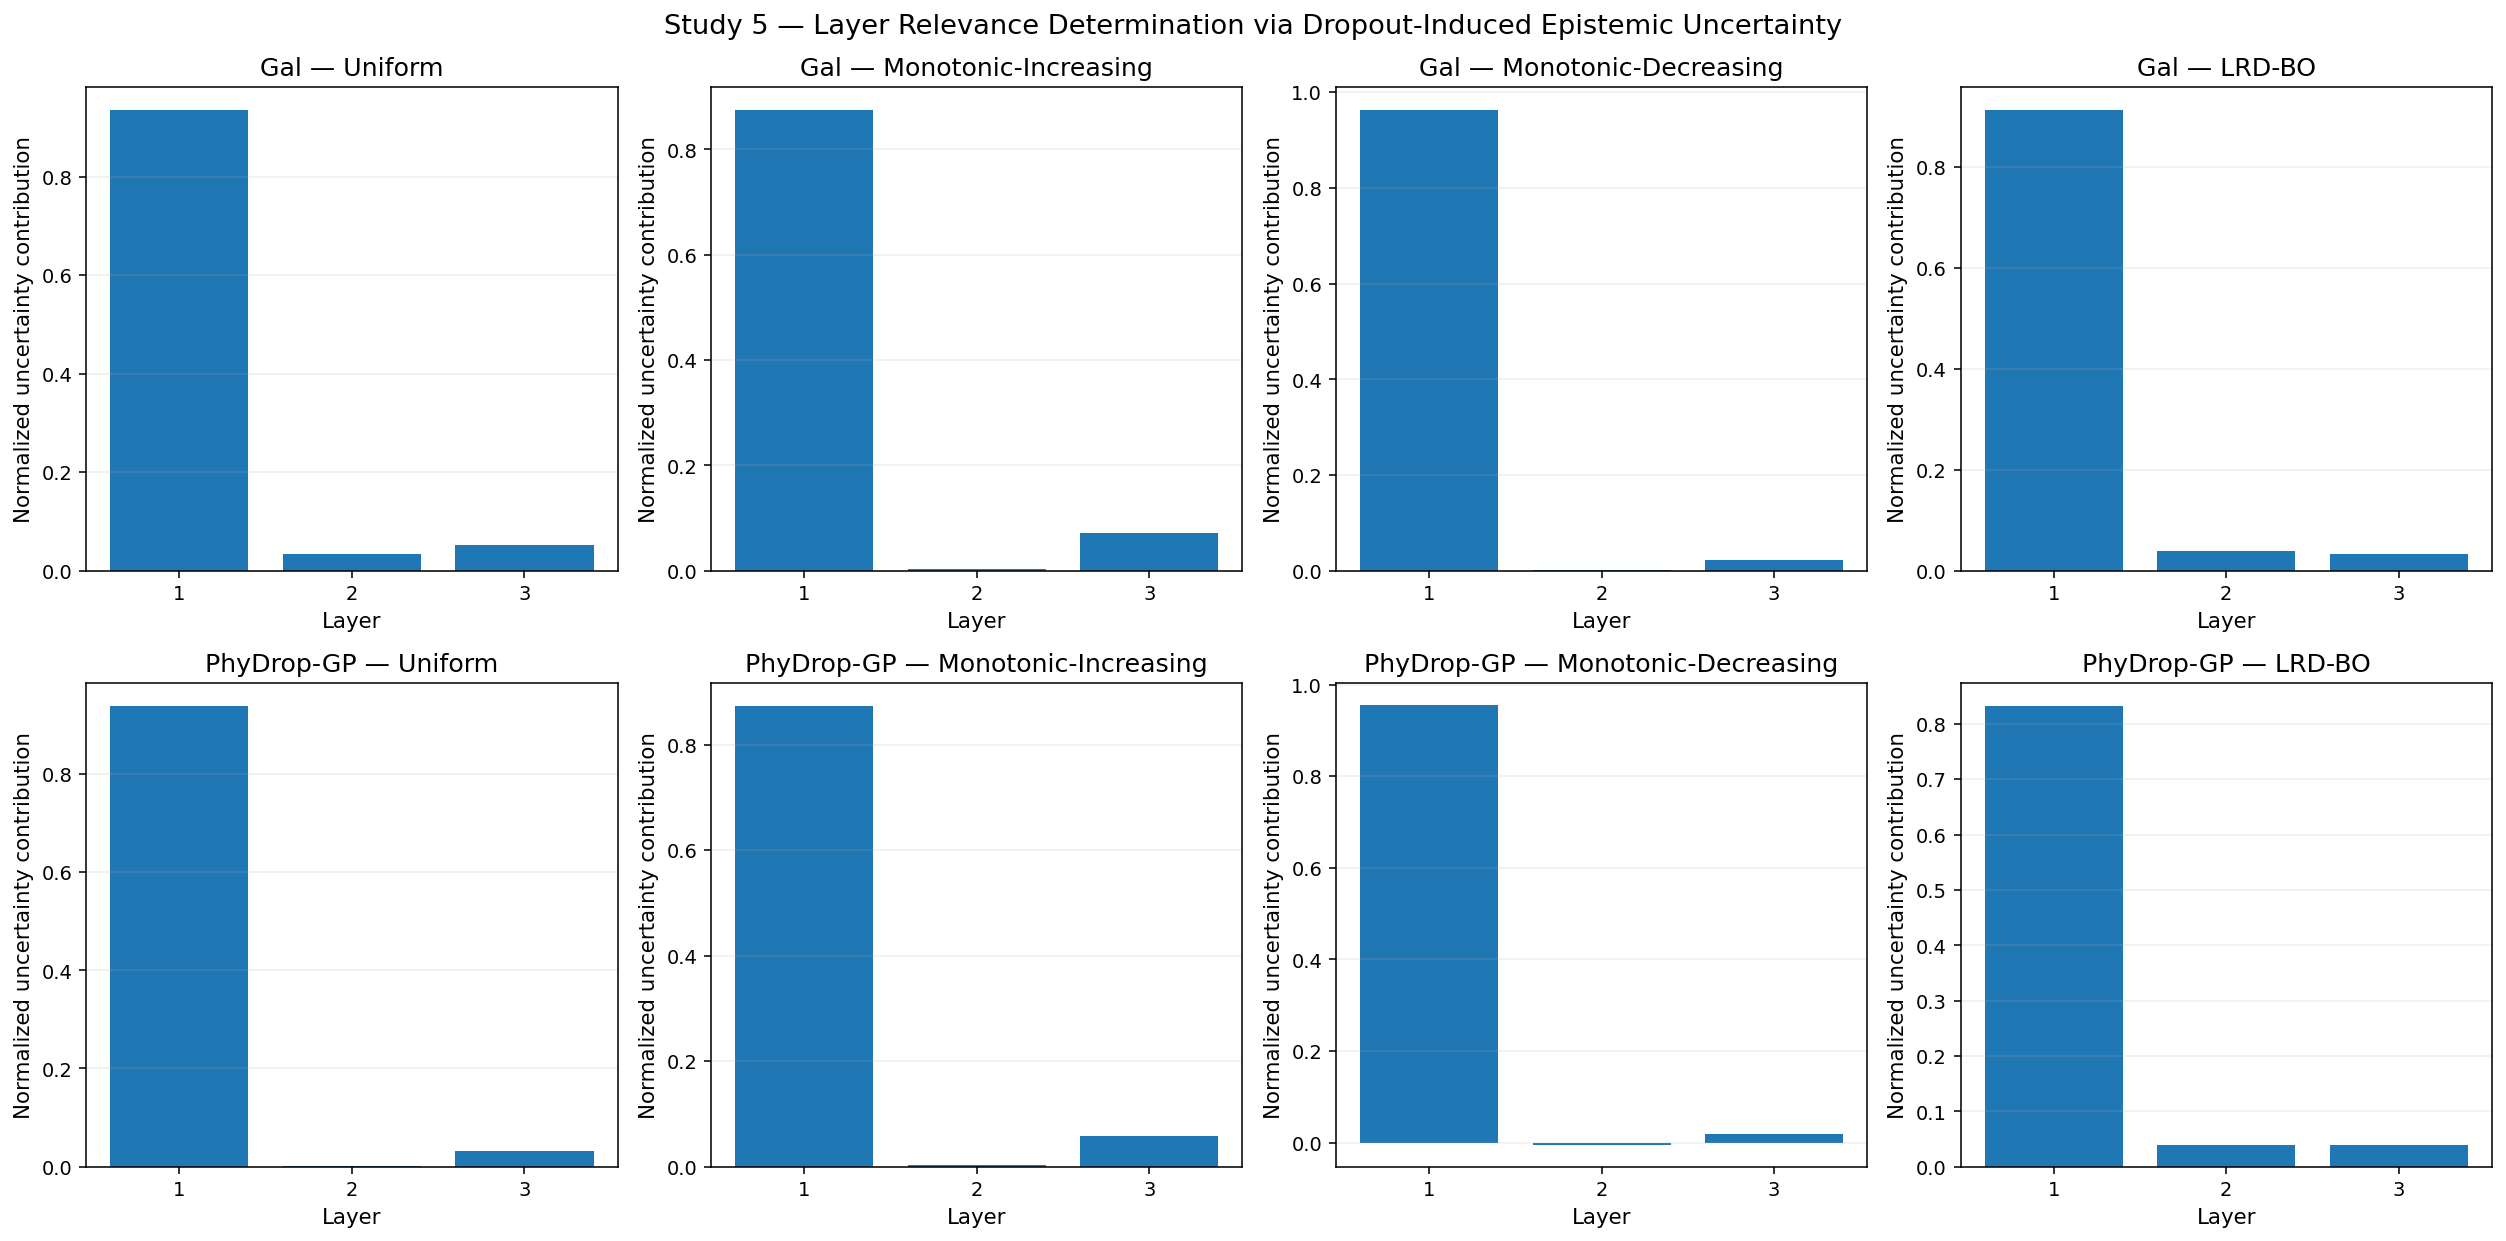

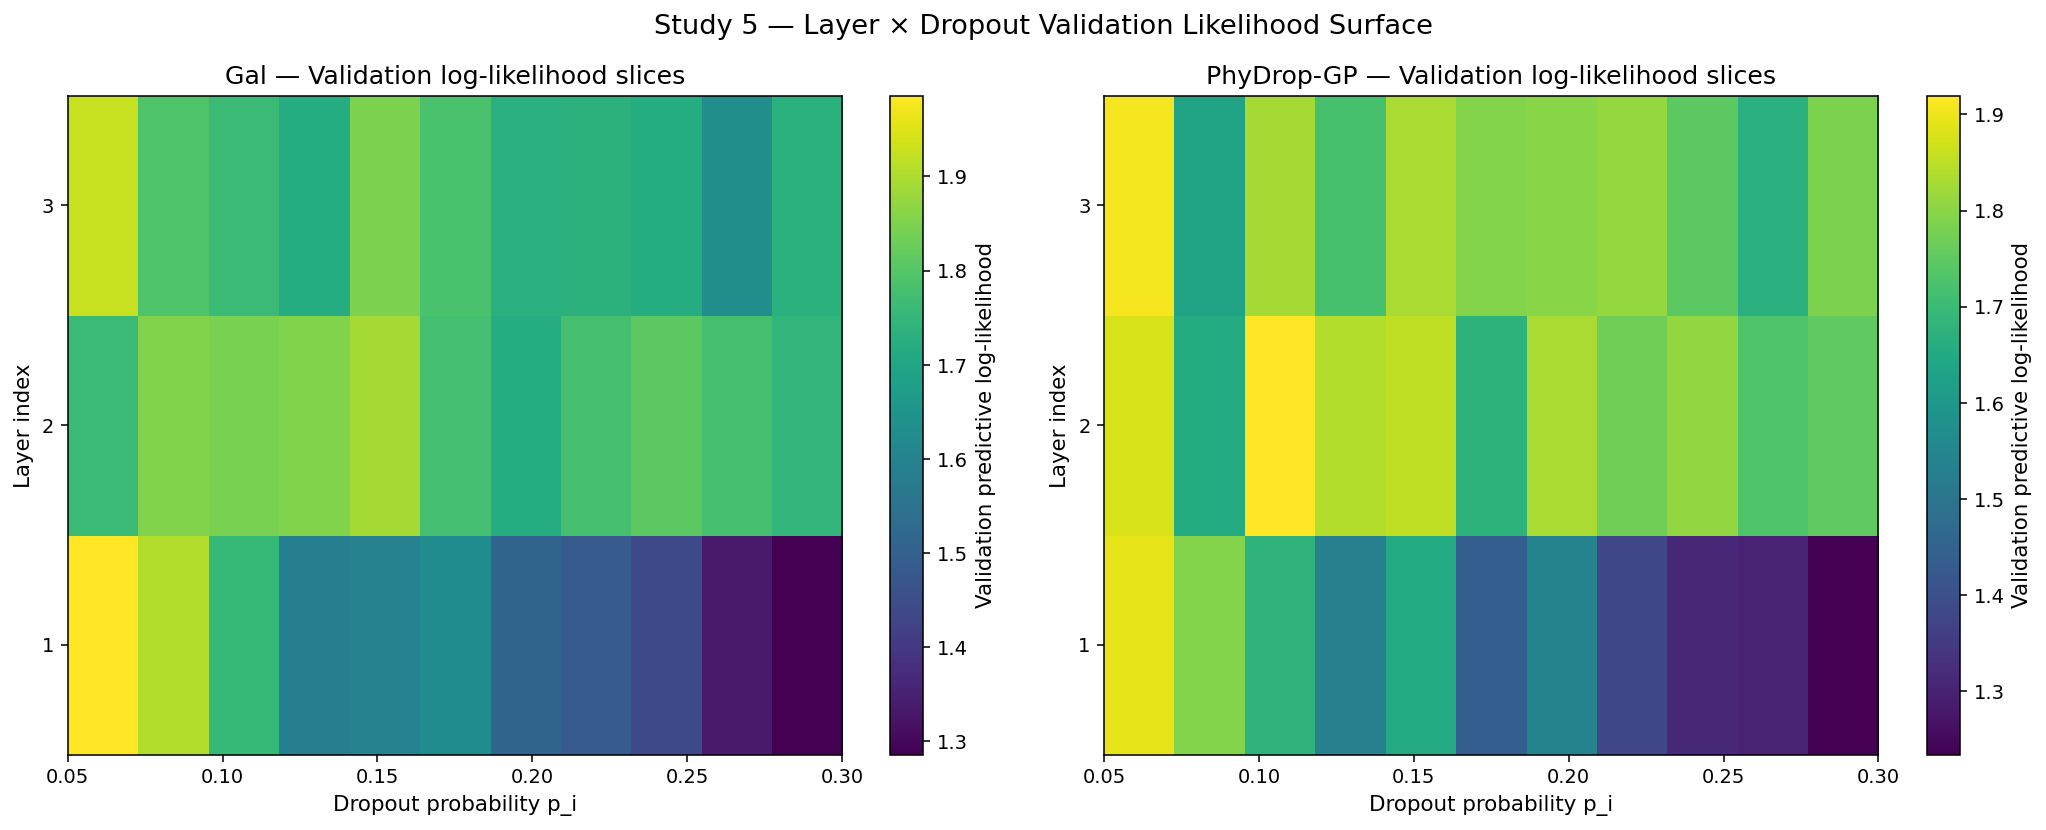

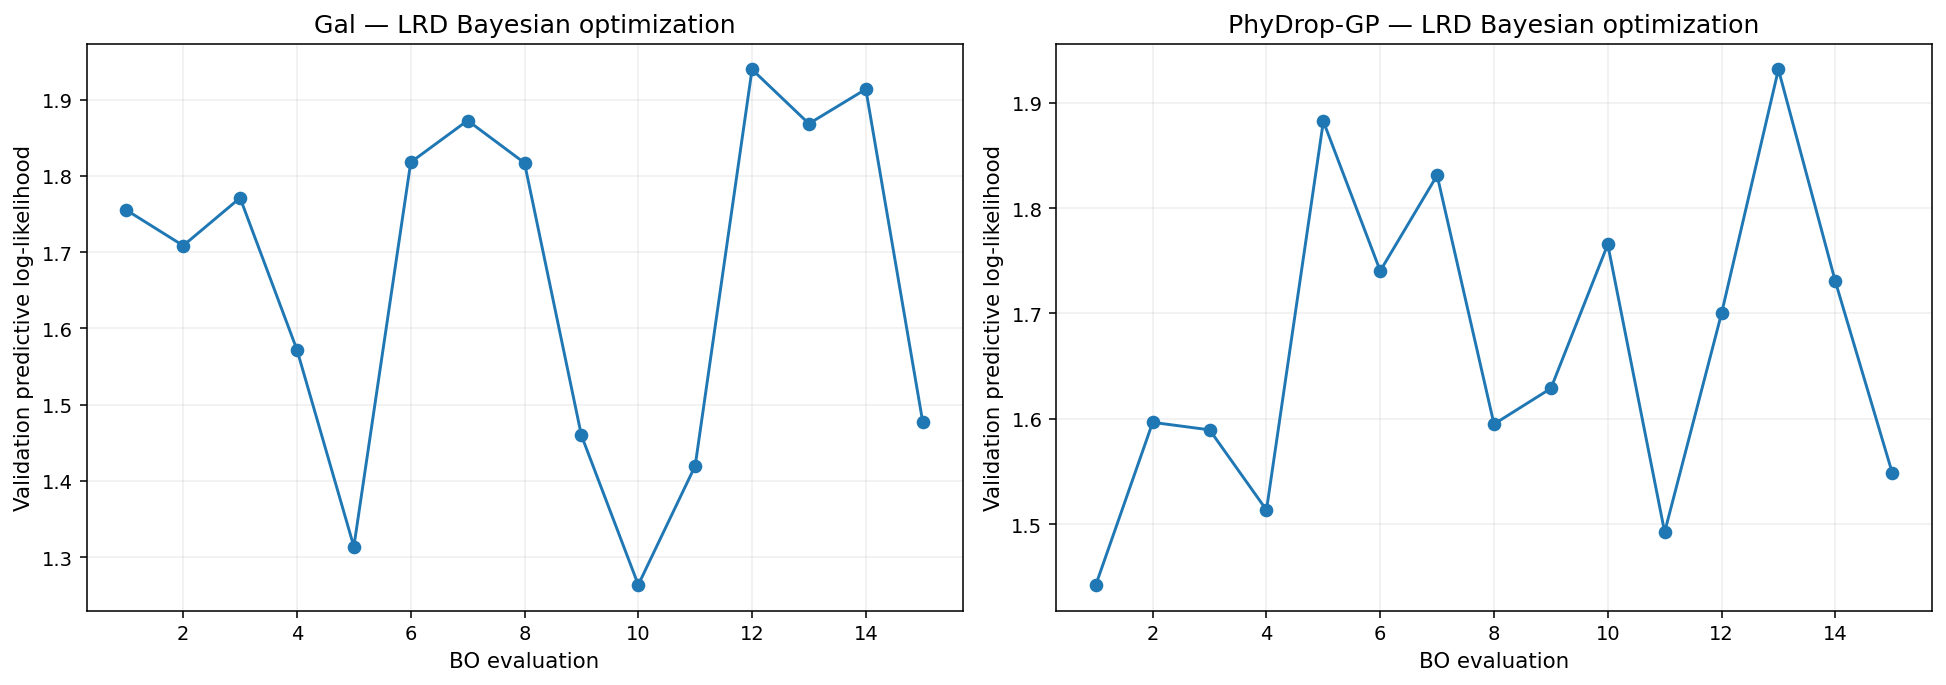

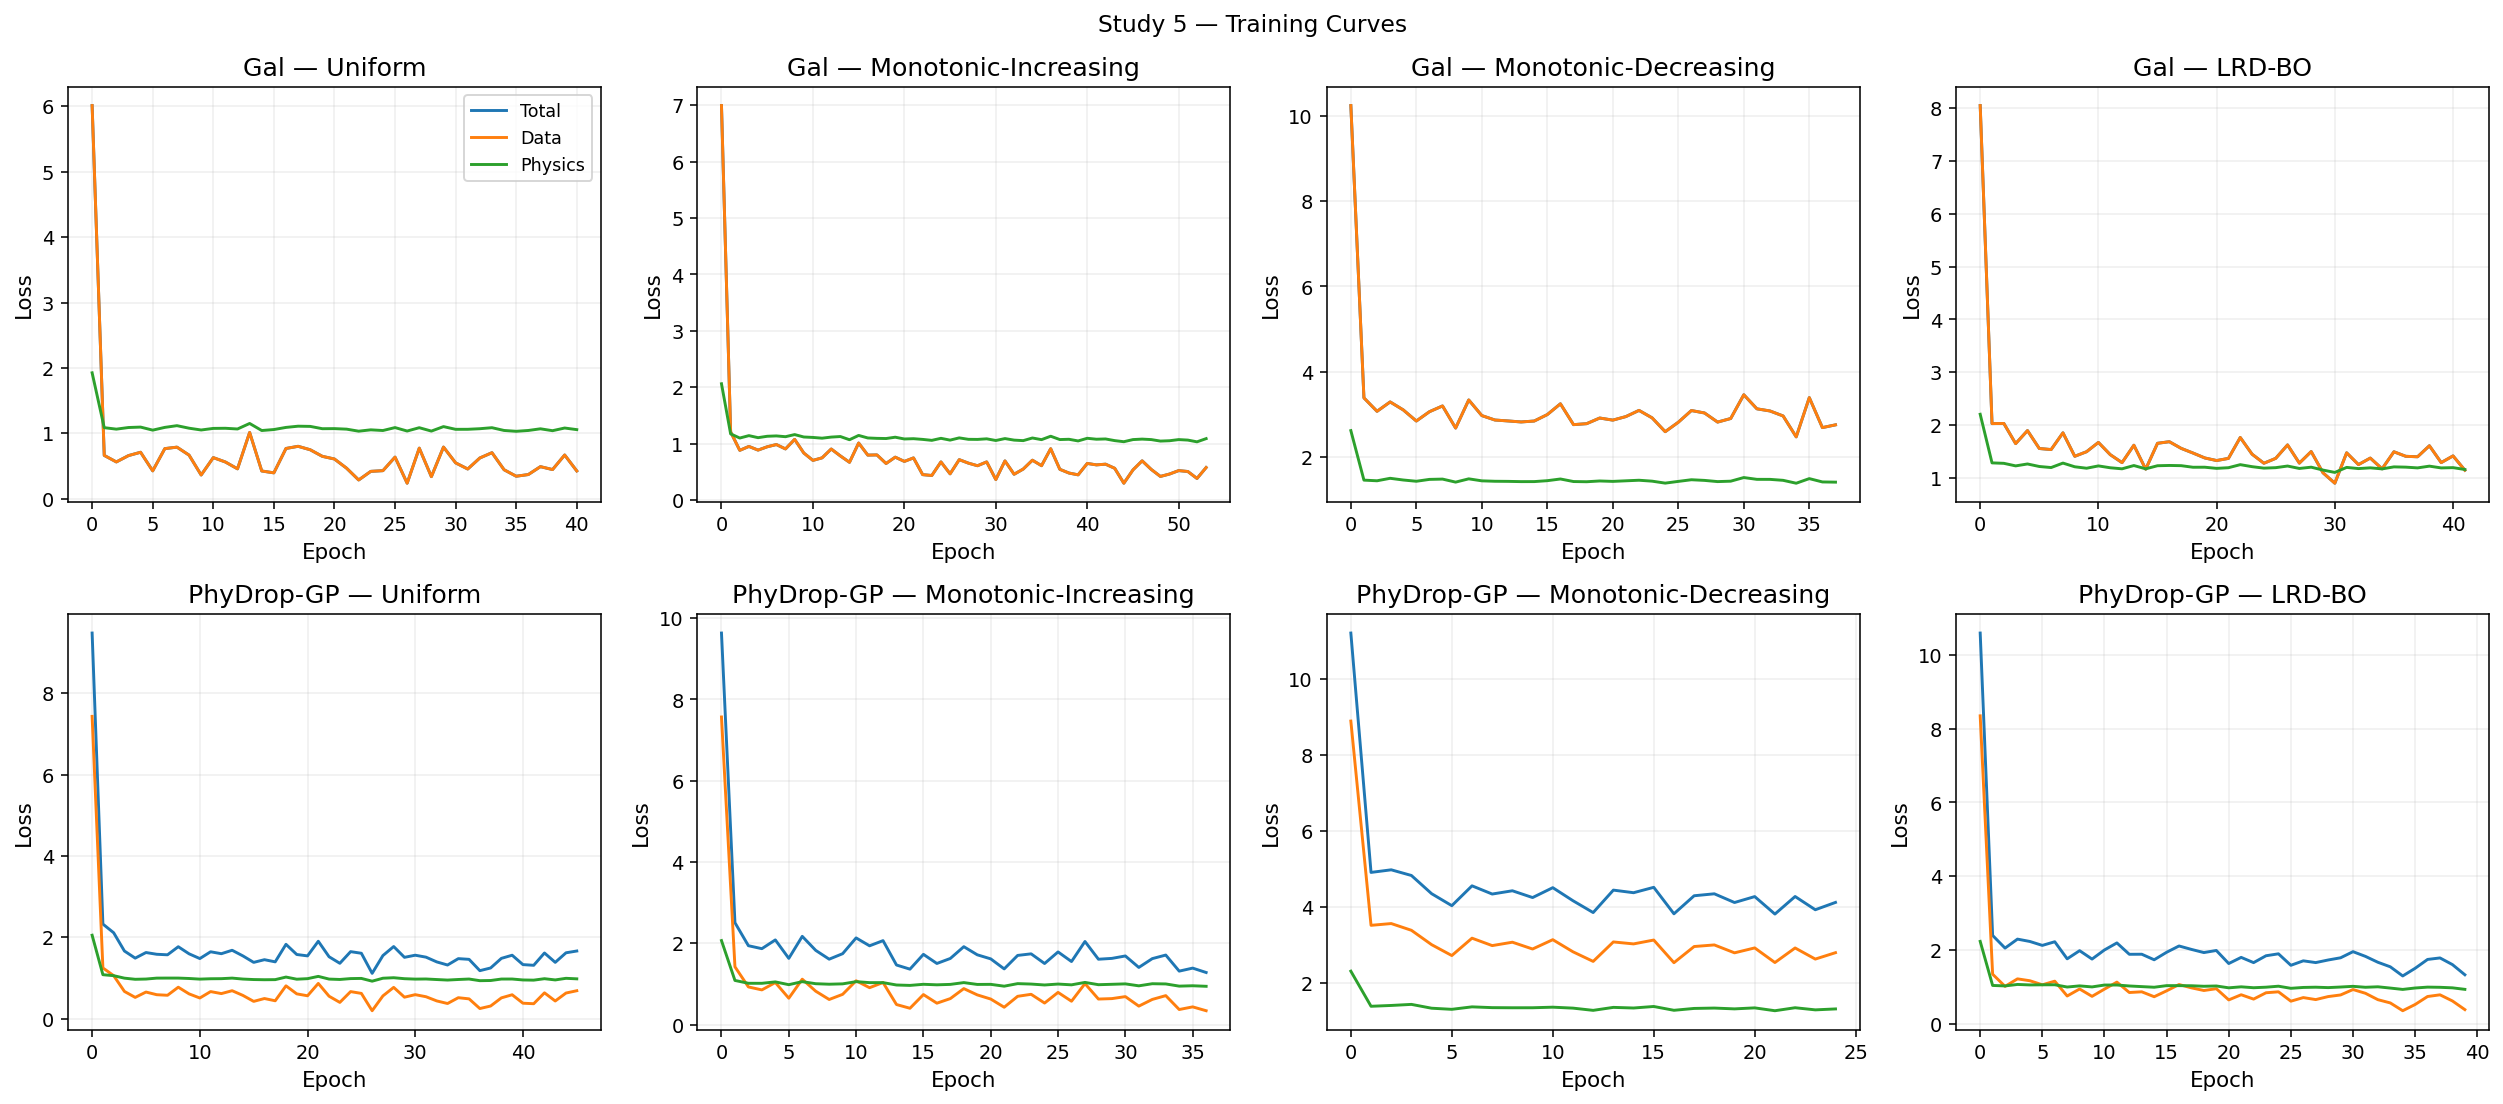


GAL VS PHYDROP DIRECT COMPARISON
       Configuration  Gal_E1_LL  PhyDrop_E1_LL  Gal_E1_RMSE  PhyDrop_E1_RMSE  Gal_E2_LL  PhyDrop_E2_LL  Gal_E2_RMSE  PhyDrop_E2_RMSE  Gal_E2_Physics  PhyDrop_E2_Physics
             Uniform   2.092586       2.030413     0.085758         0.083786  -5.661266      -3.311431     0.308042         0.273100        0.267925            0.231612
Monotonic-Increasing   2.047945       1.905664     0.089568         0.088061  -6.412202      -4.837508     0.343018         0.318218        0.293896            0.267232
Monotonic-Decreasing   1.856666       1.801565     0.108599         0.108867  -7.392768      -7.650512     0.404027         0.413033        0.327695            0.333889
              LRD-BO   1.955610       1.901717     0.092520         0.083722  -6.238213      -3.701330     0.359826         0.316168        0.293178            0.254140

BEST CONFIGURATION SUMMARY
     Model Best_Configuration       p1       p2       p3    E1_LL  E1_RMSE     E2_LL  E2_RMSE

In [ ]:
import os
import math
import random
import warnings
from dataclasses import dataclass
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern,ConstantKernel
from sklearn.metrics import mean_squared_error,mean_absolute_error
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

SEED=2026

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("ADDITIONAL STUDY 5 — LAYER RELEVANCE DETERMINATION")
print("Device:",DEVICE)

INPUT_DIM=2
HIDDEN_DIM=64
N_HIDDEN_LAYERS=3
OUTPUT_DIM=2
DROPOUT_MIN=0.05
DROPOUT_MAX=0.30
UNIFORM_CANDIDATES=[0.05,0.10,0.20,0.30]
OBS_NOISE_STD=0.08
TAU_DATA=1.0/(OBS_NOISE_STD**2)
TAU_H=10.0
LAMBDA_H_GAL=0.0
LAMBDA_H_PHYDROP=1.0
LENGTHSCALE=1.0
WEIGHT_REG_FACTOR=1.0
BATCH_SIZE=128
TUNE_EPOCHS=40
FINAL_EPOCHS=120
LEARNING_RATE=1e-3
WEIGHT_DECAY_OUTPUT=1e-5
EARLY_STOPPING_PATIENCE=10
TUNE_MC_SAMPLES=15
FINAL_MC_SAMPLES=100
DIAGNOSTIC_MC_SAMPLES=100
BO_INITIAL_POINTS=5
BO_ITERATIONS=10
BO_RANDOM_POOL=500
SURFACE_POINTS=11
SURFACE_EPOCHS=30
N_TOTAL=3600
N_TRAIN=2200
N_VAL=600
N_E1_TEST=400
N_E2_TEST=400
TRAIN_NOISE_STD=OBS_NOISE_STD
VAL_NOISE_STD=OBS_NOISE_STD
TEST_NOISE_STD=OBS_NOISE_STD
RESULT_DIR="/content/Study5_LRD_Gal_vs_PhyDrop"
os.makedirs(RESULT_DIR,exist_ok=True)
EPS=1e-12

def true_dynamics(x):
    q=x[...,0]
    p=x[...,1]
    dqdt=p
    dpdt=-q
    return np.stack([dqdt,dpdt],axis=-1)

def true_hamiltonian(x):
    q=x[...,0]
    p=x[...,1]
    return 0.5*(q**2+p**2)

print("\nGENERATING HAMILTONIAN SIMULATION")

rng=np.random.default_rng(SEED)

def sample_states(n,amp_low,amp_high,noise_std):
    amplitude=rng.uniform(amp_low,amp_high,size=n)
    theta=rng.uniform(0.0,2.0*np.pi,size=n)
    q=amplitude*np.cos(theta)
    p=amplitude*np.sin(theta)
    X=np.column_stack([q,p]).astype(np.float32)
    Y_clean=true_dynamics(X).astype(np.float32)
    Y=(Y_clean+rng.normal(0.0,noise_std,size=Y_clean.shape)).astype(np.float32)
    return X,Y,Y_clean

X_train,Y_train,Y_train_clean=sample_states(N_TRAIN,0.4,1.2,TRAIN_NOISE_STD)
X_val,Y_val,Y_val_clean=sample_states(N_VAL,0.4,1.2,VAL_NOISE_STD)
X_e1,Y_e1,Y_e1_clean=sample_states(N_E1_TEST,0.5,1.1,TEST_NOISE_STD)
X_e2,Y_e2,Y_e2_clean=sample_states(N_E2_TEST,1.4,2.0,TEST_NOISE_STD)

print("Training:",X_train.shape)
print("Validation:",X_val.shape)
print("E1 test:",X_e1.shape)
print("E2 test:",X_e2.shape)

X_mean=X_train.mean(axis=0).astype(np.float32)
X_std=X_train.std(axis=0).astype(np.float32)+1e-8

def normalize_X(X):
    return ((X-X_mean)/X_std).astype(np.float32)

X_train_n=normalize_X(X_train)
X_val_n=normalize_X(X_val)
X_e1_n=normalize_X(X_e1)
X_e2_n=normalize_X(X_e2)

# Dropout is kept active during stochastic inference for epistemic uncertainty.
class AlwaysOnDropout(nn.Module):
    def __init__(self,p):
        super().__init__()
        self.p=float(p)
        self.frozen=False

    def set_p(self,p):
        self.p=float(p)

    def set_frozen(self,frozen):
        self.frozen=bool(frozen)

    def forward(self,x):
        if self.frozen:
            return x
        if not self.training:
            return x
        keep_prob=1.0-self.p
        if keep_prob<=0.0:
            return torch.zeros_like(x)
        mask=torch.bernoulli(torch.full_like(x,keep_prob))
        return x*mask/keep_prob

# Three-layer network with independently tunable dropout probabilities.
class LRDDynamicsNet(nn.Module):
    def __init__(self,dropout_rates,hidden_dim=64):
        super().__init__()
        if len(dropout_rates)!=N_HIDDEN_LAYERS:
            raise ValueError("dropout_rates must contain exactly "+f"{N_HIDDEN_LAYERS} values.")
        self.dropout_rates=np.asarray(dropout_rates,dtype=np.float64)
        self.dropout_layers=nn.ModuleList([
            AlwaysOnDropout(dropout_rates[0]),
            AlwaysOnDropout(dropout_rates[1]),
            AlwaysOnDropout(dropout_rates[2])
        ])
        self.fc1=nn.Linear(INPUT_DIM,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,hidden_dim)
        self.output=nn.Linear(hidden_dim,OUTPUT_DIM)
        self.activation=nn.Tanh()

    def set_dropout_rates(self,dropout_rates):
        dropout_rates=np.asarray(dropout_rates,dtype=np.float64)
        if len(dropout_rates)!=3:
            raise ValueError("Expected three dropout rates.")
        self.dropout_rates=dropout_rates.copy()
        for layer,p in zip(self.dropout_layers,dropout_rates):
            layer.set_p(float(p))

    def freeze_layer(self,layer_index):
        for layer in self.dropout_layers:
            layer.set_frozen(False)
        if layer_index is not None:
            self.dropout_layers[layer_index].set_frozen(True)

    def freeze_all(self):
        for layer in self.dropout_layers:
            layer.set_frozen(True)

    def stochastic_all(self):
        for layer in self.dropout_layers:
            layer.set_frozen(False)

    def forward(self,x):
        x=self.dropout_layers[0](x)
        x=self.fc1(x)
        x=self.activation(x)
        x=self.dropout_layers[1](x)
        x=self.fc2(x)
        x=self.activation(x)
        x=self.dropout_layers[2](x)
        x=self.fc3(x)
        x=self.activation(x)
        x=self.output(x)
        return x

    # Gal-consistent layer-wise KL approximation.
    def kl_regularization(self,N):
        lambda_i=[
            float(d)*LENGTHSCALE**2/(2.0*N*TAU_DATA)
            for d in self.dropout_rates
        ]
        weights=[self.fc1.weight,self.fc2.weight,self.fc3.weight]
        reg=torch.tensor(0.0,device=weights[0].device)
        for lam,W in zip(lambda_i,weights):
            reg=reg+lam*torch.sum(W**2)
        reg=reg+WEIGHT_DECAY_OUTPUT*torch.sum(self.output.weight**2)
        return reg

def data_nll_torch(prediction,target):
    variance=OBS_NOISE_STD**2
    return torch.mean(
        0.5*((target-prediction)**2/variance)
        +np.log(OBS_NOISE_STD*np.sqrt(2.0*np.pi))
    )

# Harmonic oscillator residual evaluated against the physical state variables.
def harmonic_physics_residual(X_raw,prediction):
    q=X_raw[:,0]
    p=X_raw[:,1]
    target_dq=p
    target_dp=-q
    target=torch.stack([target_dq,target_dp],dim=1)
    residual=prediction-target
    return residual

def physics_nll_torch(residual):
    return 0.5*TAU_H*torch.mean(residual**2)

@dataclass
class TrainResult:
    model:object
    train_history:list
    val_ll:float
    val_rmse:float
    val_physics:float

def make_loader(X,Y,batch_size=BATCH_SIZE):
    X_tensor=torch.tensor(X,dtype=torch.float32)
    Y_tensor=torch.tensor(Y,dtype=torch.float32)
    return DataLoader(
        TensorDataset(X_tensor,Y_tensor),
        batch_size=batch_size,
        shuffle=True
    )

def train_model(dropout_rates,lambda_h,epochs,seed,use_validation_selection=True):
    set_seed(seed)
    model=LRDDynamicsNet(dropout_rates=dropout_rates,hidden_dim=HIDDEN_DIM).to(DEVICE)
    optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
    loader=make_loader(X_train_n,Y_train)
    history=[]
    best_state=None
    best_val_ll=-np.inf
    patience_count=0

    for epoch in range(epochs):
        model.train()
        model.stochastic_all()
        running_data=0.0
        running_phys=0.0
        running_total=0.0

        for X_batch,Y_batch in loader:
            X_batch=X_batch.to(DEVICE)
            Y_batch=Y_batch.to(DEVICE)
            optimizer.zero_grad()

            pred=model(X_batch)
            data_loss=data_nll_torch(pred,Y_batch)
            residual=harmonic_physics_residual(X_batch,pred)
            phys_loss=physics_nll_torch(residual)
            kl_loss=model.kl_regularization(N=len(X_train_n))
            total_loss=data_loss+lambda_h*phys_loss+kl_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            optimizer.step()

            running_data+=data_loss.item()
            running_phys+=phys_loss.item()
            running_total+=total_loss.item()

        epoch_record={
            "data":running_data/len(loader),
            "physics":running_phys/len(loader),
            "total":running_total/len(loader)
        }
        history.append(epoch_record)

        if use_validation_selection:
            val_pred=mc_predict(model,X_val_n,mc_samples=TUNE_MC_SAMPLES,raw_X=X_val)
            val_ll=predictive_loglikelihood(Y_val,val_pred["mc_means"])

            if val_ll>best_val_ll:
                best_val_ll=val_ll
                best_state={
                    k:v.detach().cpu().clone()
                    for k,v in model.state_dict().items()
                }
                patience_count=0
            else:
                patience_count+=1
                if patience_count>=EARLY_STOPPING_PATIENCE:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_pred=mc_predict(model,X_val_n,mc_samples=FINAL_MC_SAMPLES,raw_X=X_val)
    final_val_ll=predictive_loglikelihood(Y_val,val_pred["mc_means"])
    val_mean=val_pred["mean"]
    final_val_rmse=np.sqrt(mean_squared_error(Y_val,val_mean))
    val_physics=physics_residual_norm(model,X_val_n,X_val)

    return TrainResult(
        model=model,
        train_history=history,
        val_ll=float(final_val_ll),
        val_rmse=float(final_val_rmse),
        val_physics=float(val_physics)
    )

def mc_predict(model,X_normalized,mc_samples=100,raw_X=None,frozen_layer=None,deterministic=False):
    X_tensor=torch.tensor(X_normalized,dtype=torch.float32)
    all_samples=[]
    model.train()

    if deterministic:
        model.freeze_all()
    else:
        model.freeze_layer(frozen_layer)

    with torch.no_grad():
        for start in range(0,len(X_tensor),512):
            batch=X_tensor[start:start+512].to(DEVICE)
            batch_samples=[]

            for _ in range(mc_samples):
                prediction=model(batch)
                batch_samples.append(prediction.cpu().numpy())

            batch_samples=np.stack(batch_samples,axis=0)
            all_samples.append(batch_samples)

    samples=np.concatenate(all_samples,axis=1)
    model.stochastic_all()

    return {
        "mc_means":samples,
        "mean":np.mean(samples,axis=0),
        "epistemic_variance":np.var(samples,axis=0)
    }

def predictive_loglikelihood(y,mc_means):
    y=np.asarray(y)
    if y.ndim==1:
        y=y[:,None]

    variance=OBS_NOISE_STD**2
    residual=y[None,:,:]-mc_means
    log_component=(-0.5*(residual**2/variance)-0.5*np.log(2.0*np.pi*variance))
    log_component=np.sum(log_component,axis=-1)
    predictive=logsumexp(log_component,axis=0)-np.log(mc_means.shape[0])
    return float(np.mean(predictive))

def physics_residual_norm(model,X_normalized,X_raw):
    model.eval()
    model.freeze_all()
    X_tensor=torch.tensor(X_normalized,dtype=torch.float32,device=DEVICE)

    with torch.no_grad():
        pred=model(X_tensor)
        residual=harmonic_physics_residual(
            torch.tensor(X_raw,dtype=torch.float32,device=DEVICE),
            pred
        )

    norm=torch.sqrt(torch.mean(residual**2))
    model.stochastic_all()
    return float(norm.cpu().item())

def evaluate_model(model,X,X_raw,Y):
    prediction=mc_predict(model,X,mc_samples=FINAL_MC_SAMPLES,raw_X=X_raw)
    ll=predictive_loglikelihood(Y,prediction["mc_means"])
    mean_prediction=prediction["mean"]
    rmse=np.sqrt(mean_squared_error(Y,mean_prediction))
    mae=mean_absolute_error(Y,mean_prediction)
    phys=physics_residual_norm(model,X,X_raw)

    return {
        "LL":float(ll),
        "RMSE":float(rmse),
        "MAE":float(mae),
        "Physics_Residual":float(phys),
        "MC":prediction
    }

evaluation_cache={}

def config_key(rates):
    return tuple(np.round(np.asarray(rates),6))

def train_candidate(rates,lambda_h,model_label,candidate_id,epochs=TUNE_EPOCHS):
    rates=np.asarray(rates,dtype=np.float64)
    key=(model_label,config_key(rates),int(epochs))

    if key in evaluation_cache:
        return evaluation_cache[key]

    print(f"\nTraining candidate {model_label} rates={np.round(rates,4)}")

    result=train_model(
        dropout_rates=rates,
        lambda_h=lambda_h,
        epochs=epochs,
        seed=SEED+candidate_id+int(1000*np.sum(rates)),
        use_validation_selection=True
    )

    evaluation_cache[key]=result
    return result

def tune_uniform(lambda_h,model_label,candidate_counter):
    rows=[]
    best_result=None
    best_rate=None
    best_ll=-np.inf

    for p in UNIFORM_CANDIDATES:
        rates=np.array([p,p,p],dtype=np.float64)

        result=train_candidate(
            rates,
            lambda_h,
            model_label,
            candidate_counter[0]
        )
        candidate_counter[0]+=1

        rows.append({
            "Config":"Uniform",
            "Rates":rates.copy(),
            "Val_LL":result.val_ll,
            "Val_RMSE":result.val_rmse,
            "Val_Physics":result.val_physics
        })

        if result.val_ll>best_ll:
            best_ll=result.val_ll
            best_rate=rates.copy()
            best_result=result

    return best_rate,best_result,rows

def tune_monotonic(lambda_h,model_label,increasing,candidate_counter):
    rows=[]
    best_result=None
    best_rates=None
    best_ll=-np.inf

    grid_values=np.linspace(DROPOUT_MIN,DROPOUT_MAX,4)
    candidates=[]

    for p_min in grid_values:
        for p_max in grid_values:
            if p_max<p_min:
                continue
            if abs(p_max-p_min)<1e-10:
                continue

            alpha=np.array([0.0,0.5,1.0])
            if not increasing:
                alpha=alpha[::-1]

            rates=p_min+alpha*(p_max-p_min)
            candidates.append(rates)

    for rates in candidates:
        label="Monotonic-Increasing" if increasing else "Monotonic-Decreasing"

        result=train_candidate(
            rates,
            lambda_h,
            model_label,
            candidate_counter[0]
        )
        candidate_counter[0]+=1

        rows.append({
            "Config":label,
            "Rates":rates.copy(),
            "Val_LL":result.val_ll,
            "Val_RMSE":result.val_rmse,
            "Val_Physics":result.val_physics
        })

        if result.val_ll>best_ll:
            best_ll=result.val_ll
            best_rates=rates.copy()
            best_result=result

    return best_rates,best_result,rows

def expected_improvement(X_candidates,X_observed,y_observed,gp):
    mu,sigma=gp.predict(X_candidates,return_std=True)
    sigma=np.maximum(sigma,1e-12)
    best=np.max(y_observed)
    improvement=mu-best-0.01
    Z=improvement/sigma
    ei=improvement*norm.cdf(Z)+sigma*norm.pdf(Z)
    return ei

# Bayesian optimization over the layer-wise dropout vector.
def bo_optimize(lambda_h,model_label,candidate_counter):
    observations=[]
    best_rates=None
    best_result=None
    best_ll=-np.inf

    initial_points=rng.uniform(
        DROPOUT_MIN,
        DROPOUT_MAX,
        size=(BO_INITIAL_POINTS,N_HIDDEN_LAYERS)
    )

    for rates in initial_points:
        result=train_candidate(
            rates,
            lambda_h,
            model_label,
            candidate_counter[0]
        )
        candidate_counter[0]+=1

        observations.append({
            "rates":rates.copy(),
            "ll":result.val_ll,
            "result":result
        })

        if result.val_ll>best_ll:
            best_ll=result.val_ll
            best_rates=rates.copy()
            best_result=result

    for iteration in range(BO_ITERATIONS):
        X_observed=np.stack([item["rates"] for item in observations])
        y_observed=np.array([item["ll"] for item in observations])

        kernel=(
            ConstantKernel(1.0,(1e-3,1e3))
            *Matern(
                length_scale=np.ones(N_HIDDEN_LAYERS),
                nu=2.5
            )
        )

        gp=GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-5,
            normalize_y=True,
            random_state=SEED
        )

        gp.fit(X_observed,y_observed)

        candidate_pool=rng.uniform(
            DROPOUT_MIN,
            DROPOUT_MAX,
            size=(BO_RANDOM_POOL,N_HIDDEN_LAYERS)
        )

        ei=expected_improvement(
            candidate_pool,
            X_observed,
            y_observed,
            gp
        )

        order=np.argsort(-ei)
        next_rates=None

        observed_keys={config_key(x) for x in X_observed}

        for idx in order:
            candidate=candidate_pool[idx]
            if config_key(candidate) not in observed_keys:
                next_rates=candidate
                break

        if next_rates is None:
            next_rates=rng.uniform(
                DROPOUT_MIN,
                DROPOUT_MAX,
                size=N_HIDDEN_LAYERS
            )

        print(f"\nBO iteration {iteration+1}/{BO_ITERATIONS} candidate={np.round(next_rates,4)}")

        result=train_candidate(
            next_rates,
            lambda_h,
            model_label,
            candidate_counter[0]
        )
        candidate_counter[0]+=1

        observations.append({
            "rates":next_rates.copy(),
            "ll":result.val_ll,
            "result":result
        })

        if result.val_ll>best_ll:
            best_ll=result.val_ll
            best_rates=next_rates.copy()
            best_result=result

    bo_history=pd.DataFrame([
        {
            "Iteration":i+1,
            "p1":item["rates"][0],
            "p2":item["rates"][1],
            "p3":item["rates"][2],
            "Validation_LL":item["ll"]
        }
        for i,item in enumerate(observations)
    ])

    return best_rates,best_result,bo_history

all_tuning_rows=[]
best_configs={}
bo_histories={}
candidate_counter=[0]

for model_label,lambda_h in [
    ("Gal",LAMBDA_H_GAL),
    ("PhyDrop-GP",LAMBDA_H_PHYDROP)
]:
    print(f"\nTUNING {model_label}")

    uniform_rates,uniform_result,uniform_rows=tune_uniform(
        lambda_h,
        model_label,
        candidate_counter
    )

    all_tuning_rows.extend([
        {**row,"Model":model_label}
        for row in uniform_rows
    ])

    best_configs[(model_label,"Uniform")]={
        "rates":uniform_rates,
        "result":uniform_result
    }

    increasing_rates,increasing_result,increasing_rows=tune_monotonic(
        lambda_h,
        model_label,
        increasing=True,
        candidate_counter=candidate_counter
    )

    all_tuning_rows.extend([
        {**row,"Model":model_label}
        for row in increasing_rows
    ])

    best_configs[(model_label,"Monotonic-Increasing")]={
        "rates":increasing_rates,
        "result":increasing_result
    }

    decreasing_rates,decreasing_result,decreasing_rows=tune_monotonic(
        lambda_h,
        model_label,
        increasing=False,
        candidate_counter=candidate_counter
    )

    all_tuning_rows.extend([
        {**row,"Model":model_label}
        for row in decreasing_rows
    ])

    best_configs[(model_label,"Monotonic-Decreasing")]={
        "rates":decreasing_rates,
        "result":decreasing_result
    }

    bo_rates,bo_result,bo_history=bo_optimize(
        lambda_h,
        model_label,
        candidate_counter
    )

    bo_histories[model_label]=bo_history

    best_configs[(model_label,"LRD-BO")]={
        "rates":bo_rates,
        "result":bo_result
    }

    all_tuning_rows.append({
        "Config":"LRD-BO",
        "Rates":bo_rates,
        "Val_LL":bo_result.val_ll,
        "Val_RMSE":bo_result.val_rmse,
        "Val_Physics":bo_result.val_physics,
        "Model":model_label
    })

print("\nBEST LRD CONFIGURATIONS")

for key,info in best_configs.items():
    model_label,config_name=key
    print(f"\n{model_label} — {config_name}")
    print("Dropout rates:",np.round(info["rates"],5))
    print("Validation LL:",f"{info['result'].val_ll:.6f}")
    print("Validation RMSE:",f"{info['result'].val_rmse:.6f}")
    print("Validation physics:",f"{info['result'].val_physics:.6f}")

final_models={}
final_training_histories={}

configuration_order=[
    "Uniform",
    "Monotonic-Increasing",
    "Monotonic-Decreasing",
    "LRD-BO"
]

for model_label,lambda_h in [
    ("Gal",LAMBDA_H_GAL),
    ("PhyDrop-GP",LAMBDA_H_PHYDROP)
]:
    for config_name in configuration_order:
        rates=best_configs[(model_label,config_name)]["rates"]

        print(f"\nFINAL TRAINING: {model_label} / {config_name}")
        print("Dropout:",np.round(rates,5))

        final_result=train_model(
            dropout_rates=rates,
            lambda_h=lambda_h,
            epochs=FINAL_EPOCHS,
            seed=SEED+10000+len(final_models),
            use_validation_selection=True
        )

        final_models[(model_label,config_name)]=final_result.model
        final_training_histories[(model_label,config_name)]=final_result.train_history

final_results_rows=[]

for model_label,lambda_h in [
    ("Gal",LAMBDA_H_GAL),
    ("PhyDrop-GP",LAMBDA_H_PHYDROP)
]:
    for config_name in configuration_order:
        model=final_models[(model_label,config_name)]
        rates=best_configs[(model_label,config_name)]["rates"]

        e1=evaluate_model(model,X_e1_n,X_e1,Y_e1)
        e2=evaluate_model(model,X_e2_n,X_e2,Y_e2)

        final_results_rows.append({
            "Model":model_label,
            "Configuration":config_name,
            "p1":rates[0],
            "p2":rates[1],
            "p3":rates[2],
            "E1_LL":e1["LL"],
            "E1_RMSE":e1["RMSE"],
            "E1_MAE":e1["MAE"],
            "E1_Physics_Residual":e1["Physics_Residual"],
            "E2_LL":e2["LL"],
            "E2_RMSE":e2["RMSE"],
            "E2_MAE":e2["MAE"],
            "E2_Physics_Residual":e2["Physics_Residual"]
        })

final_results_df=pd.DataFrame(final_results_rows)

print("\nSTUDY 5 — FINAL RESULTS")
print(final_results_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))

uncertainty_profiles=[]

for model_label in ["Gal","PhyDrop-GP"]:
    for config_name in configuration_order:
        model=final_models[(model_label,config_name)]
        rates=best_configs[(model_label,config_name)]["rates"]

        X_diag=np.vstack([X_e1_n,X_e2_n])
        X_diag_raw=np.vstack([X_e1,X_e2])

        full_prediction=mc_predict(
            model,
            X_diag,
            mc_samples=DIAGNOSTIC_MC_SAMPLES,
            raw_X=X_diag_raw,
            frozen_layer=None,
            deterministic=False
        )

        full_variance=full_prediction["epistemic_variance"]
        mean_full_variance=np.mean(full_variance)

        deterministic_prediction=mc_predict(
            model,
            X_diag,
            mc_samples=1,
            raw_X=X_diag_raw,
            deterministic=True
        )

        deterministic_variance=np.zeros(X_diag.shape[0],dtype=np.float64)

        denominator=mean_full_variance-np.mean(deterministic_variance)+EPS
        layer_rows=[]

        for layer_index in range(N_HIDDEN_LAYERS):
            frozen_prediction=mc_predict(
                model,
                X_diag,
                mc_samples=DIAGNOSTIC_MC_SAMPLES,
                raw_X=X_diag_raw,
                frozen_layer=layer_index,
                deterministic=False
            )

            frozen_variance=frozen_prediction["epistemic_variance"]
            mean_frozen_variance=np.mean(frozen_variance)
            raw_contribution=mean_full_variance-mean_frozen_variance
            normalized_contribution=raw_contribution/denominator

            layer_rows.append({
                "Model":model_label,
                "Configuration":config_name,
                "Layer":layer_index+1,
                "Dropout":rates[layer_index],
                "Full_Epistemic_Variance":mean_full_variance,
                "Frozen_Epistemic_Variance":mean_frozen_variance,
                "Raw_Contribution":raw_contribution,
                "Normalized_Contribution":normalized_contribution
            })

        uncertainty_profiles.extend(layer_rows)

uncertainty_profiles_df=pd.DataFrame(uncertainty_profiles)

print("\nLAYER UNCERTAINTY CONTRIBUTIONS")
print(uncertainty_profiles_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))

fig,axes=plt.subplots(2,4,figsize=(18,9),squeeze=False)

for row_index,model_label in enumerate(["Gal","PhyDrop-GP"]):
    for col_index,config_name in enumerate(configuration_order):
        ax=axes[row_index,col_index]

        subset=uncertainty_profiles_df[
            (uncertainty_profiles_df["Model"]==model_label)
            &(uncertainty_profiles_df["Configuration"]==config_name)
        ].sort_values("Layer")

        ax.bar(
            subset["Layer"].values,
            subset["Normalized_Contribution"].values
        )

        ax.set_title(f"{model_label} — {config_name}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Normalized uncertainty contribution")
        ax.set_xticks([1,2,3])
        ax.grid(axis="y",alpha=0.2)

plt.suptitle(
    "Study 5 — Layer Relevance Determination via Dropout-Induced Epistemic Uncertainty",
    fontsize=14
)
plt.tight_layout()
plt.show()

surface_rows=[]

for model_label,lambda_h in [
    ("Gal",LAMBDA_H_GAL),
    ("PhyDrop-GP",LAMBDA_H_PHYDROP)
]:
    best_rates=best_configs[(model_label,"LRD-BO")]["rates"]

    for layer_index in range(N_HIDDEN_LAYERS):
        sweep_values=np.linspace(DROPOUT_MIN,DROPOUT_MAX,SURFACE_POINTS)

        for p_value in sweep_values:
            candidate_rates=best_rates.copy()
            candidate_rates[layer_index]=p_value

            result=train_model(
                dropout_rates=candidate_rates,
                lambda_h=lambda_h,
                epochs=SURFACE_EPOCHS,
                seed=SEED+50000+layer_index*100+int(p_value*1000),
                use_validation_selection=False
            )

            validation_prediction=mc_predict(
                result.model,
                X_val_n,
                mc_samples=TUNE_MC_SAMPLES,
                raw_X=X_val
            )

            validation_ll=predictive_loglikelihood(
                Y_val,
                validation_prediction["mc_means"]
            )

            surface_rows.append({
                "Model":model_label,
                "Layer":layer_index+1,
                "p_value":p_value,
                "Validation_LL":validation_ll
            })

surface_df=pd.DataFrame(surface_rows)

fig,axes=plt.subplots(1,2,figsize=(15,6))

for ax,model_label in zip(axes,["Gal","PhyDrop-GP"]):
    subset=surface_df[surface_df["Model"]==model_label]

    matrix=np.full((N_HIDDEN_LAYERS,SURFACE_POINTS),np.nan)
    p_values=np.sort(subset["p_value"].unique())

    for layer in range(N_HIDDEN_LAYERS):
        layer_subset=subset[
            subset["Layer"]==layer+1
        ].sort_values("p_value")

        matrix[layer,:]=layer_subset["Validation_LL"].values

    im=ax.imshow(
        matrix,
        aspect="auto",
        origin="lower",
        extent=[
            p_values.min(),
            p_values.max(),
            0.5,
            N_HIDDEN_LAYERS+0.5
        ]
    )

    ax.set_title(f"{model_label} — Validation log-likelihood slices")
    ax.set_xlabel("Dropout probability p_i")
    ax.set_ylabel("Layer index")
    ax.set_yticks([1,2,3])

    fig.colorbar(
        im,
        ax=ax,
        label="Validation predictive log-likelihood"
    )

plt.suptitle(
    "Study 5 — Layer × Dropout Validation Likelihood Surface",
    fontsize=14
)
plt.tight_layout()
plt.show()

fig,axes=plt.subplots(1,2,figsize=(14,5))

for ax,model_label in zip(axes,["Gal","PhyDrop-GP"]):
    history=bo_histories[model_label]

    ax.plot(
        history["Iteration"],
        history["Validation_LL"],
        marker="o"
    )

    ax.set_title(f"{model_label} — LRD Bayesian optimization")
    ax.set_xlabel("BO evaluation")
    ax.set_ylabel("Validation predictive log-likelihood")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

fig,axes=plt.subplots(2,4,figsize=(18,8))

for row_index,model_label in enumerate(["Gal","PhyDrop-GP"]):
    for col_index,config_name in enumerate(configuration_order):
        ax=axes[row_index,col_index]

        history=final_training_histories[(model_label,config_name)]

        total=[h["total"] for h in history]
        data=[h["data"] for h in history]
        physics=[h["physics"] for h in history]

        ax.plot(total,label="Total")
        ax.plot(data,label="Data")
        ax.plot(physics,label="Physics")

        ax.set_title(f"{model_label} — {config_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.2)

        if row_index==0 and col_index==0:
            ax.legend()

plt.suptitle("Study 5 — Training Curves")
plt.tight_layout()
plt.show()

comparison_rows=[]

for config_name in configuration_order:
    gal_row=final_results_df[
        (final_results_df["Model"]=="Gal")
        &(final_results_df["Configuration"]==config_name)
    ].iloc[0]

    phy_row=final_results_df[
        (final_results_df["Model"]=="PhyDrop-GP")
        &(final_results_df["Configuration"]==config_name)
    ].iloc[0]

    comparison_rows.append({
        "Configuration":config_name,
        "Gal_E1_LL":gal_row["E1_LL"],
        "PhyDrop_E1_LL":phy_row["E1_LL"],
        "Gal_E1_RMSE":gal_row["E1_RMSE"],
        "PhyDrop_E1_RMSE":phy_row["E1_RMSE"],
        "Gal_E2_LL":gal_row["E2_LL"],
        "PhyDrop_E2_LL":phy_row["E2_LL"],
        "Gal_E2_RMSE":gal_row["E2_RMSE"],
        "PhyDrop_E2_RMSE":phy_row["E2_RMSE"],
        "Gal_E2_Physics":gal_row["E2_Physics_Residual"],
        "PhyDrop_E2_Physics":phy_row["E2_Physics_Residual"]
    })

comparison_df=pd.DataFrame(comparison_rows)

print("\nGAL VS PHYDROP DIRECT COMPARISON")
print(comparison_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))

best_summary_rows=[]

for model_label in ["Gal","PhyDrop-GP"]:
    model_subset=final_results_df[final_results_df["Model"]==model_label]
    best_row=model_subset.loc[model_subset["E1_LL"].idxmax()]

    best_summary_rows.append({
        "Model":model_label,
        "Best_Configuration":best_row["Configuration"],
        "p1":best_row["p1"],
        "p2":best_row["p2"],
        "p3":best_row["p3"],
        "E1_LL":best_row["E1_LL"],
        "E1_RMSE":best_row["E1_RMSE"],
        "E2_LL":best_row["E2_LL"],
        "E2_RMSE":best_row["E2_RMSE"]
    })

best_summary_df=pd.DataFrame(best_summary_rows)

print("\nBEST CONFIGURATION SUMMARY")
print(best_summary_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))

improvement_rows=[]

for model_label in ["Gal","PhyDrop-GP"]:
    subset=final_results_df[final_results_df["Model"]==model_label]

    uniform=subset[
        subset["Configuration"]=="Uniform"
    ].iloc[0]

    for config_name in [
        "Monotonic-Increasing",
        "Monotonic-Decreasing",
        "LRD-BO"
    ]:
        row=subset[
            subset["Configuration"]==config_name
        ].iloc[0]

        improvement_rows.append({
            "Model":model_label,
            "Configuration":config_name,
            "E1_LL_Improvement":row["E1_LL"]-uniform["E1_LL"],
            "E1_RMSE_Improvement":uniform["E1_RMSE"]-row["E1_RMSE"],
            "E2_LL_Improvement":row["E2_LL"]-uniform["E2_LL"],
            "E2_RMSE_Improvement":uniform["E2_RMSE"]-row["E2_RMSE"]
        })

improvement_df=pd.DataFrame(improvement_rows)

print("\nIMPROVEMENT OVER UNIFORM BASELINE")
print(improvement_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))

for model_label in ["Gal","PhyDrop-GP"]:
    subset=final_results_df[
        final_results_df["Model"]==model_label
    ]

    best_row=subset.loc[
        subset["E1_LL"].idxmax()
    ]

    best_config=best_row["Configuration"]

    best_rates=np.array([
        best_row["p1"],
        best_row["p2"],
        best_row["p3"]
    ])

    profile=uncertainty_profiles_df[
        (uncertainty_profiles_df["Model"]==model_label)
        &(uncertainty_profiles_df["Configuration"]==best_config)
    ].sort_values("Layer")

    dominant_layer=int(
        profile.loc[
            profile["Normalized_Contribution"].idxmax(),
            "Layer"
        ]
    )

    print(f"\n{model_label} — LRD INTERPRETATION")
    print("Best configuration:",best_config)
    print("Best dropout vector:",np.round(best_rates,5))
    print("Largest uncertainty-bearing layer:",dominant_layer)
    print("Layer contributions:")
    print(
        profile[
            [
                "Layer",
                "Dropout",
                "Raw_Contribution",
                "Normalized_Contribution"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:f"{x:.6f}"
        )
    )

final_results_df.to_csv(
    os.path.join(RESULT_DIR,"study5_final_results.csv"),
    index=False
)

uncertainty_profiles_df.to_csv(
    os.path.join(RESULT_DIR,"study5_layer_uncertainty_profiles.csv"),
    index=False
)

surface_df.to_csv(
    os.path.join(RESULT_DIR,"study5_layer_dropout_surface.csv"),
    index=False
)

comparison_df.to_csv(
    os.path.join(RESULT_DIR,"study5_gal_vs_phydrop_comparison.csv"),
    index=False
)

improvement_df.to_csv(
    os.path.join(RESULT_DIR,"study5_improvement_over_uniform.csv"),
    index=False
)

best_summary_df.to_csv(
    os.path.join(RESULT_DIR,"study5_best_configuration_summary.csv"),
    index=False
)

for model_label,history in bo_histories.items():
    history.to_csv(
        os.path.join(
            RESULT_DIR,
            f"study5_BO_history_{model_label}.csv"
        ),
        index=False
    )

with open(
    os.path.join(RESULT_DIR,"study5_configuration.txt"),
    "w"
) as f:
    f.write("STUDY 5 — LAYER RELEVANCE DETERMINATION\n")
    f.write("Simulation:\n")
    f.write("Hamiltonian harmonic oscillator\n")
    f.write("dq/dt = p\n")
    f.write("dp/dt = -q\n\n")
    f.write("Network:\n")
    f.write("2 -> 64 -> 64 -> 64 -> 2\n\n")
    f.write("Number of dropout layers: 3\n\n")
    f.write("LRD dropout probability convention:\n")
    f.write("d_i = dropout probability\n\n")
    f.write("Per-layer theorem-consistent regularization:\n")
    f.write("lambda_i = d_i * l^2 / (2*N*tau)\n\n")
    f.write("Configurations:\n")

    for config_name in configuration_order:
        f.write(f"{config_name}\n")

    f.write("\nGal:\n")
    f.write("lambda_H = 0\n\n")
    f.write("PhyDrop-GP:\n")
    f.write(f"lambda_H = {LAMBDA_H_PHYDROP}\n\n")
    f.write("Uncertainty contribution:\n")
    f.write("Delta_i = mean(V_full - V_-i)\n")
    f.write("C_i = Delta_i / (V_full - V_deterministic + epsilon)\n")

print("\nSTUDY 5 COMPLETE")
print("\nResults saved to:")
print(RESULT_DIR)
print("\nFINAL RESULTS:")
print(final_results_df.to_string(index=False,float_format=lambda x:f"{x:.6f}"))
print("\nDONE.")